## 1. Imports

In [15]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import warnings
import random
from scipy.stats import pearsonr

from flow_tree_utils import load_test_df, compute_extended_explore_traj, compute_explore_traj, generate_trajs_from_df, generate_traj_from_path, generate_flow_tree_from_trajs, plot_flow_tree

warnings.filterwarnings("ignore")
pd.options.mode.chained_assignment = None

## 2. Load data

In [52]:
df = pd.read_csv("data/MLINDIV_train_full.csv")

### Load test df

In [2]:
# load test df
test_df = load_test_df()

In [10]:
num_groups = test_df.groupby("Subject")["accuracy"].size()
print(f"Number of unique subjects: {len(num_groups)}")
print("Path counts:")
print(f"Range: {num_groups.min()} - {num_groups.max()}")
print(f"Average: {num_groups.mean():.1f}, Std: {num_groups.std():.1f}")

Number of unique subjects: 97
Path counts:
Range: 48 - 48
Average: 48.0, Std: 0.0


### Load explore df

In [5]:
# load explore df
explore_df = df[df["eprocs"].str.contains("Explore")]

# By quartile
q_dict = {}
acc_dict = {}
for index, row in test_df[["Subject", "quartile", "subj_mean_acc"]].iterrows():
    subj, q, acc = row["Subject"], row["quartile"], row["subj_mean_acc"]
    if subj not in q_dict:
        q_dict[subj] = q
        acc_dict[subj] = acc

explore_df["quartile"] = explore_df["Subject"].map(q_dict)
explore_df["subject_mean_acc"] = explore_df["Subject"].map(acc_dict)

# concatenate explore rounds for now
explore_df["explore_path"] = explore_df.groupby("Subject")["e_paths"].transform(" ".join)
explore_df = explore_df.drop_duplicates(subset=["Subject"], keep="first")

explore_df["extended_explore_traj"] = explore_df["explore_path"].apply(compute_extended_explore_traj)
explore_df["explore_traj"] = explore_df["explore_path"].apply(compute_explore_traj)
explore_df["num_nodes_visited"] = explore_df["explore_traj"].apply(len)

### Load subject df

In [6]:
subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_df = pd.merge(explore_df, subject_df, on="Subject")
# merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

## 3. Make test path flow trees

     StartAt EndAt path_mean_acc
19         P     I      0.661765
63         P     I      0.661765
134        P     I      0.661765
176        P     I      0.661765
222        P     I      0.661765
...      ...   ...           ...
4758       P     I      0.661765
4853       P     I      0.661765
4912       P     I      0.661765
5002       P     I      0.661765
5049       P     I      0.661765

[68 rows x 3 columns]
68


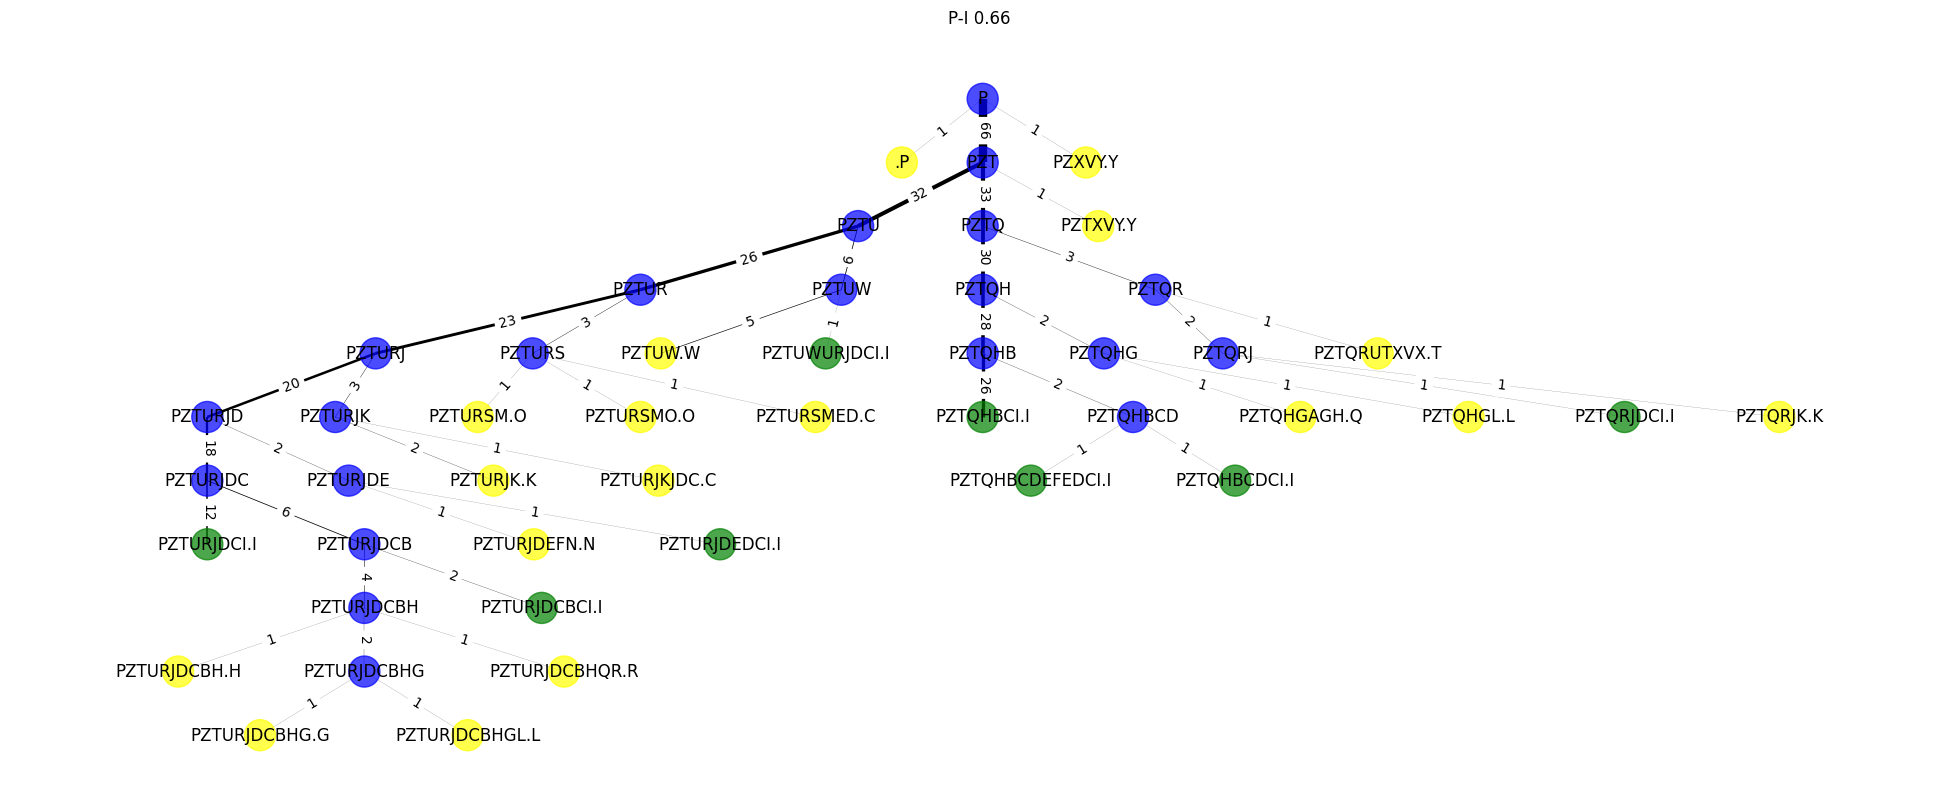

In [4]:
################################
## Three EXAMPLEs             ##
################################
# start_node, end_node = ("N", "Y")
start_node, end_node = ("P", "I")

fig, axes = plt.subplots(1, 1, figsize=(25,10))
this_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]# & test_df["accuracy"]]

print(this_df[["StartAt", "EndAt", "path_mean_acc"]])
acc = this_df["path_mean_acc"].iloc[0]
trajs = generate_trajs_from_df(this_df)
print(len(trajs))
G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

ax = axes

plot_flow_tree(G, f"{start_node}-{end_node} {acc:.2f}", ax, just_edges=False, edge_boldness=1)
plt.show()

22
22
22
22


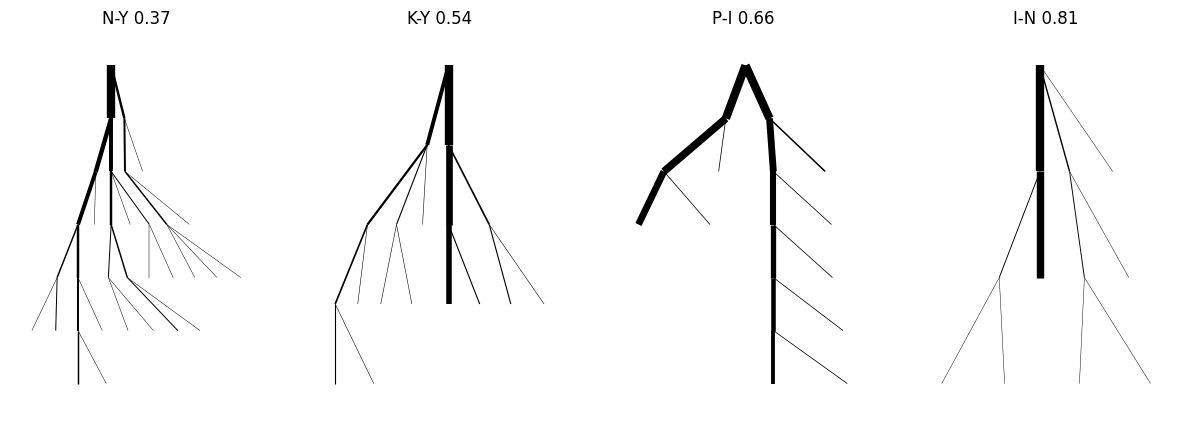

<Figure size 2400x1200 with 0 Axes>

<Figure size 2400x1200 with 0 Axes>

<Figure size 2400x1200 with 0 Axes>

<Figure size 2400x1200 with 0 Axes>

In [5]:
################################
## Three EXAMPLEs             ##
################################
paths_to_plot = [("N", "Y"), ("K", "Y"), ("P", "I"), ("I", "N")]

fig, axes = plt.subplots(1, len(paths_to_plot), figsize=(15,5))
for i, (start_node, end_node) in enumerate(paths_to_plot):
    this_df = test_df[(test_df["StartAt"] == start_node) & (test_df["EndAt"] == end_node)]# & test_df["accuracy"]]

    acc = this_df["path_mean_acc"].iloc[0]
    trajs = random.sample(generate_trajs_from_df(this_df), min(22, len(generate_trajs_from_df(this_df))))
    print(len(trajs))
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    plt.figure(figsize=(24,12))
    ax = axes[i]

    plot_flow_tree(G, f"{start_node}-{end_node} {acc:.2f}", ax, just_edges=True)
plt.show()

In [6]:
## BY PATH
flow_trees = []
paths = []
accs = []
tree_dict = {}
winner_tree_dict = {}
loser_tree_dict = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    flow_trees.append(new_G)
    accs.append(group["path_mean_acc"].iloc[0])
    paths.append((start_node, end_node))
    tree_dict[(start_node, end_node)] = [new_G, group["path_mean_acc"].iloc[0]]

    group["accuracy"] = group["accuracy"].astype(bool)

    # WINNERS ONLY
    trajs = generate_trajs_from_df(group[group["accuracy"]])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    winner_tree_dict[(start_node, end_node)] = G

    # LOSERS ONLY
    trajs = generate_trajs_from_df(group[~group["accuracy"]])
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    loser_tree_dict[(start_node, end_node)] = G



accs = np.array(accs)

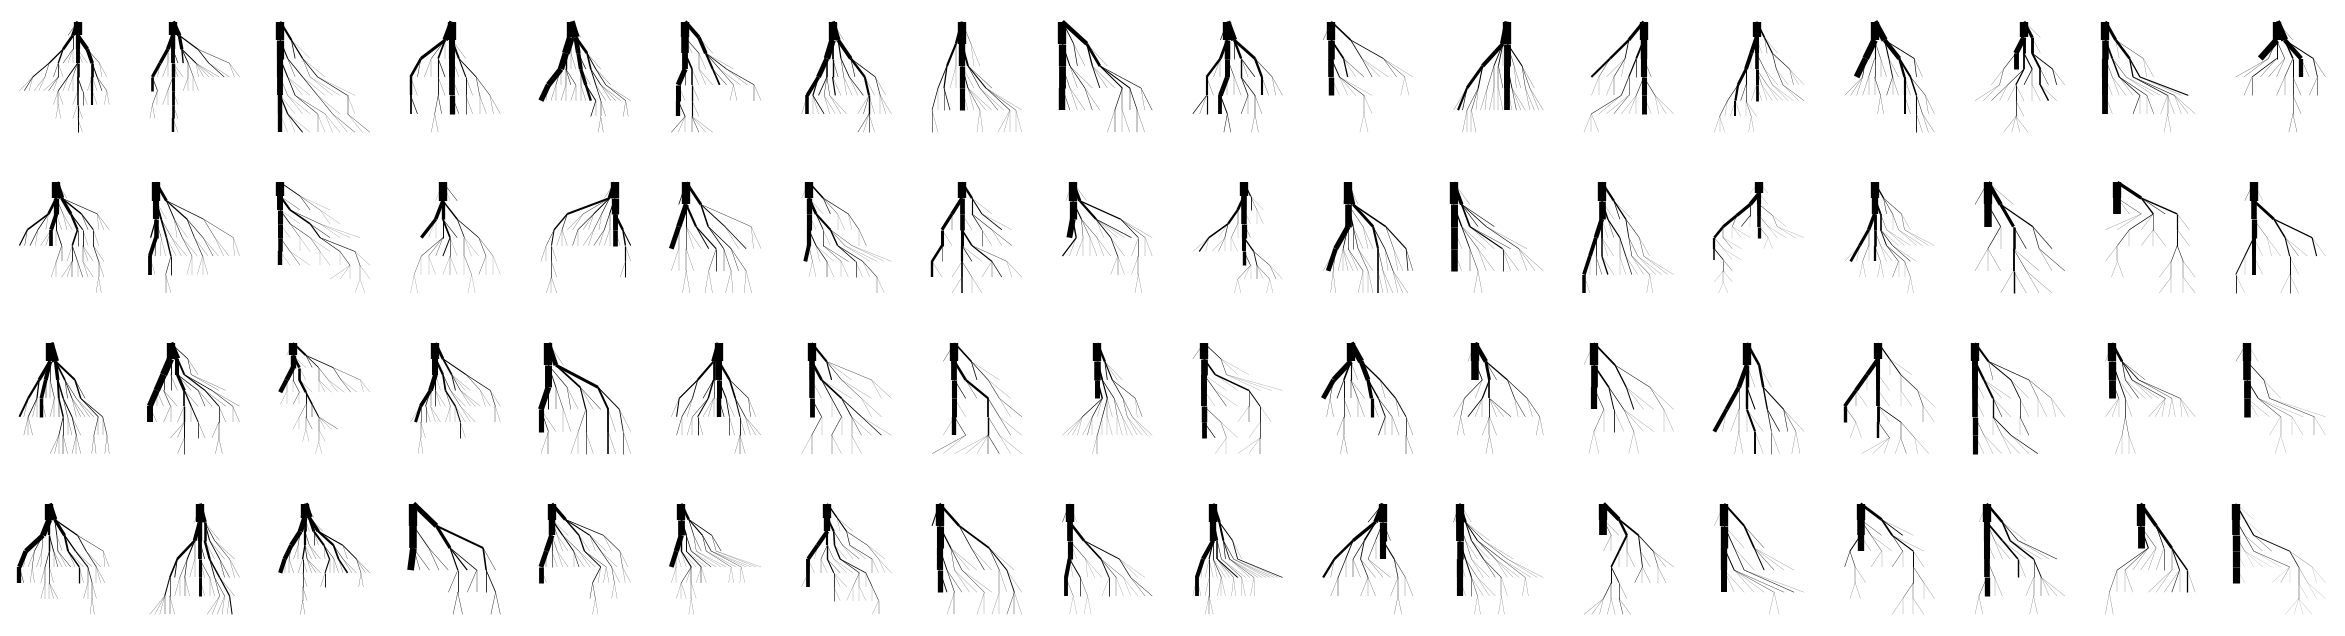

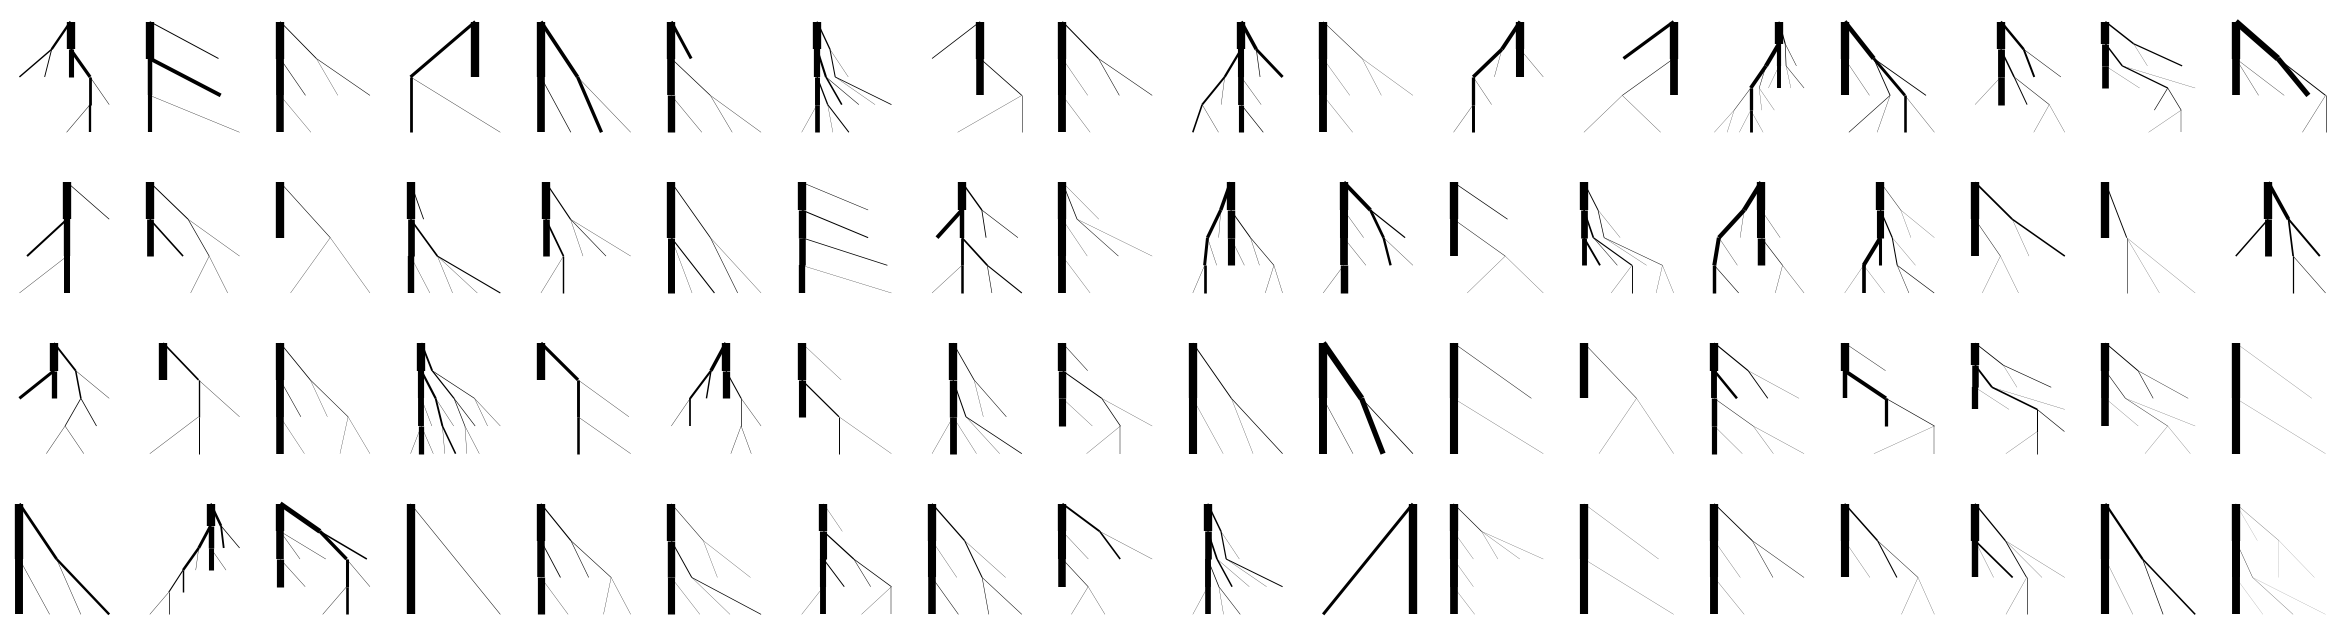

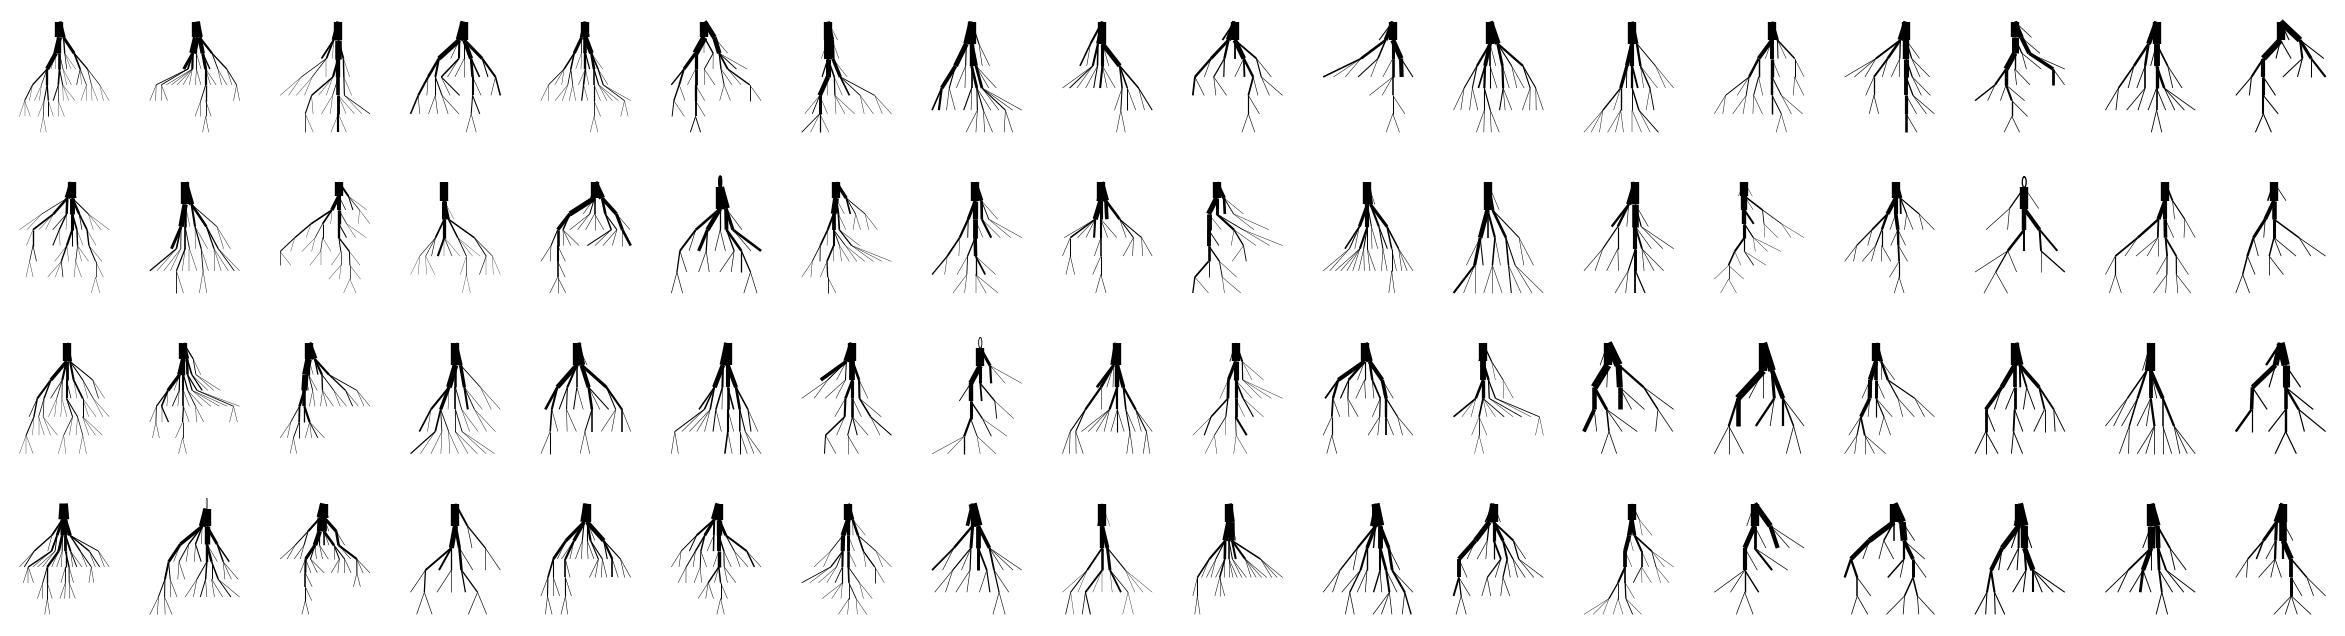

In [7]:
fig, axes = plt.subplots(4, 18, figsize=(30,8))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = flow_trees[tree_index]
    
    # Convert from i to column-major indices
    col = i // 4
    row = i % 4
    ax = axes[row][col]
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, no_title=True, just_edges=True)

# fig.suptitle("Test-path trees sorted by subject-mean path accuracy")
fig.savefig("figures/test_flow_trees_by_acc.png")

plt.show()


fig, axes = plt.subplots(4, 18, figsize=(30,8))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = winner_tree_dict[paths[tree_index]]
    
    # Convert from i to column-major indices
    col = i // 4  
    row = i % 4
    ax = axes[row][col]
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, no_title=True, just_edges=True)

# fig.suptitle("ONLY WINNERS Test-path trees sorted by subject-mean path accuracy")
fig.savefig("figures/test_flow_trees_by_acc-only_winners.png")

plt.show()


fig, axes = plt.subplots(4, 18, figsize=(30,8))

sorted_order = [x for x in sorted(range(len(accs)), key=lambda x: accs[x])]
c=0
for i, tree_index in enumerate(sorted_order):
    G = loser_tree_dict[paths[tree_index]]
    
    # Convert from i to column-major indices
    col = i // 4
    row = i % 4
    ax = axes[row][col]
    plot_flow_tree(G, f"{'-'.join(paths[tree_index])} {accs[tree_index]:.2f}", ax, no_title=True, just_edges=True)

# fig.suptitle("ONLY LOSERS Test-path trees sorted by subject-mean path accuracy")
fig.savefig("figures/test_flow_trees_by_acc-only_losers.png")

plt.show()


# compare to baseline
#   of min path distance!

In [11]:
# df = pd.read_csv("data/MLINDIV_train_full.csv")

# # load test df
# test_df = df[df["eprocs"].str.contains("Test")]

# test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
# test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

# test_df['quartile'] = (
#     pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
# )

# test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")
# test_df["accuracy"] = test_df["accuracy"].astype(bool)

# test_df["trajs"] = test_df["paths"].apply(generate_traj_from_path)
# test_df["traj_strs"] = test_df["trajs"].apply("".join)


# subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
# subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
# subject_df = subject_df[~subject_df["Subject"].isna()]

# subject_df["is_man"] = (subject_df["Sex"] == "M")

# merged_test_df = pd.merge(test_df, subject_df, on="Subject")
# # merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

In [12]:
# df = pd.read_csv("data/MLINDIV_train_full.csv")

# # load test df
# test_df = df[df["eprocs"].str.contains("Test")]

# test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
# test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

# test_df['quartile'] = (
#     pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
# )

# test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")
# test_df["accuracy"] = test_df["accuracy"].astype(bool)

# test_df["trajs"] = test_df["paths"].apply(generate_traj_from_path)
# test_df["traj_strs"] = test_df["trajs"].apply("".join)


# subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
# subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
# subject_df = subject_df[~subject_df["Subject"].isna()]

# subject_df["is_man"] = (subject_df["Sex"] == "M")

# merged_test_df = pd.merge(test_df, subject_df, on="Subject")
# # merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

## 3b. Regression

In [11]:
only_winners = False

static_features = []
flow_trees = []
accuracies = []

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    if only_winners: group = group[~group["accuracy"]]
    acc = group["path_mean_acc"].iloc[0]

    # sample 5 different flow trees
    for i in range(5):
        sample_df1 = group.sample(n=15, random_state=i) 

        trajs1 = np.array(sample_df1["trajs"])
        G1 = generate_flow_tree_from_trajs(trajs1, END_NODE=end_node)
        new_G1 = nx.relabel.convert_node_labels_to_integers(G1, first_label=0, ordering='default') #first_label is the starting integer label, in this case zero

        flow_trees.append(new_G1)
        accuracies.append(acc)

        euclid_distance = sample_df1["Euc.Distance"].mode().iloc[0]
        path_distance = sample_df1["Path.Distance"].mode().iloc[0]
        num_nodes = sample_df1["Num.Nodes"].mode().iloc[0]
        
        avg_path_dist_traveled = sample_df1["path_dist_trav"].mean()
        avg_nodes_count = sample_df1["nodes_count"].mean()
        avg_turns_count = sample_df1["turns_count"].mean()

        static_features.append([euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count])

static_features = np.array(static_features)
accuracies = np.array(accuracies)

In [12]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    # leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]

    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

def extract_tree_features(graph, root):
    # Number of Nodes
    num_nodes = graph.number_of_nodes()
    
    # Tree Depth (Height)
    def tree_depth(graph, root):
        depths = nx.single_source_shortest_path_length(graph, root)
        return max(depths.values())
    
    depth = tree_depth(graph, root)
    
    # Diameter
    diameter = nx.diameter(graph)

    backbone_path, max_weight, weights = get_heaviest_path(graph, root)
    backbone_thickness = np.mean(weights)
    
    # Number of Leaves
    num_leaves = sum(1 for node in graph.nodes() if graph.degree(node) == 1)
    
    # Branching Factor
    branching_factors = [len(list(graph.neighbors(node))) for node in graph.nodes()]
    avg_branching_factor = np.mean(branching_factors)
    
    # Put all features in a list
    features = [
        num_nodes,
        depth,
        diameter,
        num_leaves,
        avg_branching_factor,
        backbone_thickness
    ]
    
    return features

flow_tree_features = np.array([extract_tree_features(flow_tree, 0) for flow_tree in flow_trees])
flow_tree_diameters = np.array([[nx.diameter(G)] for G in flow_trees])

In [13]:
import karateclub as kc
from sklearn.decomposition import PCA

flow_tree_embedder = kc.Graph2Vec(dimensions=64)
flow_tree_embedder.fit(flow_trees)

flow_tree_embeddings = flow_tree_embedder.infer(flow_trees)

pca = PCA(n_components=2)
reduced_features = pca.fit_transform(flow_tree_embeddings)

print(reduced_features)

[[ 1.14699610e-01 -3.24838771e-03]
 [-1.23076767e-01  1.64461415e-03]
 [-1.05581153e-02  4.55148146e-03]
 [-1.03654303e-01  4.01149411e-03]
 [-8.73629972e-02  8.60701688e-03]
 [-2.99571335e-01 -1.42384612e-03]
 [-3.05054903e-01  2.00535913e-04]
 [-1.76981062e-01  4.30892128e-03]
 [ 1.69314459e-01 -2.20670458e-03]
 [-7.71569014e-02  7.41640292e-03]
 [ 2.88887709e-01  1.57428032e-03]
 [ 2.29803294e-01 -3.62263853e-03]
 [ 9.67761204e-02 -1.39853004e-02]
 [-2.16031685e-01 -1.71650443e-02]
 [-5.37383109e-02  1.89784262e-03]
 [-1.26241729e-01  1.76077971e-04]
 [ 5.43791652e-02 -2.16317782e-03]
 [ 1.62472486e-01 -2.72690342e-03]
 [-6.76873252e-02  1.11931039e-03]
 [ 2.61874646e-01  6.67074556e-03]
 [ 4.61395737e-03  9.74383485e-03]
 [ 1.78993076e-01 -8.78704712e-03]
 [-8.19938332e-02  4.30383068e-03]
 [ 9.82046276e-02  1.19975926e-02]
 [-3.89094651e-02 -3.39590292e-03]
 [-3.02696172e-02 -6.28894893e-03]
 [ 1.89142182e-01 -1.86826685e-03]
 [-1.38902113e-01 -1.28393341e-03]
 [ 8.70905817e-03  5

Correlation between backbone thickness and accuracy: 0.423
P-value: 0.000


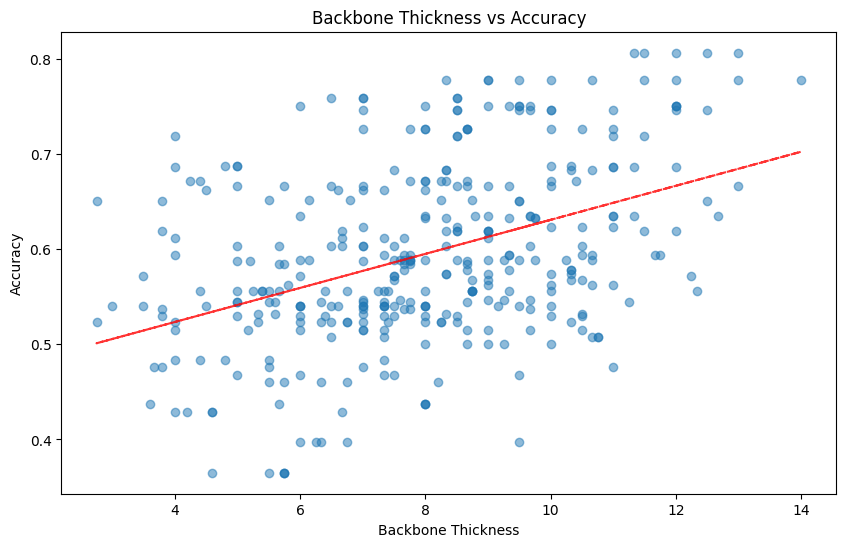

In [16]:
# Extract backbone thickness (last feature)
backbone_thickness = flow_tree_features[:, -1]

# Calculate correlation coefficient and p-value
correlation, p_value = pearsonr(backbone_thickness, accuracies)

print(f"Correlation between backbone thickness and accuracy: {correlation:.3f}")
print(f"P-value: {p_value:.3f}")

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(backbone_thickness, accuracies, alpha=0.5)
plt.xlabel('Backbone Thickness')
plt.ylabel('Accuracy')
plt.title('Backbone Thickness vs Accuracy')

# Add trend line
z = np.polyfit(backbone_thickness, accuracies, 1)
p = np.poly1d(z)
plt.plot(backbone_thickness, p(backbone_thickness), "r--", alpha=0.8)

plt.show()


In [17]:
static_features[:,0]

array([ 6.26498204,  6.26498204,  6.26498204,  6.26498204,  6.26498204,
       10.11187421, 10.11187421, 10.11187421, 10.11187421, 10.11187421,
        6.08276253,  6.08276253,  6.08276253,  6.08276253,  6.08276253,
       15.18222645, 15.18222645, 15.18222645, 15.18222645, 15.18222645,
       11.51086443, 11.51086443, 11.51086443, 11.51086443, 11.51086443,
        8.28402076,  8.28402076,  8.28402076,  8.28402076,  8.28402076,
       16.71264491, 16.71264491, 16.71264491, 16.71264491, 16.71264491,
       14.80920322, 14.80920322, 14.80920322, 14.80920322, 14.80920322,
        6.26498204,  6.26498204,  6.26498204,  6.26498204,  6.26498204,
        4.74341649,  4.74341649,  4.74341649,  4.74341649,  4.74341649,
        5.40832691,  5.40832691,  5.40832691,  5.40832691,  5.40832691,
        9.1241438 ,  9.1241438 ,  9.1241438 ,  9.1241438 ,  9.1241438 ,
        5.31507291,  5.31507291,  5.31507291,  5.31507291,  5.31507291,
        7.07990113,  7.07990113,  7.07990113,  7.07990113,  7.07

In [31]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from plotly.subplots import make_subplots
import plotly.graph_objects as go


def run_evaluate_regression(X, y, feature_str="", axes=["", "", ""]):
    # Initialize and fit the linear regression model
    model = LinearRegression()
    
    ## K-fold cross validation
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Store RMSE for each fold
    rmse_list = []

    slopes = []
    
    # Perform the cross-validation
    for train_index, test_index in kf.split(X):
        # Split data
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Train the model
        model.fit(X_train, y_train)
        
        # Predict on the test set
        y_pred = model.predict(X_test)
        
        # Calculate RMSE
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        
        # Append RMSE to the list
        rmse_list.append(rmse)

        slopes.append(model.coef_)
    
    # Convert RMSE list to a numpy array for statistical calculations
    rmse_array = np.array(rmse_list)
    
    mean_rmse = np.mean(rmse_array)
    std_rmse = np.std(rmse_array)
    
    print(f"Mean RMSE: {mean_rmse}")
    print(f"Standard Deviation of RMSE: {std_rmse}")
    
    # Get the regression coefficient and intercept
    slopes = np.array(slopes)
    slope = np.mean(np.abs(slopes), axis=0)
    intercept = model.intercept_
    
    print(f"Linear Regression Coefficients:", slope)
    print(feature_str)
    print(f"Intercept: {intercept:.2f}")
    print(f"R-squared: {model.score(X, y):.2f}")

    # Correlations
    # Initialize lists to store correlations and p-values
    correlations = []
    p_values = []
    
    # Loop through each feature (column) in X
    for i in range(X.shape[1]):
        corr, p_value = pearsonr(X[:, i], y)
        correlations.append(corr)
        p_values.append(p_value)
    
    # Convert to numpy array for easier manipulation
    correlations = np.array(correlations)
    p_values = np.array(p_values)

    # Identify top 3 most important features based on absolute value of coefficients
    top_features_indices = np.argsort(np.abs(slope))[-3:]  # Indices of the top 3 features
    top_features_names = np.array(feature_str.split(","))[top_features_indices]   # Names of the top 3 features
    
    # Create subplots with 3 plots (one for each top feature)
    fig = make_subplots(rows=1, cols=3)#, subplot_titles=top_features_names)
    
    # Plot each feature against the true y values in separate subplots
    j = 0
    if len(top_features_indices) > 1:
    # else: 
    #     top_features_indices = [top_features_indices[0], top_features_indices[2], top_features_indices[1]]
        for i in reversed(top_features_indices):
            feature_name = np.array(feature_str.split(","))[i]

            # Scatter plot: feature vs actual y
            fig.add_trace(go.Scatter(x=X[:,i], y=y, mode='markers', name=f'corr={correlations[i]:0.3f}, p={p_values[i]:0.3f}'),
                        row=1, col=j+1)

            feature_model = LinearRegression()
            feature_X = X[:,i:i+1] 
            feature_model.fit(feature_X, y)
            
            # Plot regression line: feature vs predicted y (y_pred)
            # Create values for the best-fit line
            feature_x_range = np.linspace(X[:,i].min(), X[:,i].max(), 100)
            feature_y_pred = feature_model.predict(feature_x_range.reshape(-1, 1))

            fig.add_trace(go.Scatter(x=feature_x_range, y=feature_y_pred, mode='lines', name=f'{slope[i]:0.2f} {feature_name} regression line'),
                        row=1, col=j+1)
            # Update subplot appearance
            fig.update_xaxes(title_text=axes[j]+f"{feature_name}<br>(r={correlations[i]:0.4f}, p={p_values[i]:0.7f})", 
                            title_standoff=3, row=1, col=j+1,
                            showgrid=False, gridcolor='white')
            fig.update_yaxes(showgrid=False, gridcolor='white',
                            row=1, col=j+1)
            fig.update_layout(plot_bgcolor='white',
                            paper_bgcolor='white')

            j+=1
    else:
        for _ in range(3):
            feature_name = ""
            i=0

            # Scatter plot: feature vs actual y
            fig.add_trace(go.Scatter(x=X[:,i], y=y, mode='markers', name=f'corr={correlations[i]:0.3f}, p={p_values[i]:0.3f}'),
                        row=1, col=j+1)

            feature_model = LinearRegression()
            feature_X = X[:,i:i+1] 
            feature_model.fit(feature_X, y)
            
            # Plot regression line: feature vs predicted y (y_pred)
            # Create values for the best-fit line
            feature_x_range = np.linspace(X[:,i].min(), X[:,i].max(), 100)
            feature_y_pred = feature_model.predict(feature_x_range.reshape(-1, 1))

            fig.add_trace(go.Scatter(x=feature_x_range, y=feature_y_pred, mode='lines', name=f'{slope[i]:0.2f} {feature_name} regression line'),
                        row=1, col=j+1)
            # Update subplot appearance
            fig.update_xaxes(title_text=axes[j]+f"{feature_name}<br>(r={correlations[i]:0.4f}, p={p_values[i]:0.7f})", 
                            title_standoff=3, row=1, col=j+1,
                            showgrid=False, gridcolor='white')
            fig.update_yaxes(showgrid=False, gridcolor='white',
                            row=1, col=j+1)
            fig.update_layout(plot_bgcolor='white',
                            paper_bgcolor='white')
    
    # Update layout to make the plot visually appealing
    fig.update_layout(title_text="Top 3 Features vs Target Variable", height=400, width=1200)
    fig.update_yaxes(title_text="path success rate", title_standoff=3, row=1, col=1)
    
    # Show plot
    fig.show()

In [32]:
# STATIC EVALUATION

print("Euclid")
run_evaluate_regression(static_features[:,0].reshape(-1, 1), accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""])

print("avg_nodes_count")
run_evaluate_regression(static_features[:,-2].reshape(-1, 1), accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""])

print("avg_turns_count")
run_evaluate_regression(static_features[:,-1].reshape(-1, 1), accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""])

print("all static")
run_evaluate_regression(static_features, accuracies, feature_str="euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count", axes=["", "", ""])

Euclid
Mean RMSE: 0.09416002445709815
Standard Deviation of RMSE: 0.005882850096738006
Linear Regression Coefficients: [0.00281999]
euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count
Intercept: 0.63
R-squared: 0.01


avg_nodes_count
Mean RMSE: 0.08884277187710574
Standard Deviation of RMSE: 0.006064675840508064
Linear Regression Coefficients: [0.02702059]
euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count
Intercept: 0.82
R-squared: 0.12


avg_turns_count
Mean RMSE: 0.09066877423519377
Standard Deviation of RMSE: 0.007469290005763159
Linear Regression Coefficients: [0.02213383]
euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count
Intercept: 0.73
R-squared: 0.08


all static
Mean RMSE: 0.08679285708316396
Standard Deviation of RMSE: 0.00794171612673435
Linear Regression Coefficients: [0.00288953 0.00650386 0.00999921 0.02143463 0.07932735 0.01404619]
euclid_distance, path_distance, num_nodes, avg_path_dist_traveled, avg_nodes_count, avg_turns_count
Intercept: 0.84
R-squared: 0.19


In [33]:

# Flow Tree
print("num_nodes")
run_evaluate_regression(flow_tree_features[:,0].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("depth")
run_evaluate_regression(flow_tree_features[:,1].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("avg_branching_factor")
run_evaluate_regression(flow_tree_features[:,-2].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("backbone_thickness")
run_evaluate_regression(flow_tree_features[:,-1].reshape(-1, 1), accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])

print("all flow tree")
run_evaluate_regression(flow_tree_features, accuracies, feature_str="num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness", axes=["", "", ""])


print("embeddings")
# run_evaluate_regression(flow_tree_diameters, accuracies, feature_str="diameter", axes=["", "", ""])
run_evaluate_regression(reduced_features, accuracies, feature_str="pca1,pca2", axes=["", "", ""])


num_nodes
Mean RMSE: 0.07837758568134248
Standard Deviation of RMSE: 0.004567716318137339
Linear Regression Coefficients: [0.01292355]
num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness
Intercept: 0.80
R-squared: 0.31


depth
Mean RMSE: 0.08771829996847454
Standard Deviation of RMSE: 0.005608895952658092
Linear Regression Coefficients: [0.04007035]
num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness
Intercept: 0.75
R-squared: 0.14


avg_branching_factor
Mean RMSE: 0.08237755638982809
Standard Deviation of RMSE: 0.006105640437931387
Linear Regression Coefficients: [0.85939238]
num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness
Intercept: 2.13
R-squared: 0.26


backbone_thickness
Mean RMSE: 0.08531863420985723
Standard Deviation of RMSE: 0.00860855356321981
Linear Regression Coefficients: [0.01787567]
num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness
Intercept: 0.46
R-squared: 0.18


all flow tree
Mean RMSE: 0.07901748292855063
Standard Deviation of RMSE: 0.0039011954638168253
Linear Regression Coefficients: [0.00238926 0.0052336  0.00275396 0.01773436 0.19714832 0.00207865]
num_nodes, depth, diameter, num_leaves,avg_branching_factor,backbone_thickness
Intercept: 1.03
R-squared: 0.32


embeddings
Mean RMSE: 0.08849133757391091
Standard Deviation of RMSE: 0.006657580887283571
Linear Regression Coefficients: [0.17879221 1.3876022 ]
pca1,pca2
Intercept: 0.59
R-squared: 0.13


In [20]:
# df = pd.read_csv("data/MLINDIV_train_full.csv")

# # load test df
# test_df = df[df["eprocs"].str.contains("Test")]

# test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
# test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

# test_df['quartile'] = (
#     pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
# )

# test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")
# test_df["accuracy"] = test_df["accuracy"].astype(bool)

# test_df["trajs"] = test_df["paths"].apply(generate_traj_from_path)
# test_df["traj_strs"] = test_df["trajs"].apply("".join)


# subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
# subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
# subject_df = subject_df[~subject_df["Subject"].isna()]

# subject_df["is_man"] = (subject_df["Sex"] == "M")

# merged_test_df = pd.merge(test_df, subject_df, on="Subject")
# # merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

### Compare winners to losers

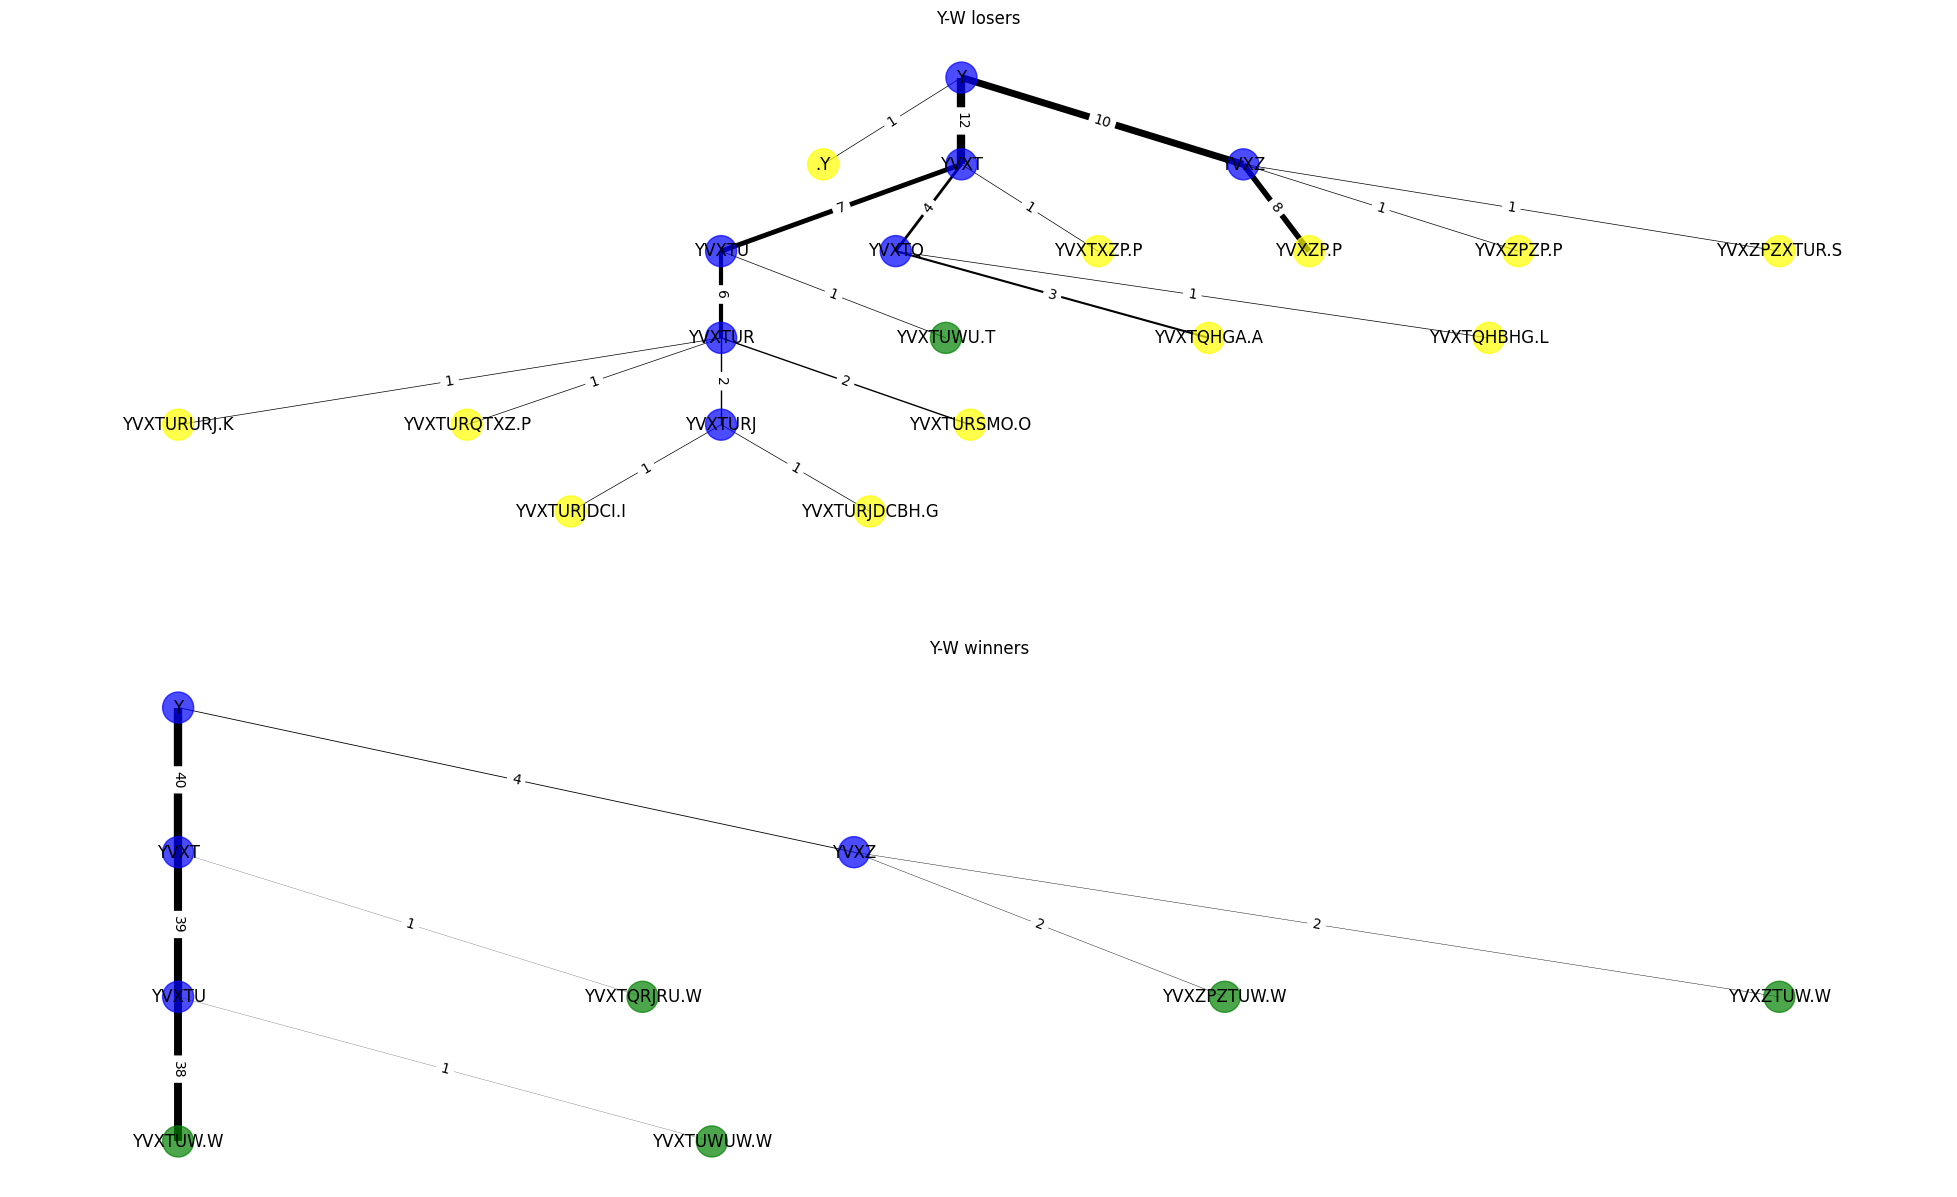

In [21]:
fig, axes = plt.subplots(2, 1, figsize=(25,15))

nodea, nodeb = "Y", "W"

G = loser_tree_dict[(nodea, nodeb)]
plot_flow_tree(G, f"{nodea}-{nodeb} losers", axes[0])

G = winner_tree_dict[(nodea, nodeb)]
plot_flow_tree(G, f"{nodea}-{nodeb} winners", axes[1])

plt.show()

#### Plot by pairs

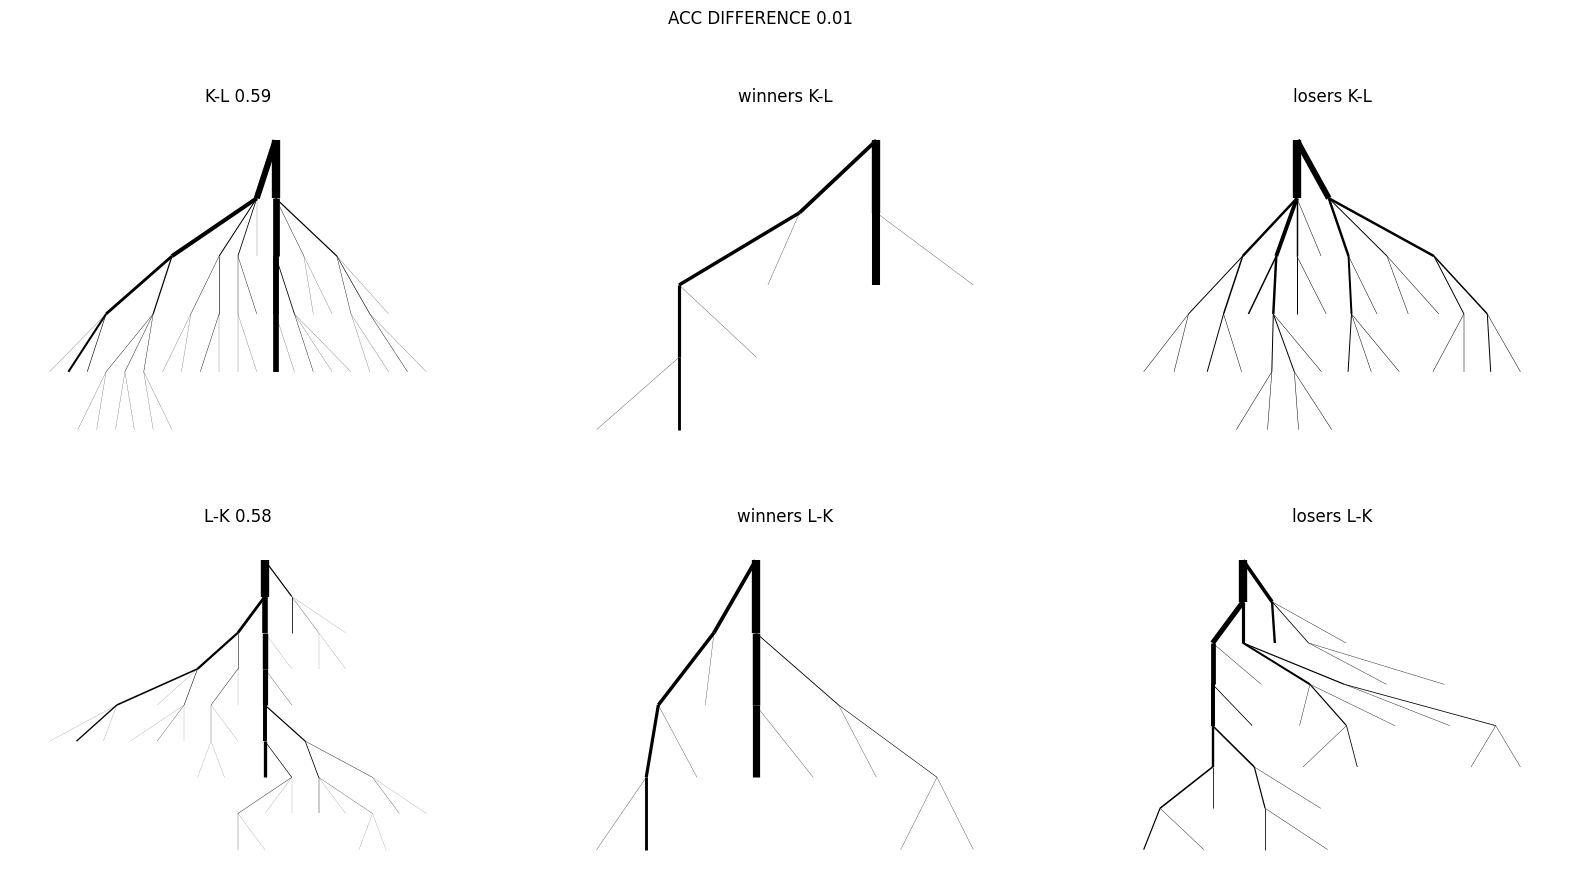

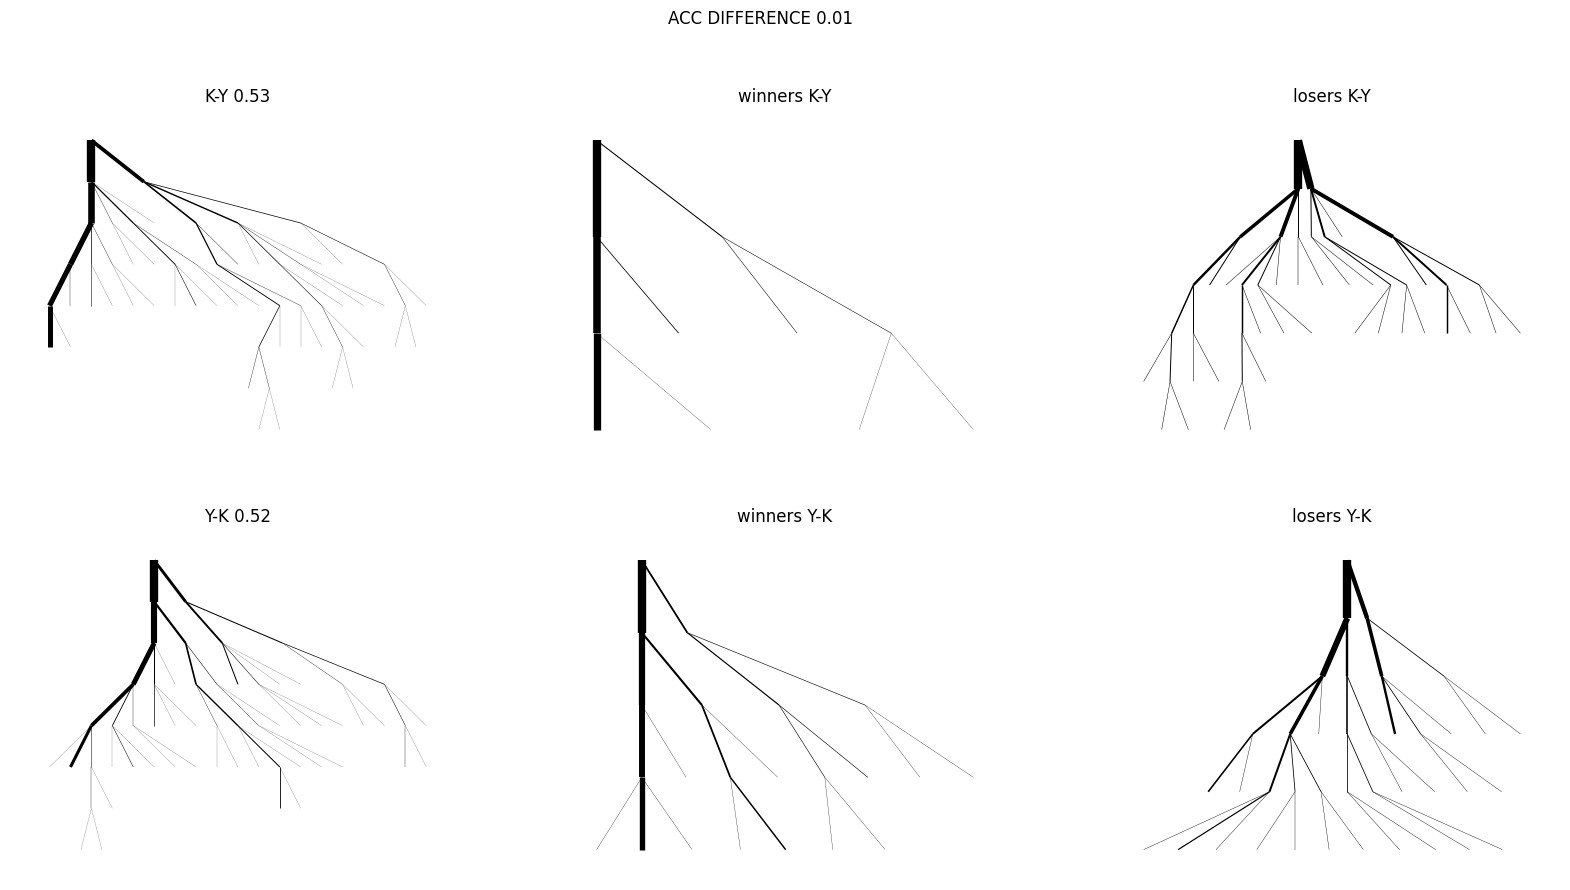

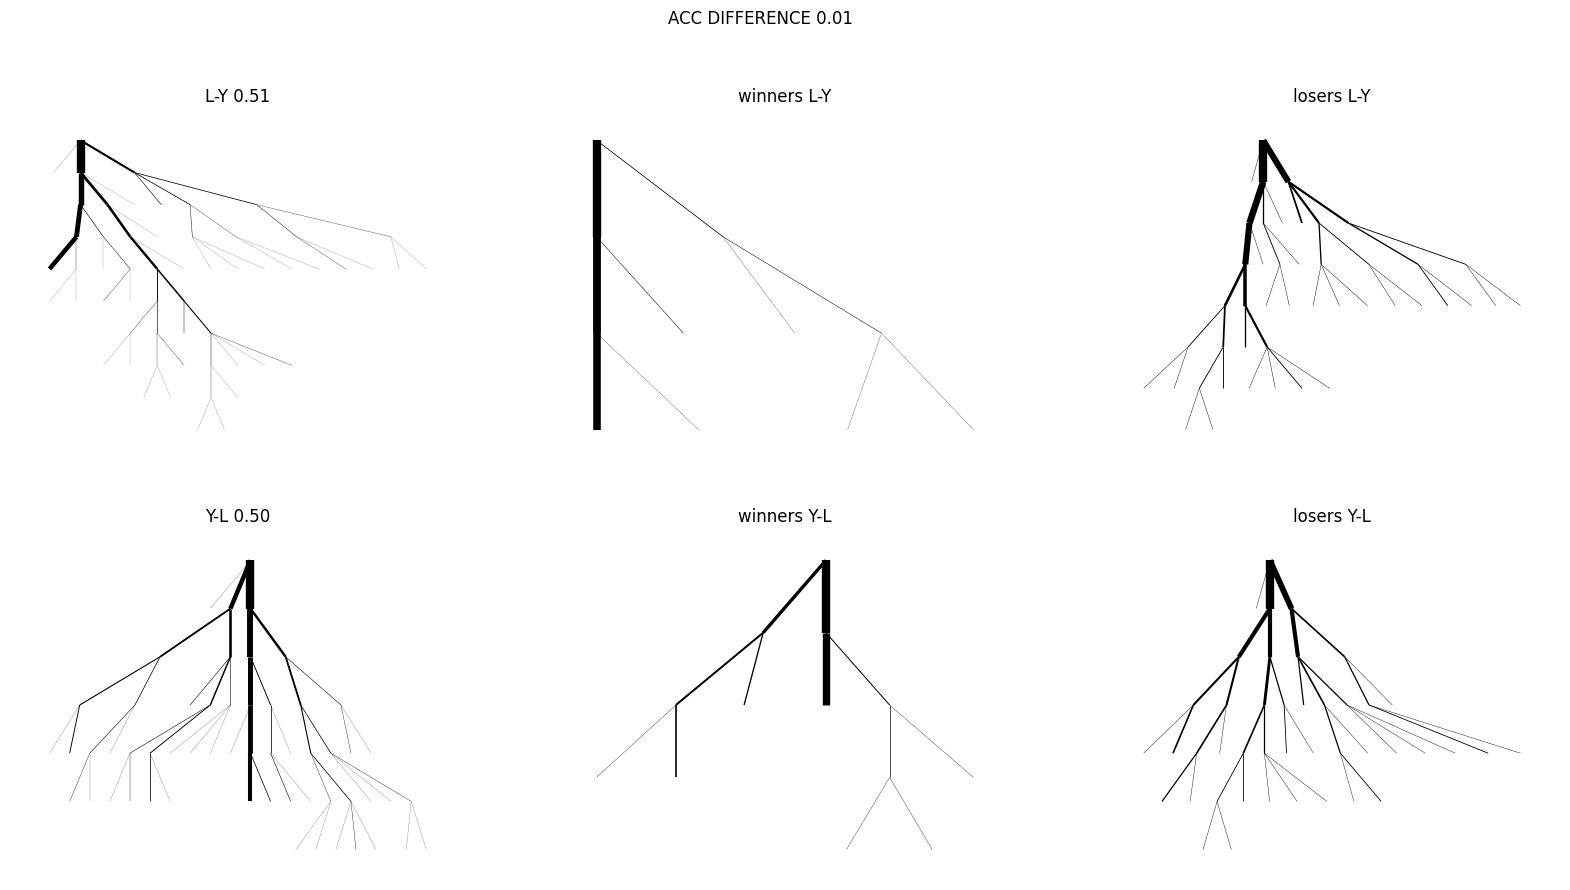

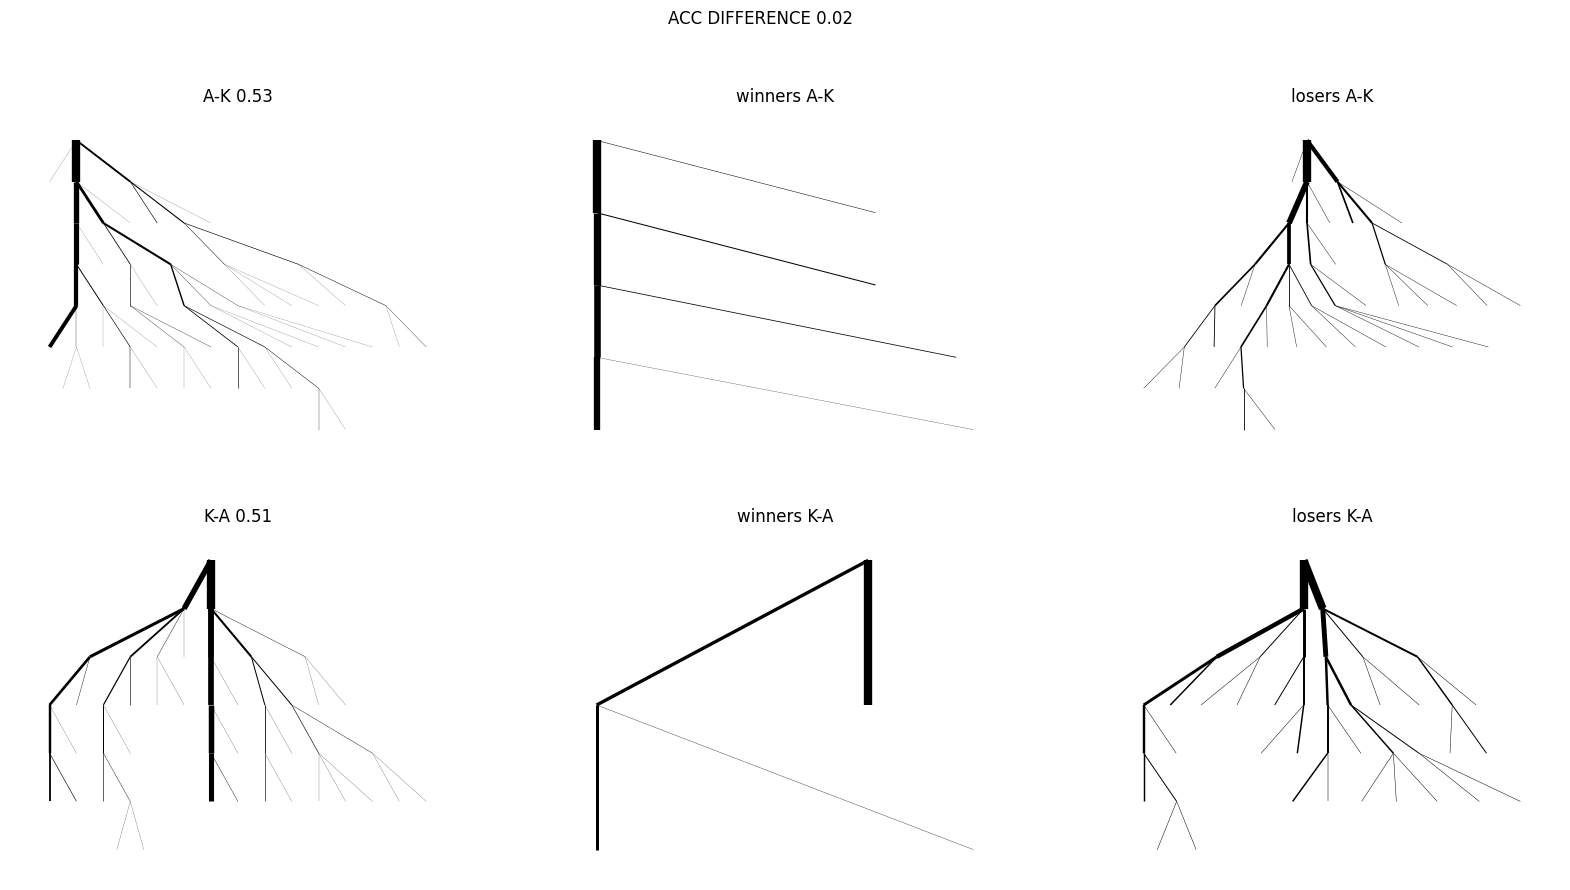

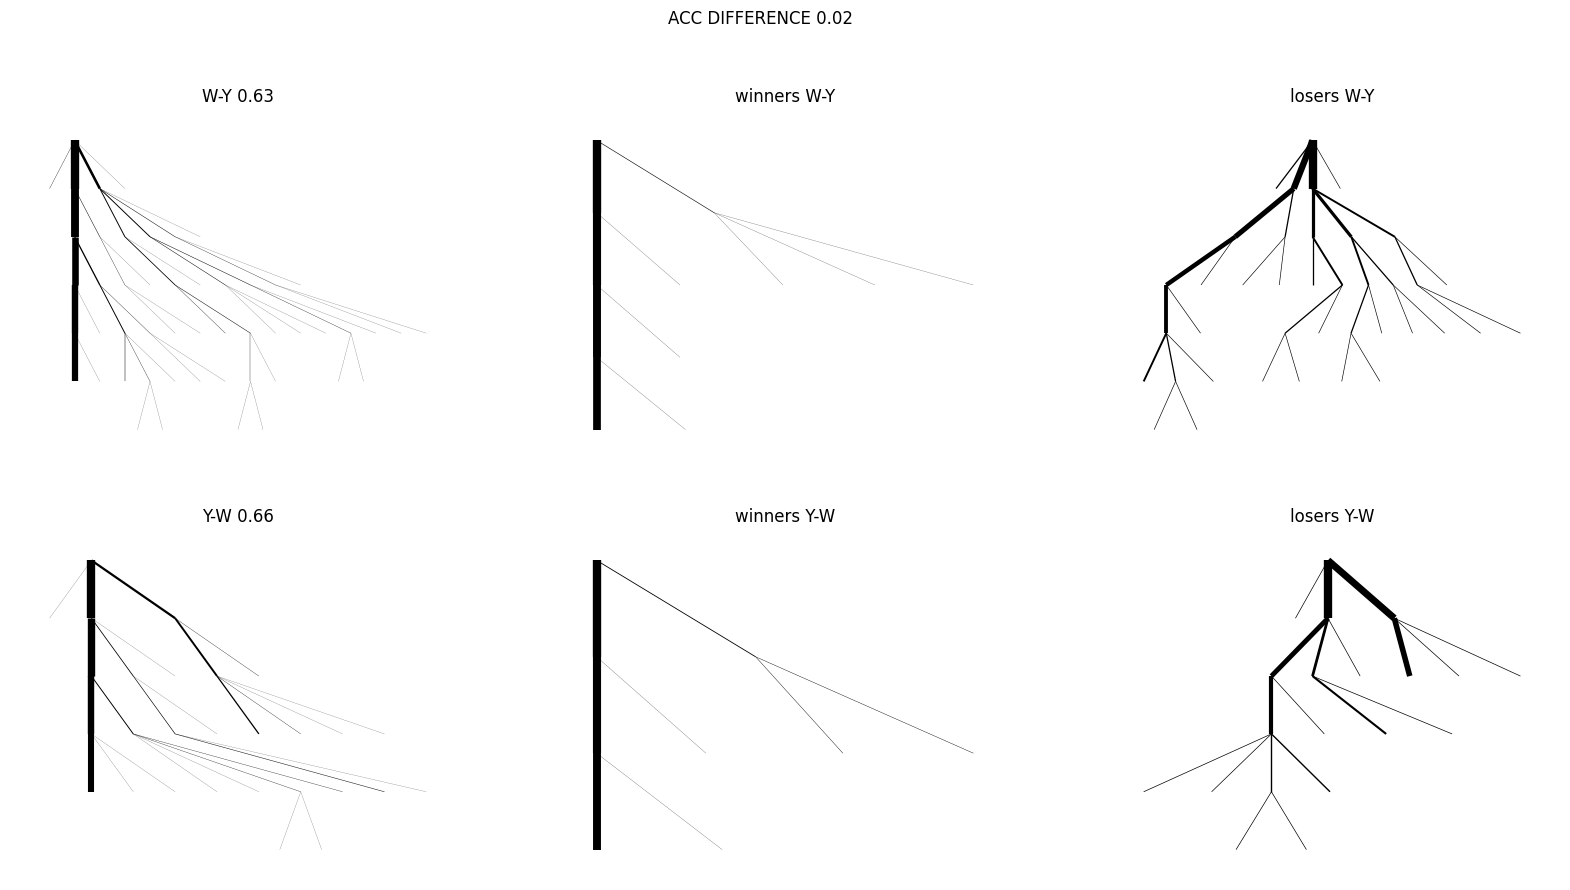

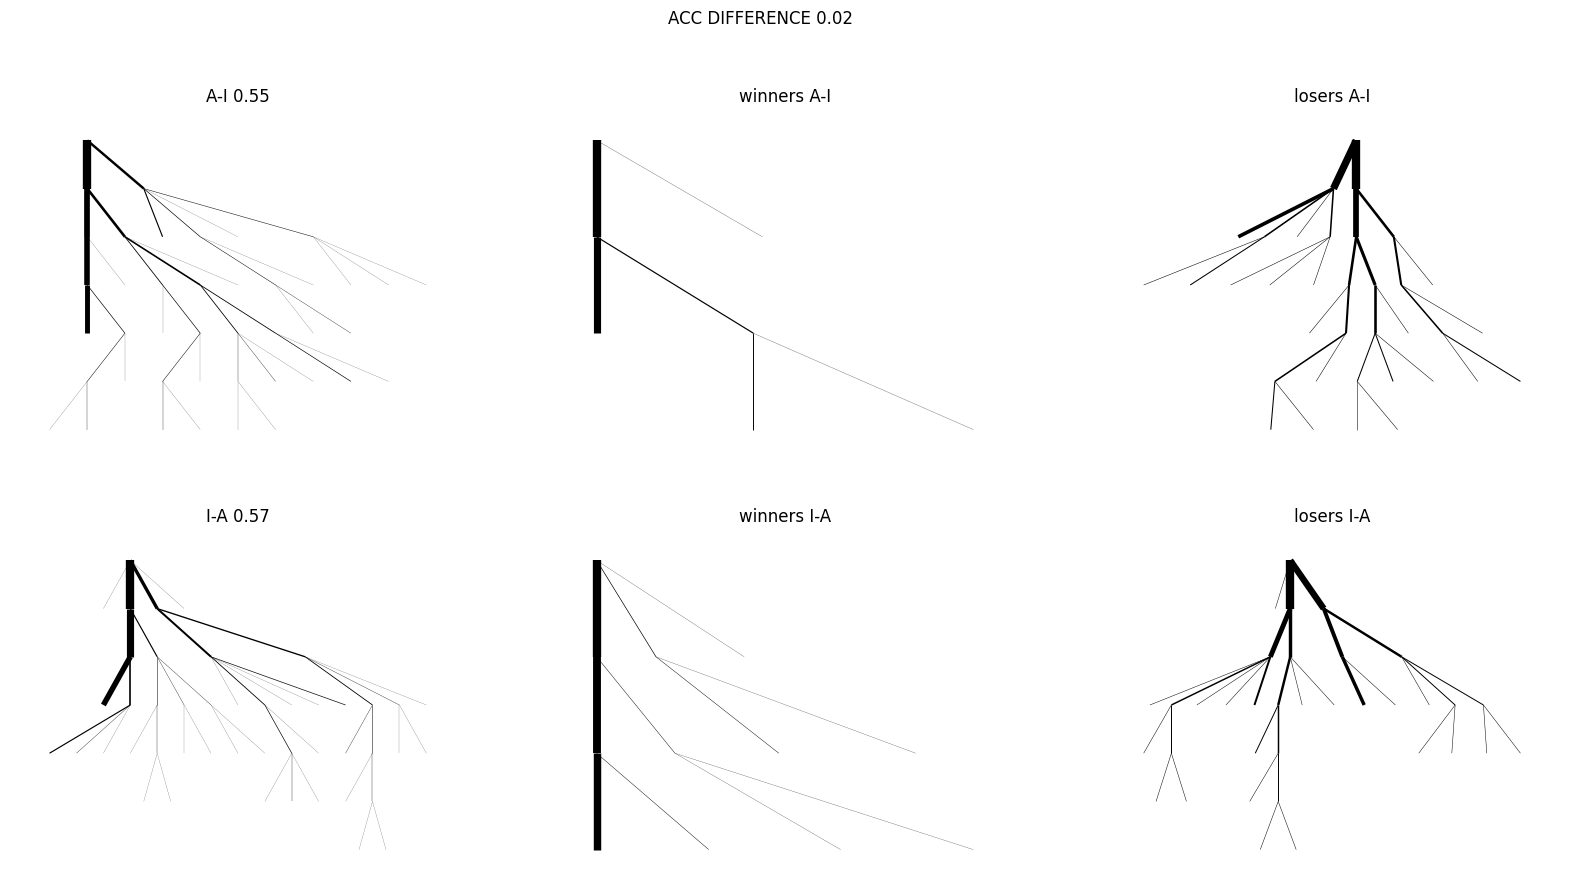

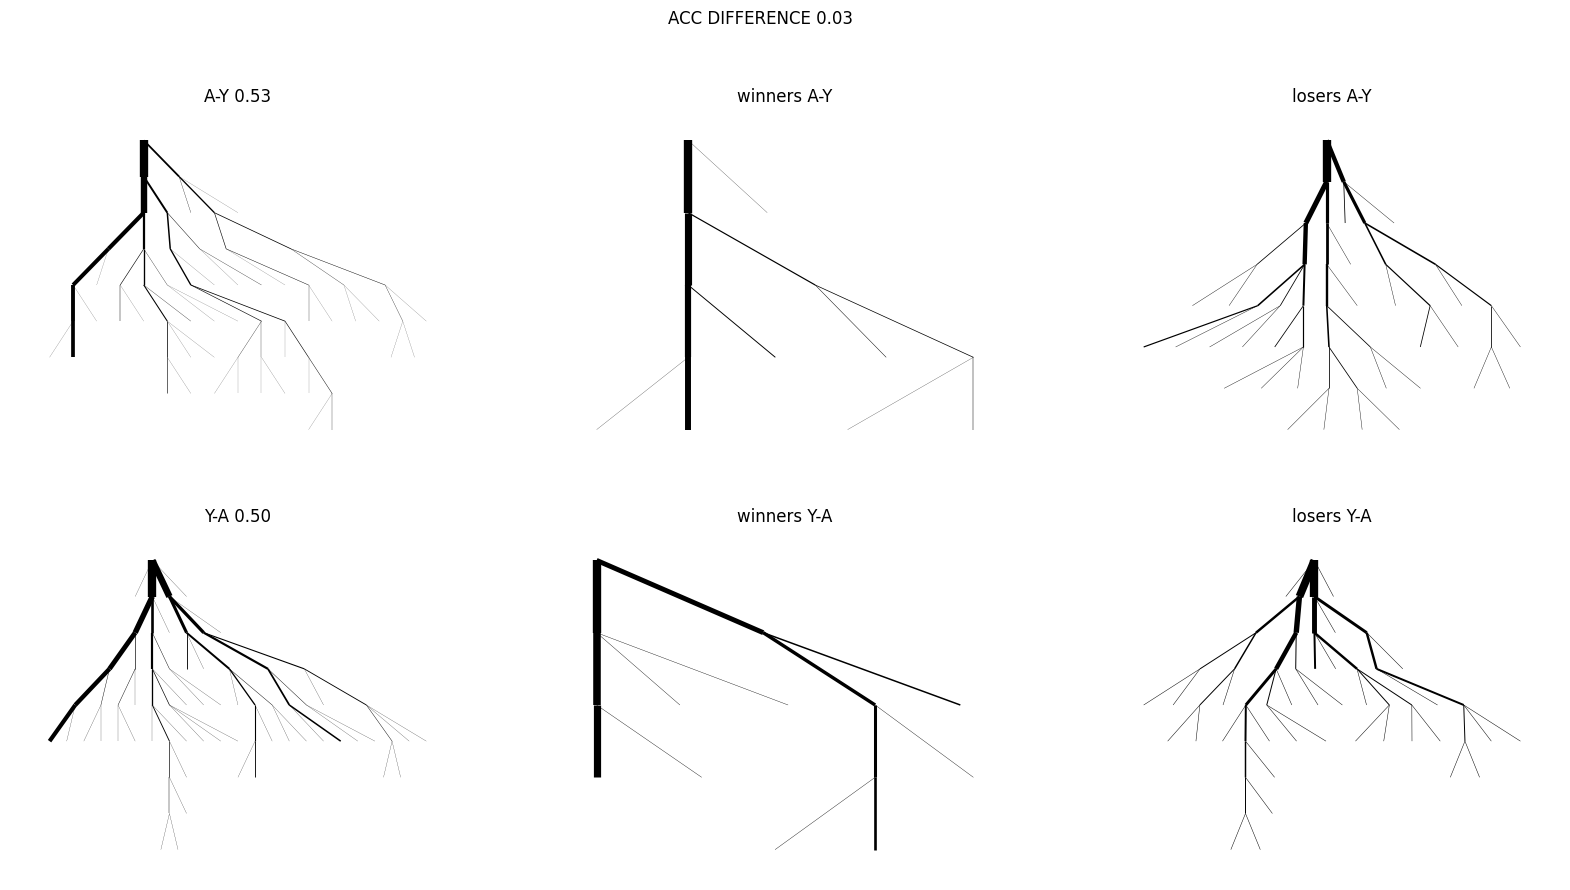

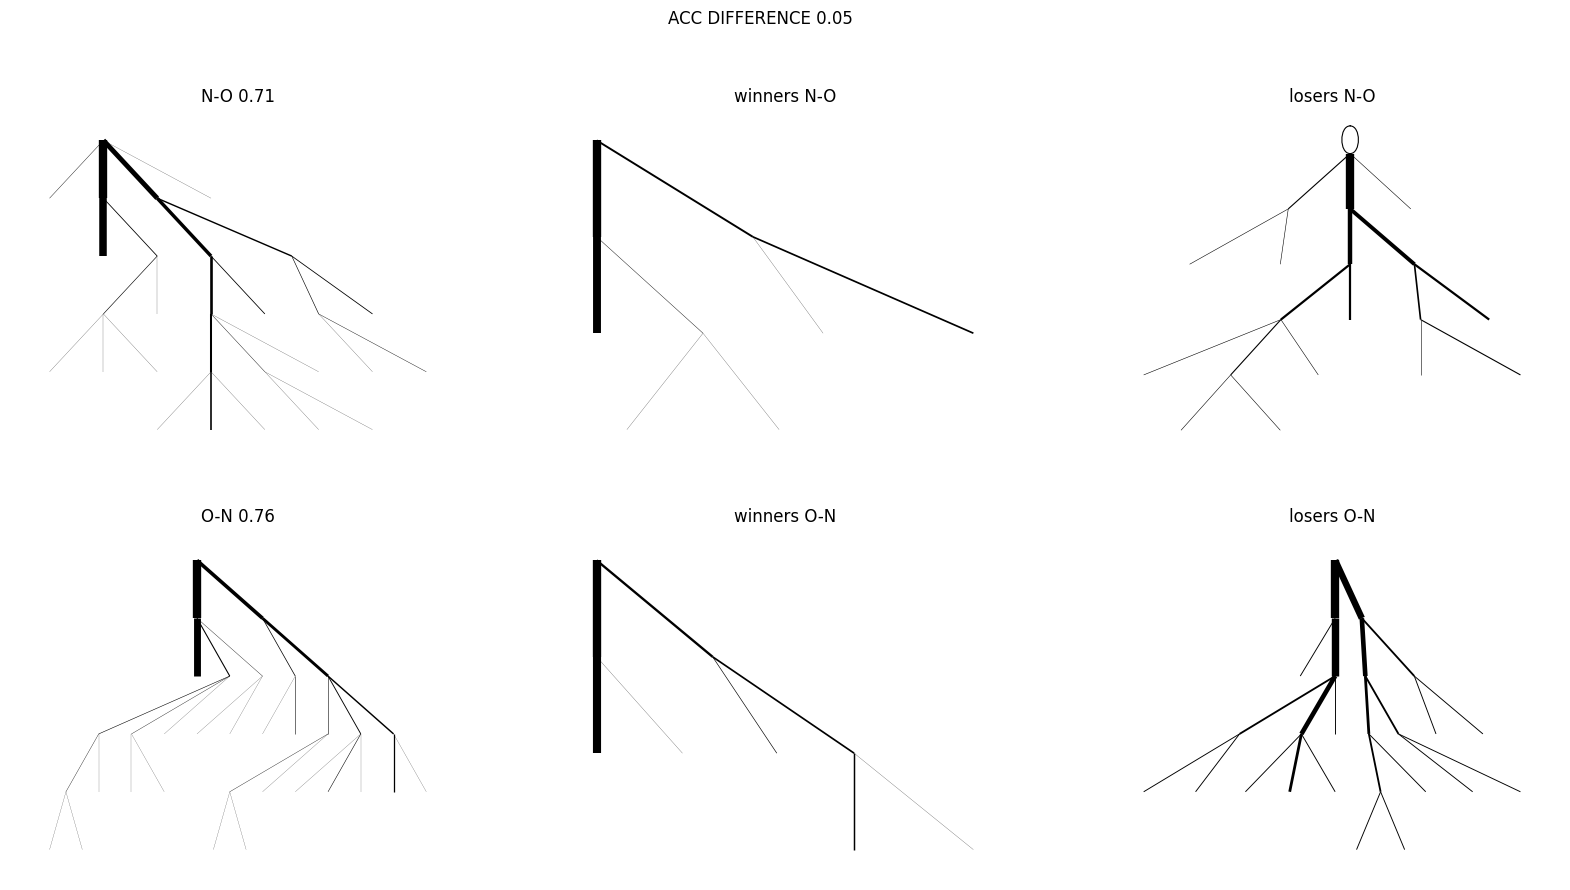

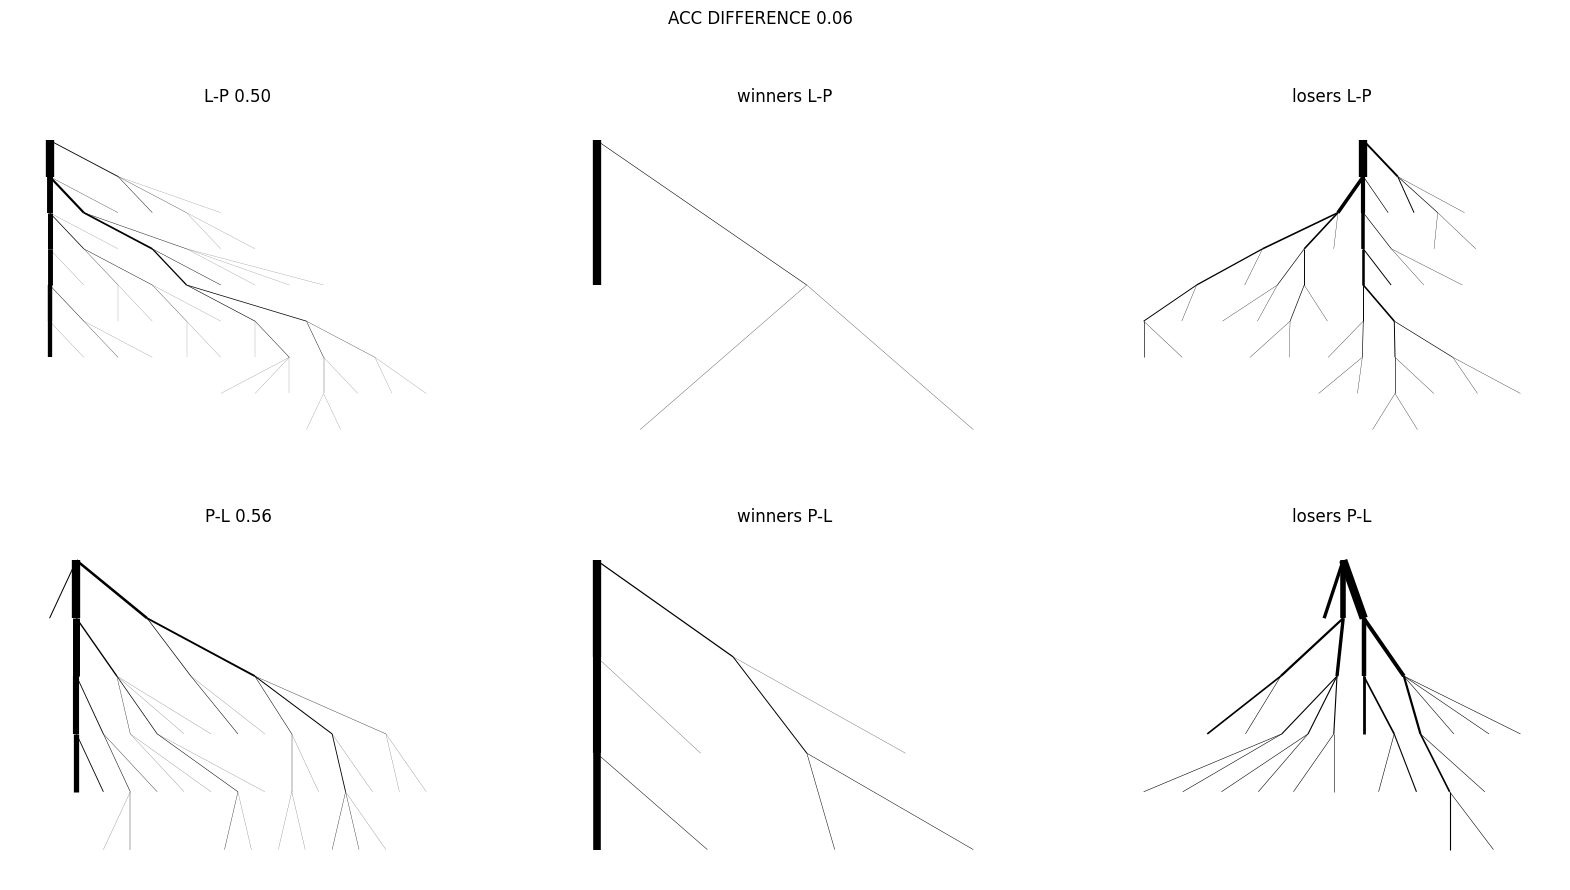

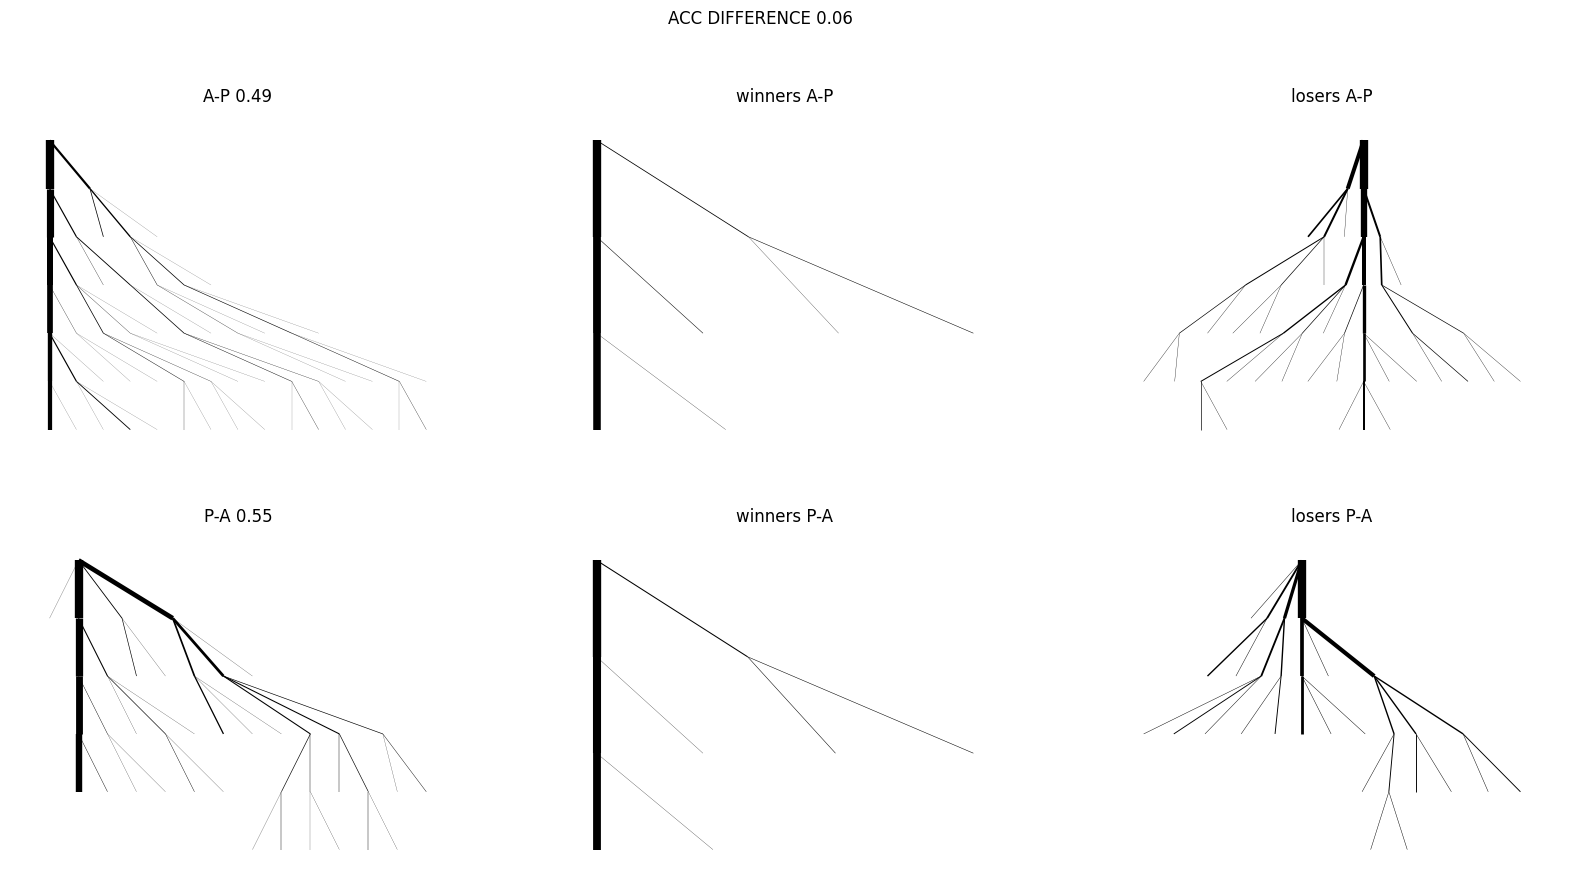

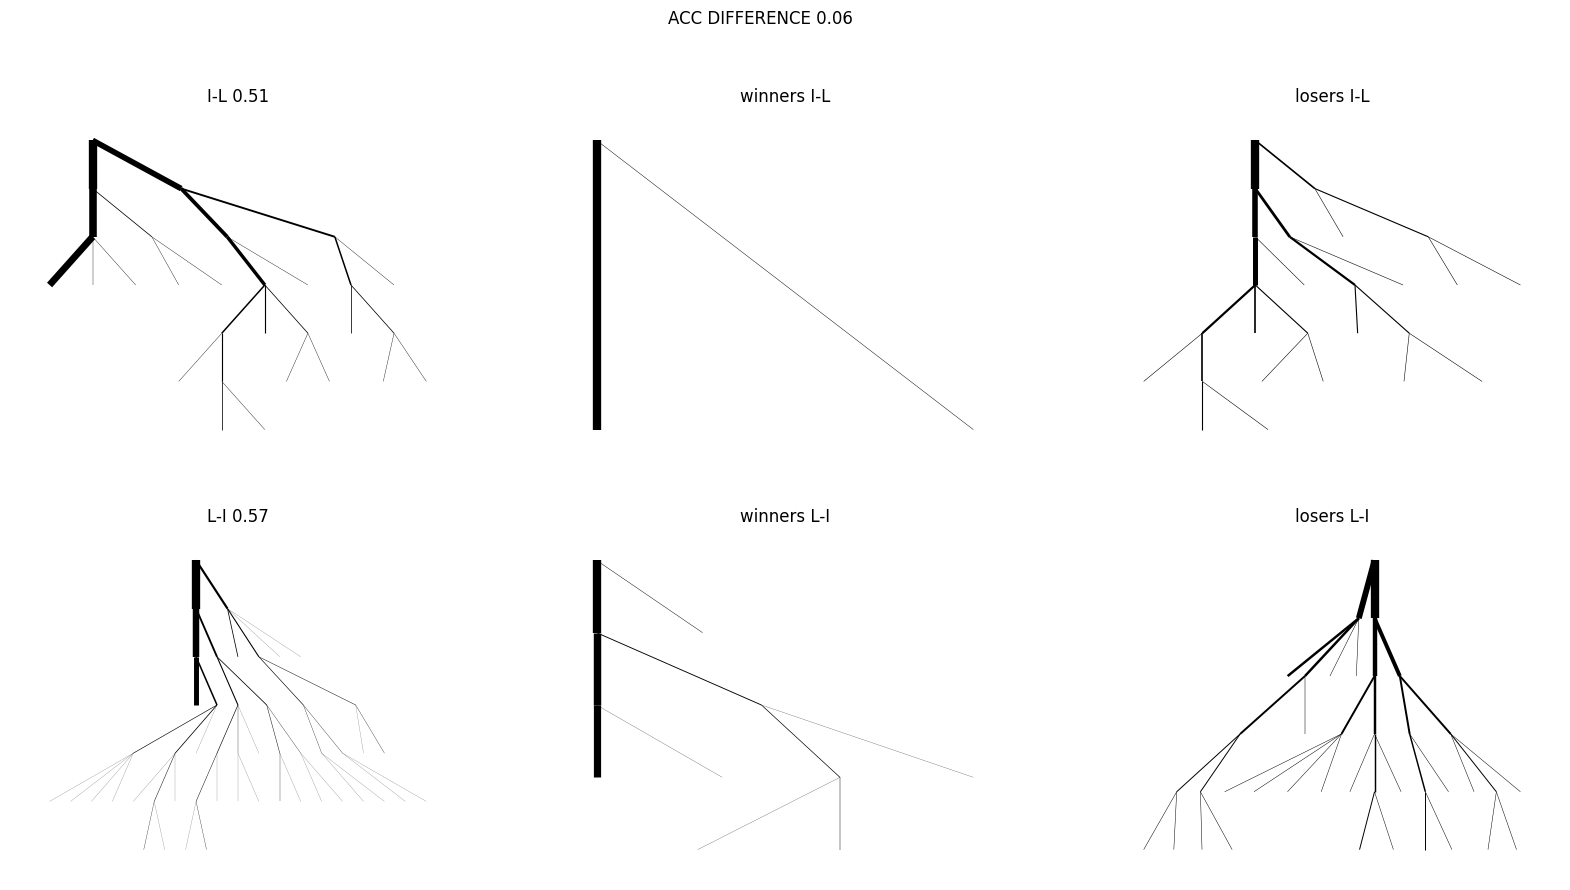

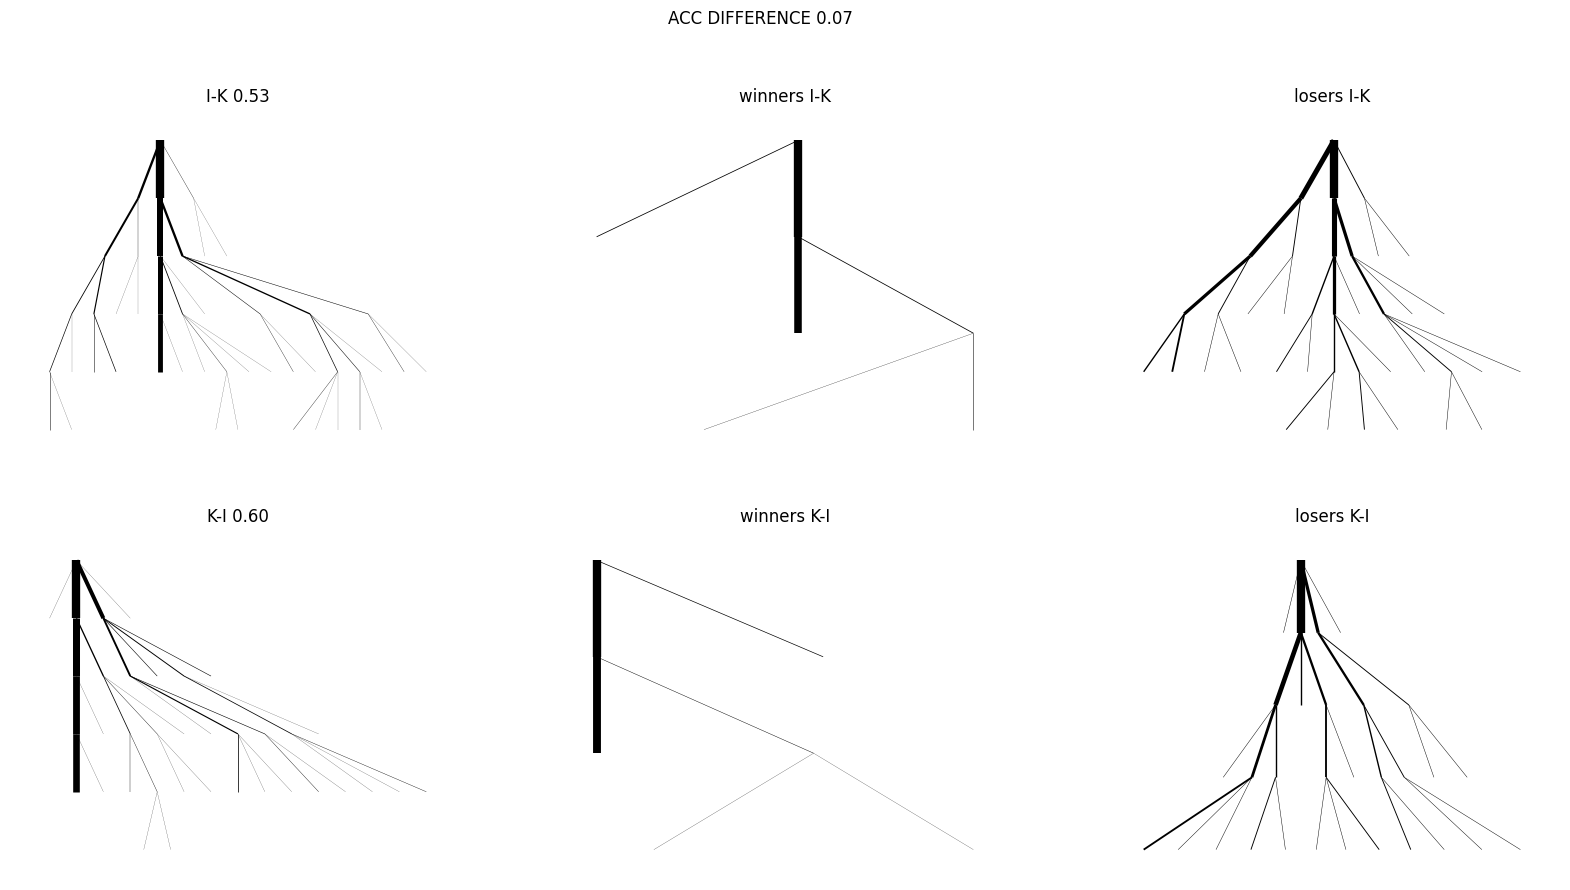

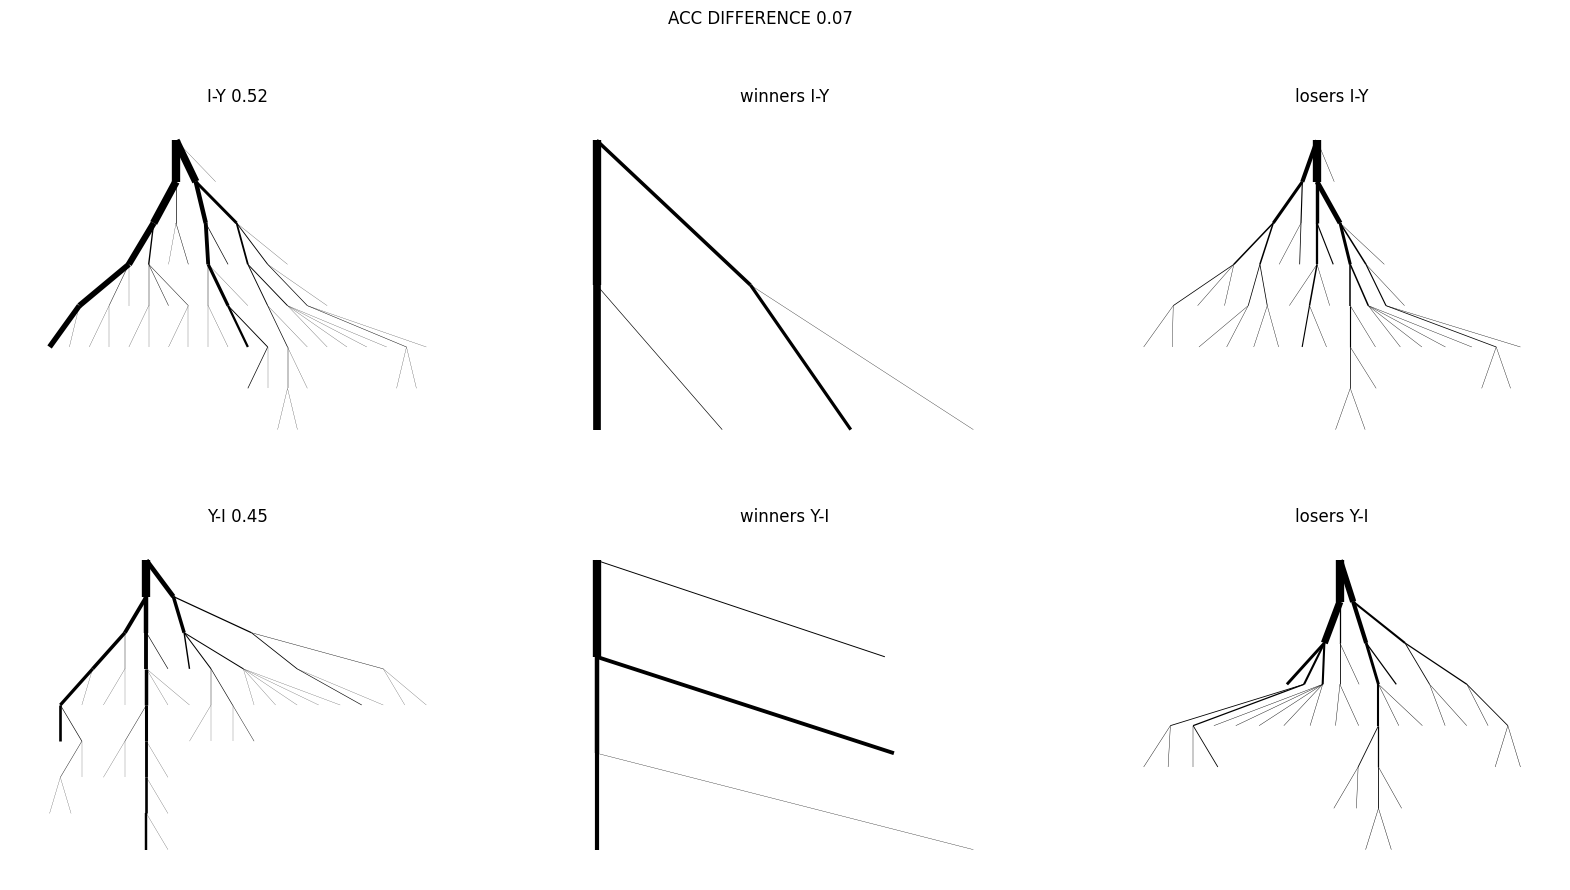

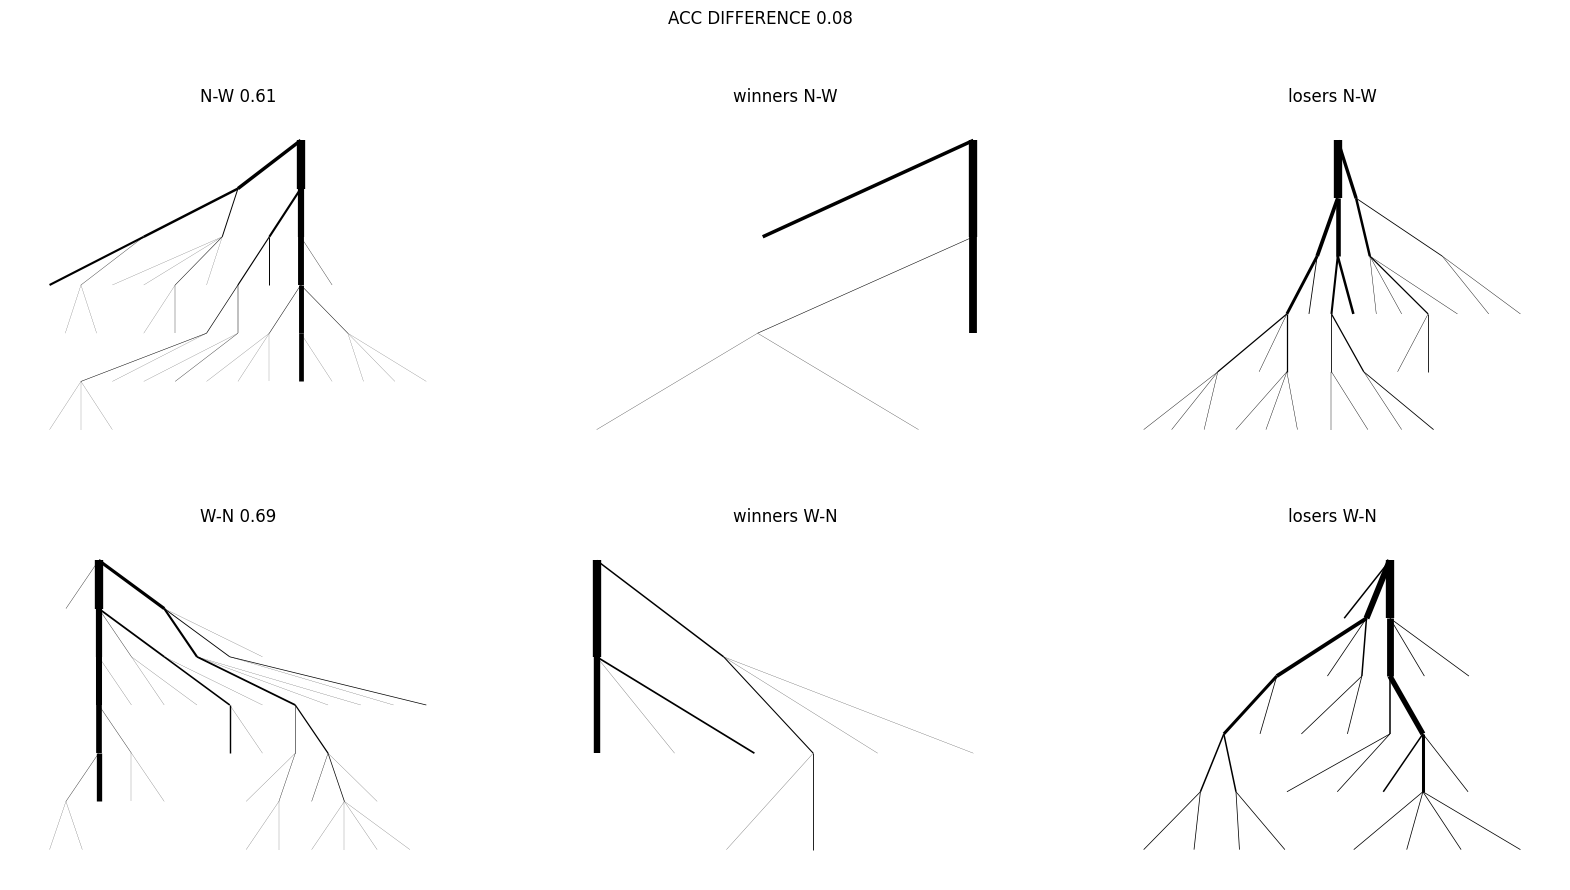

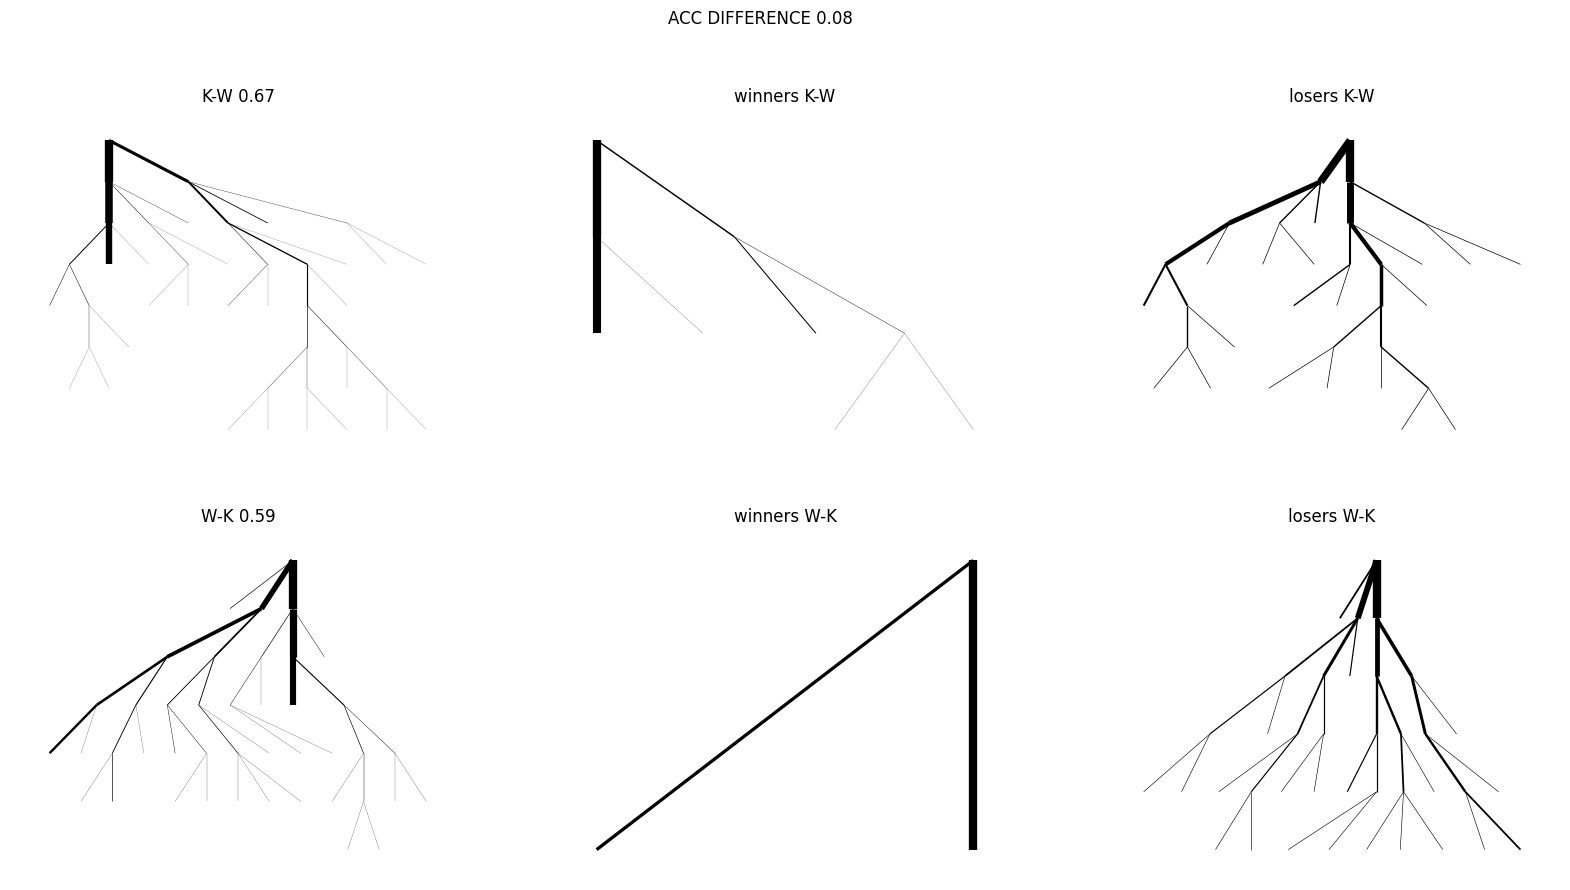

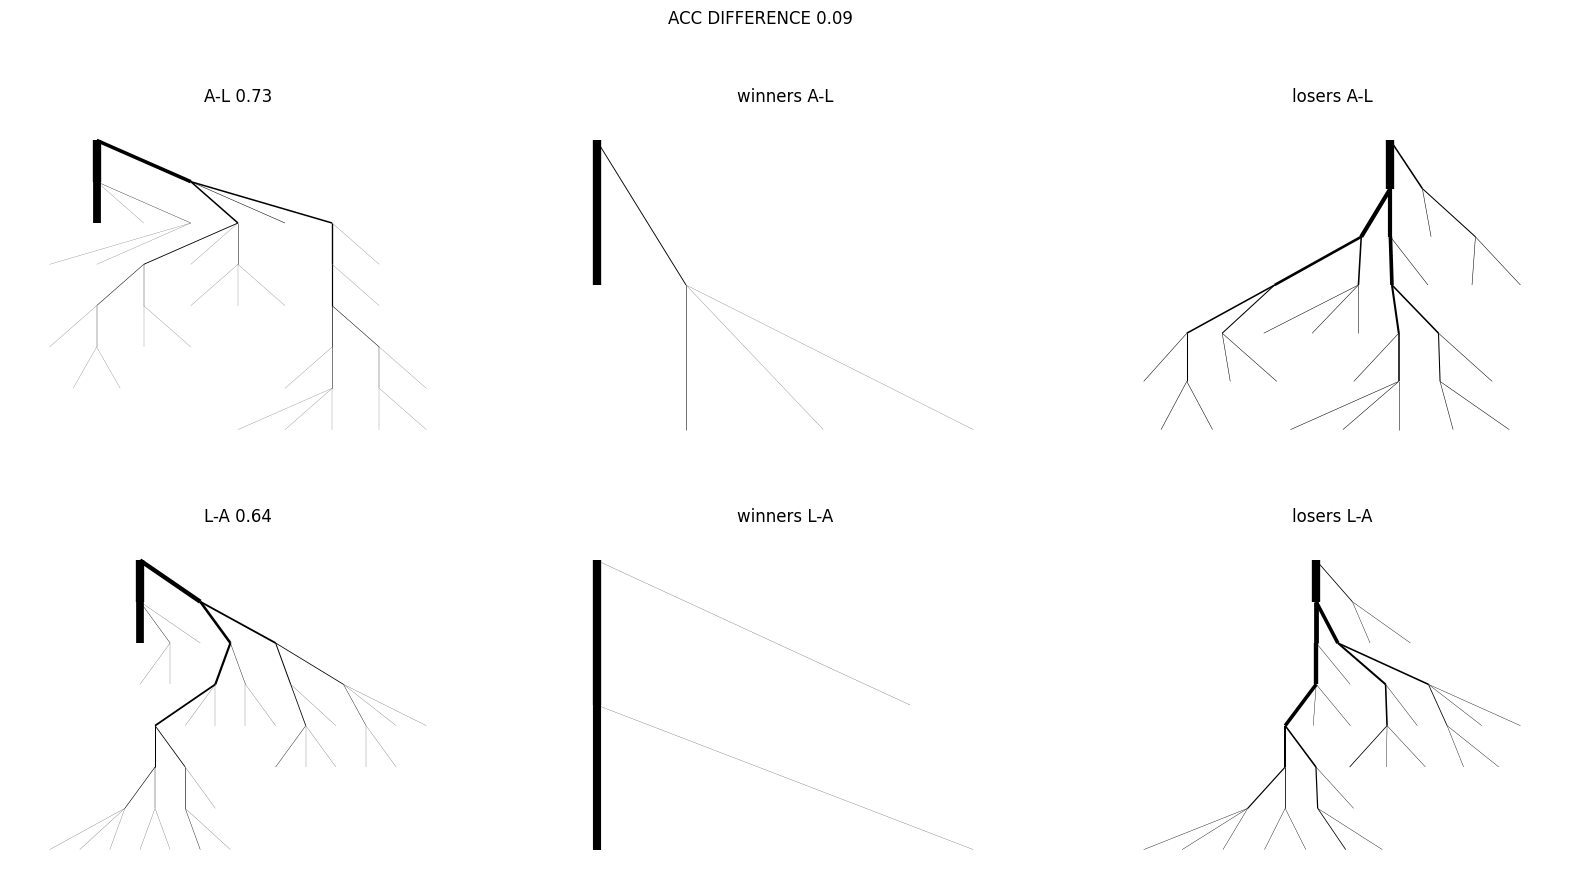

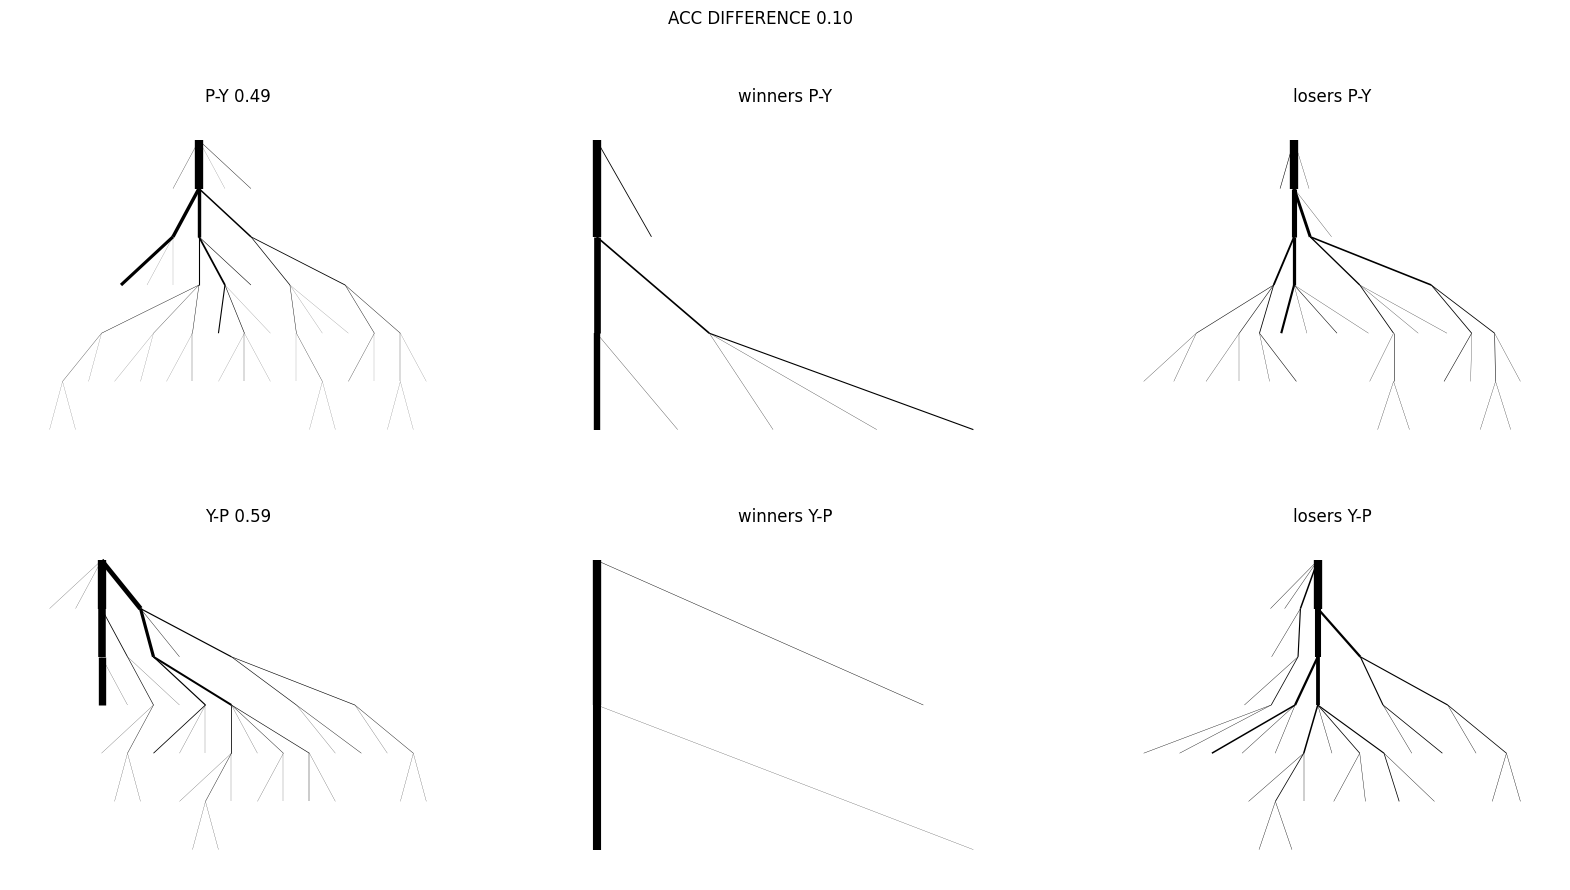

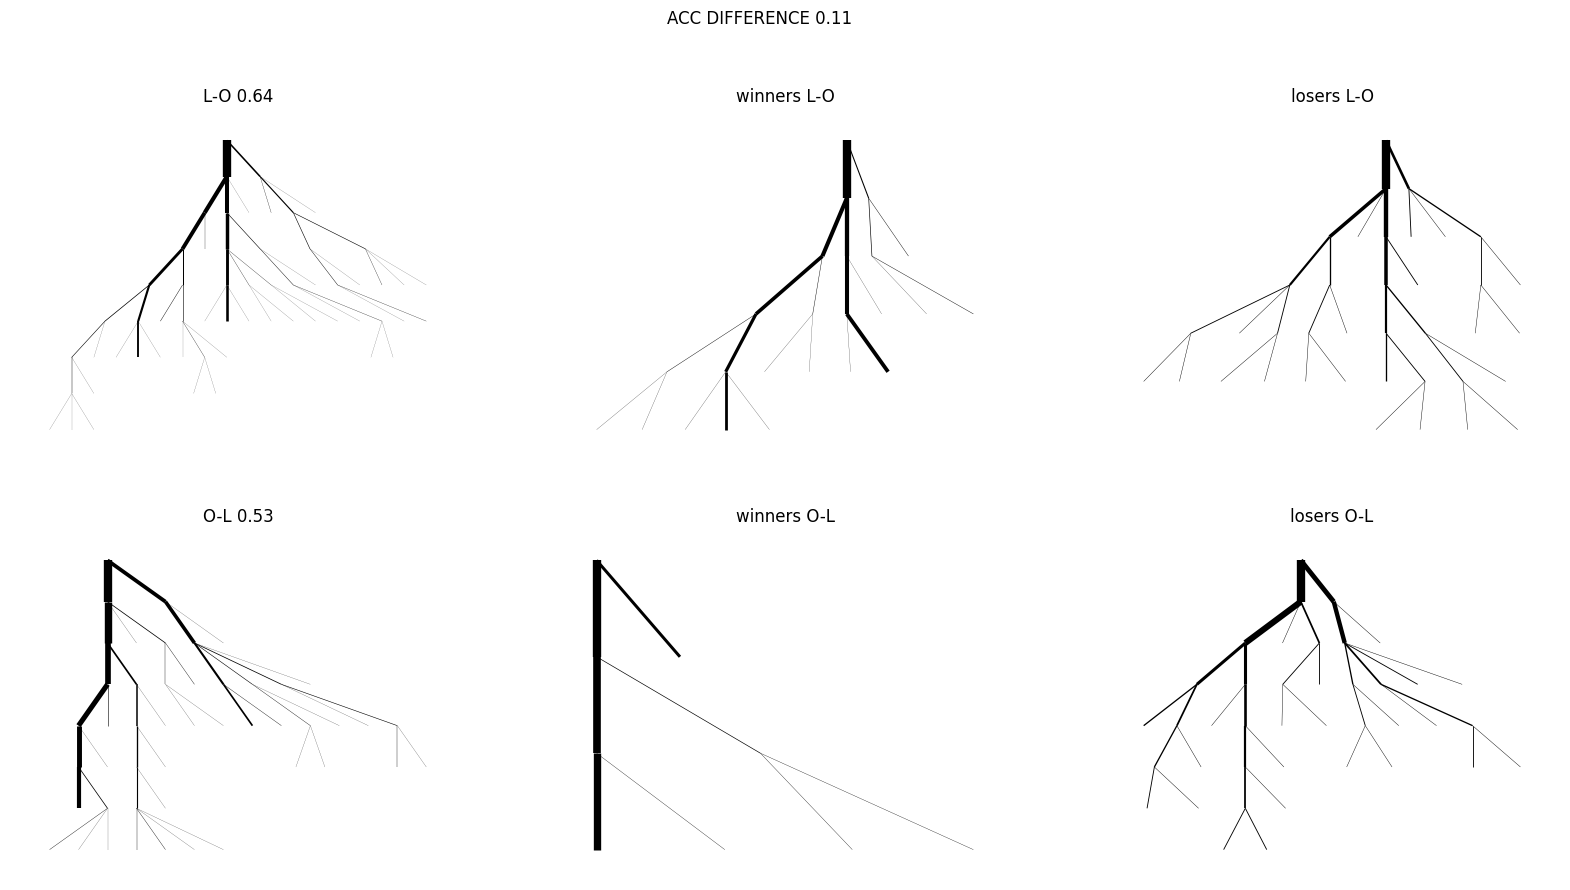

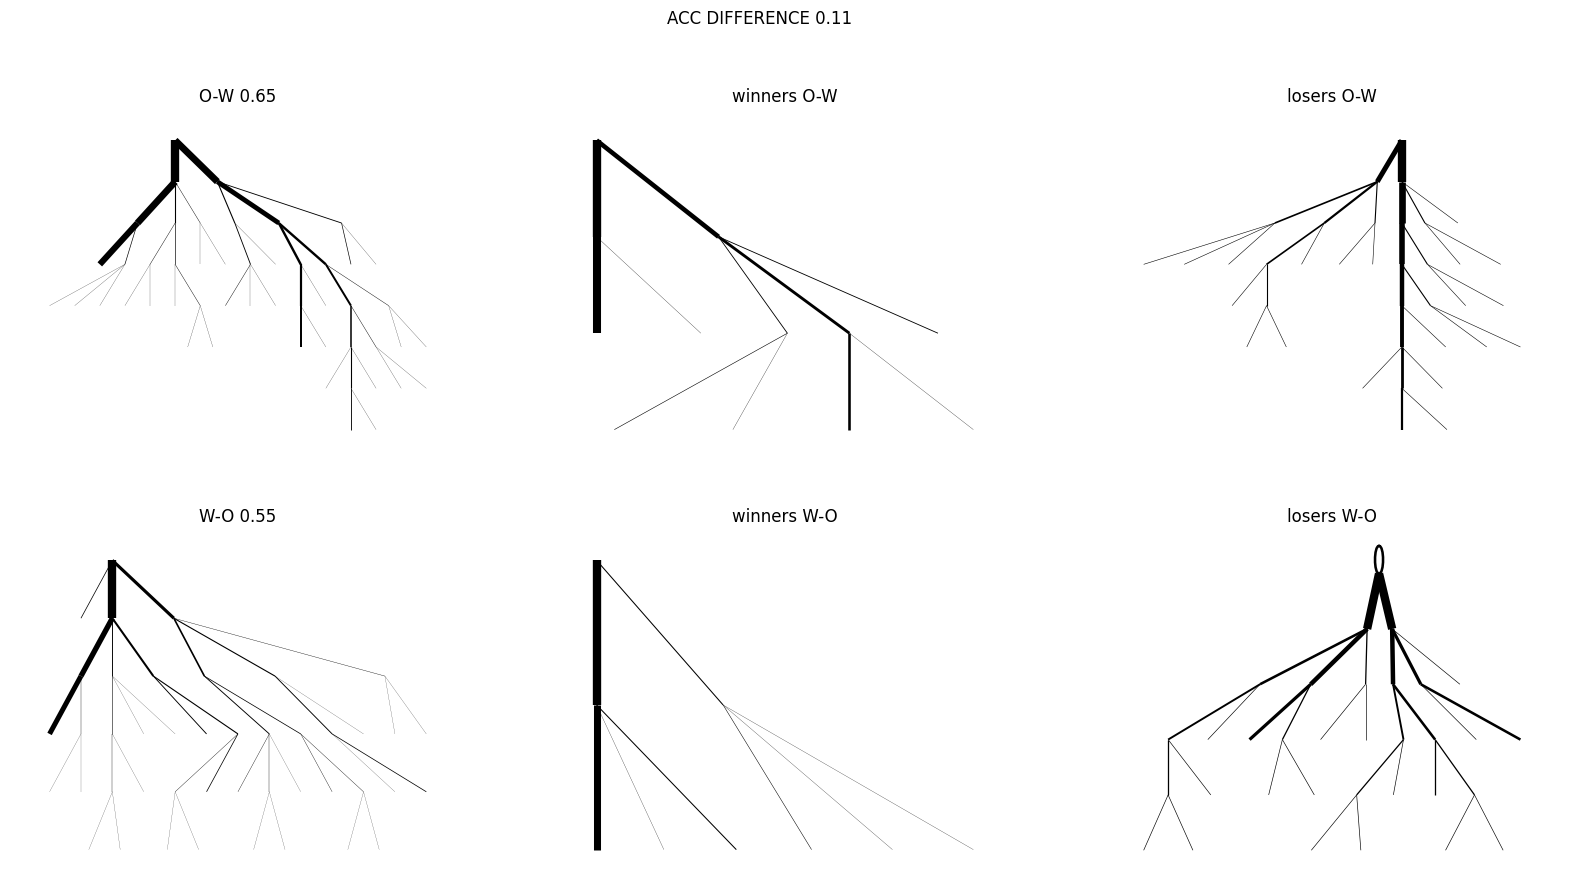

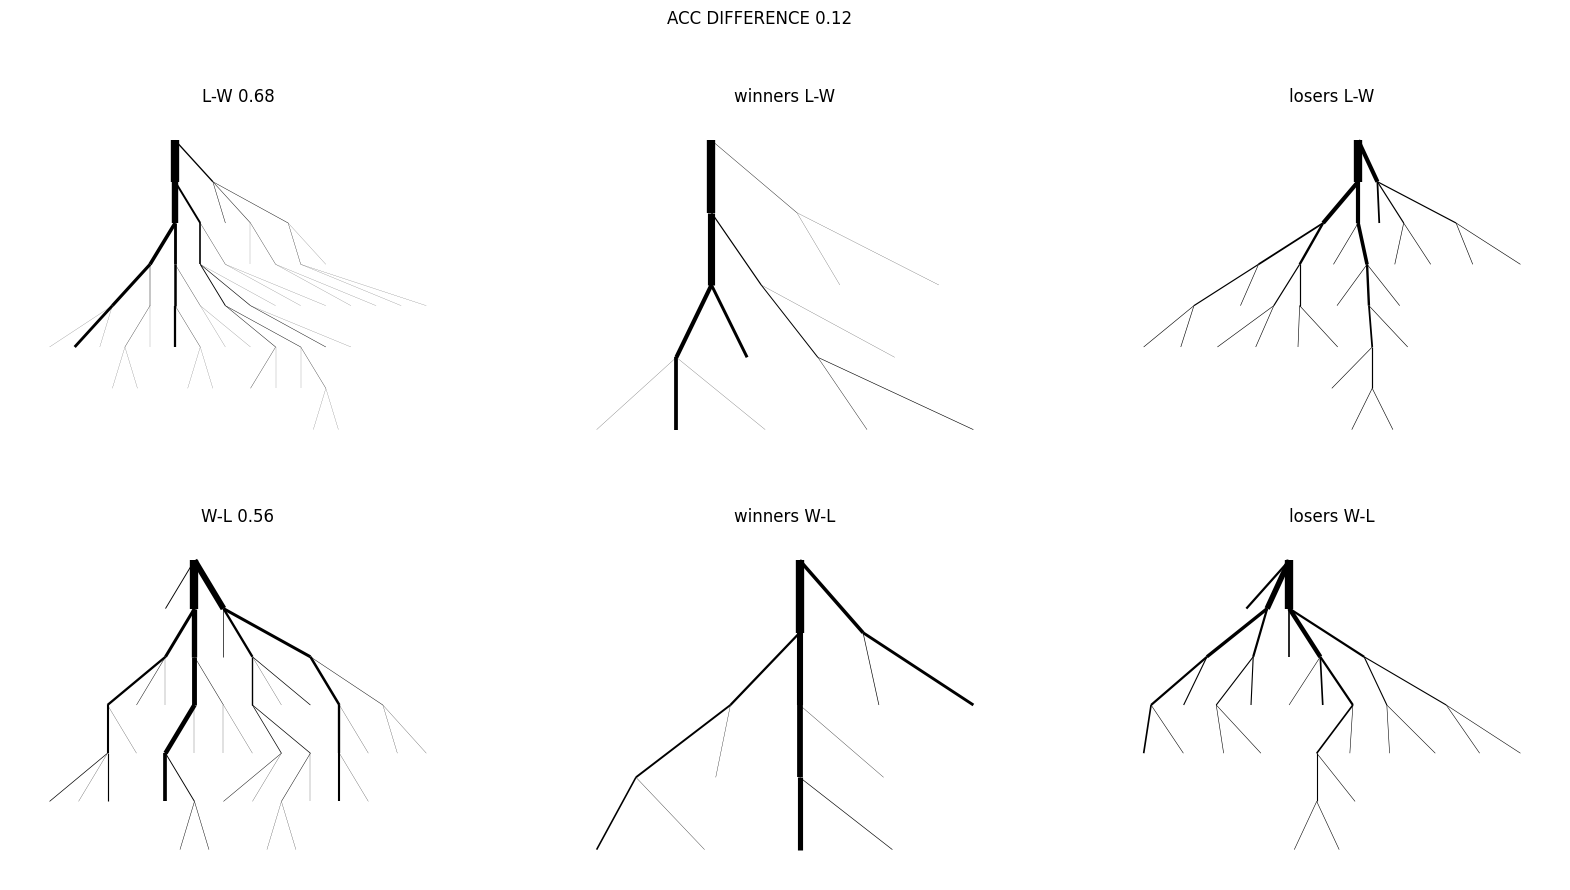

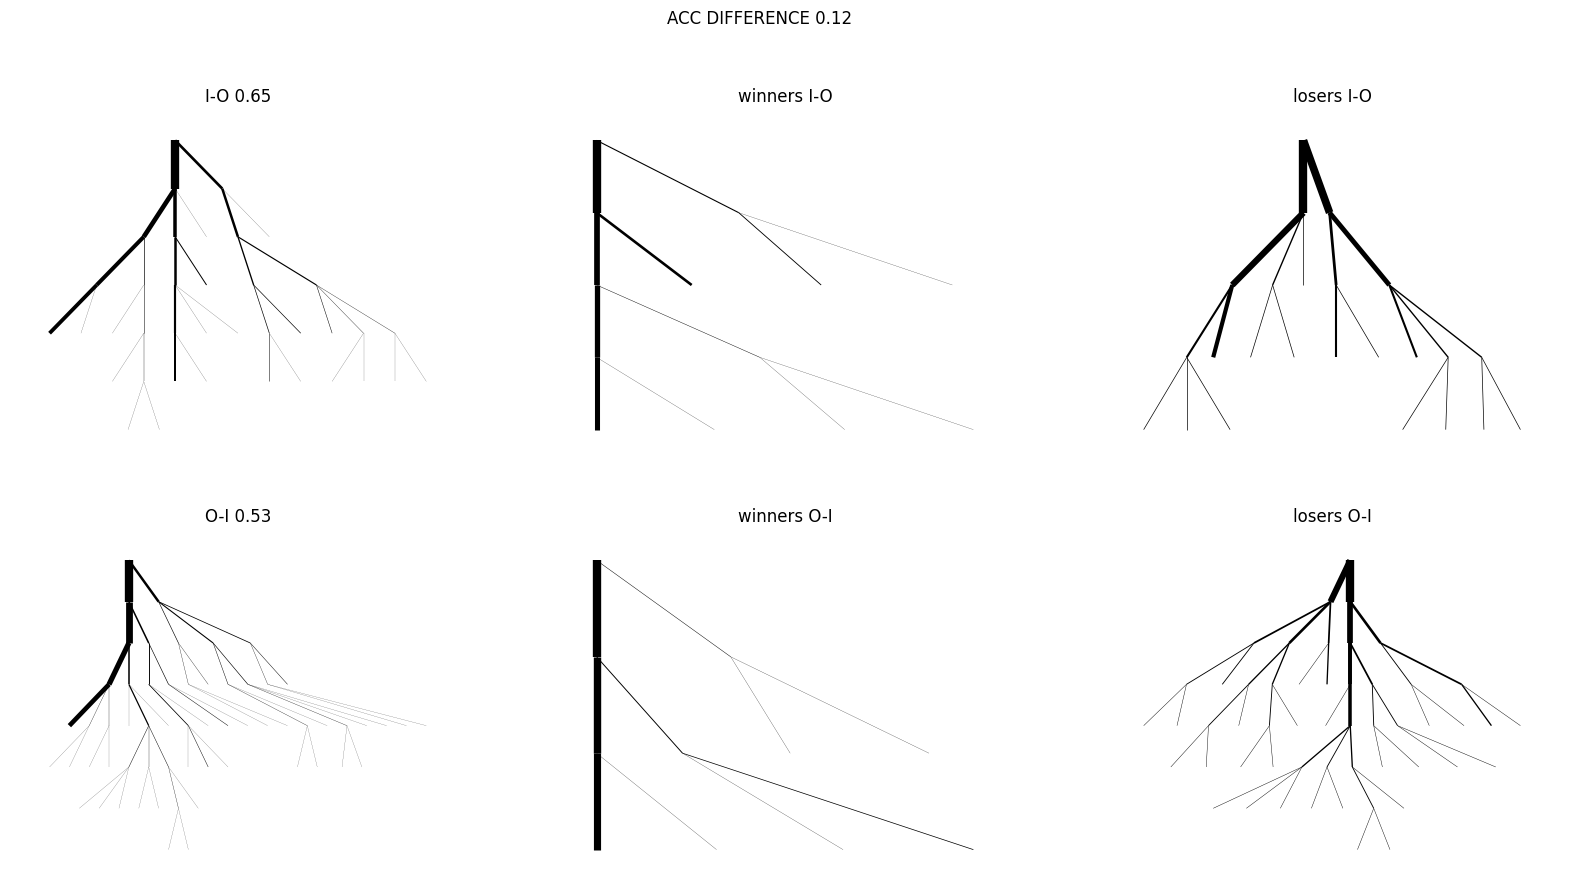

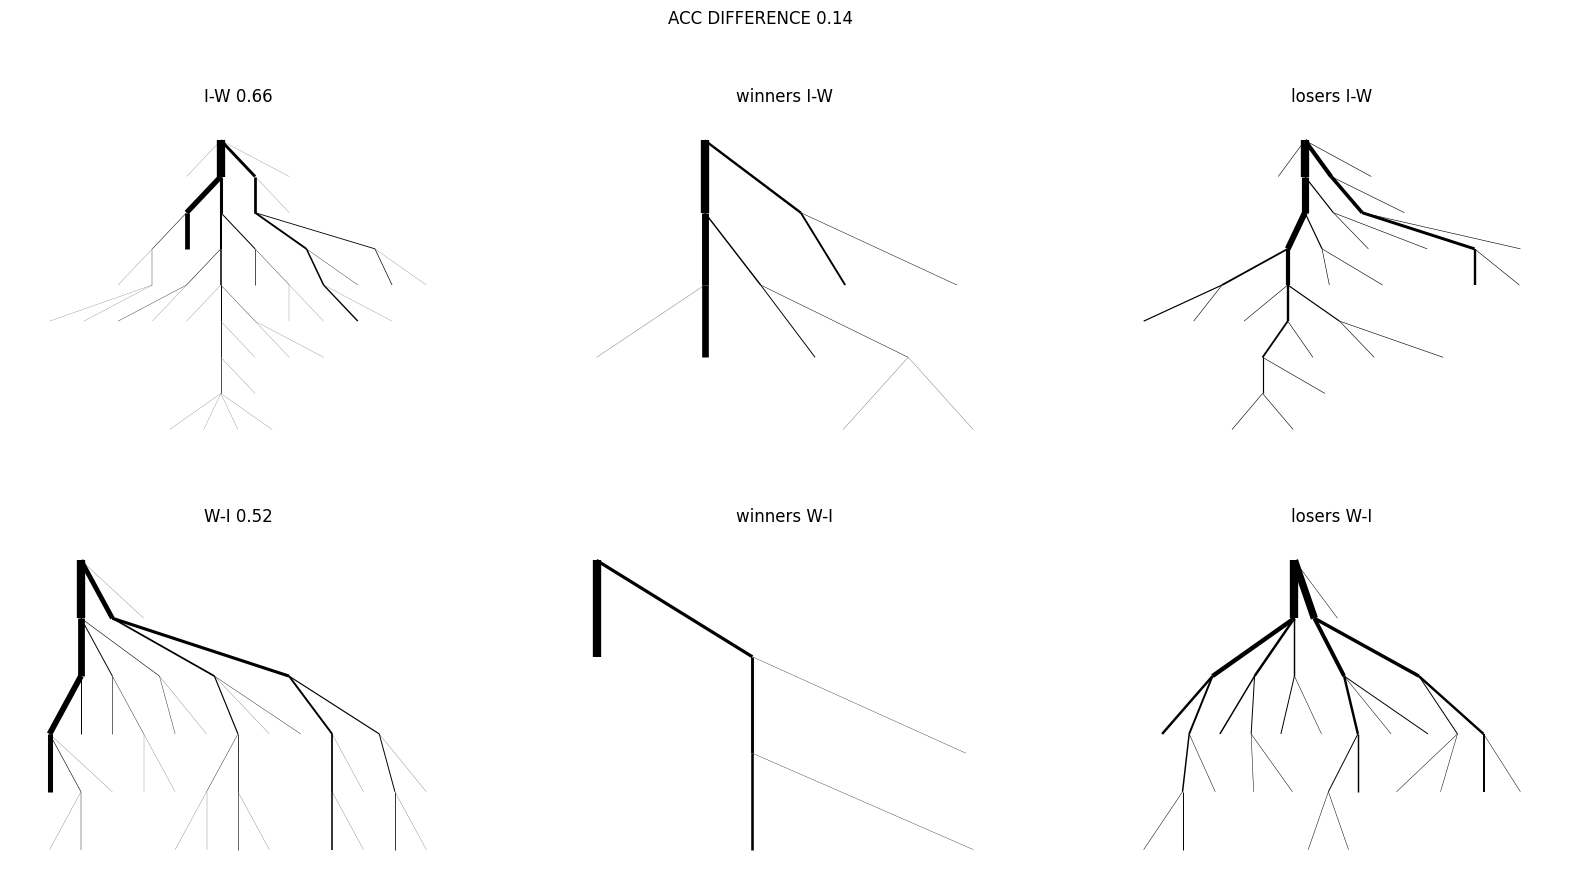

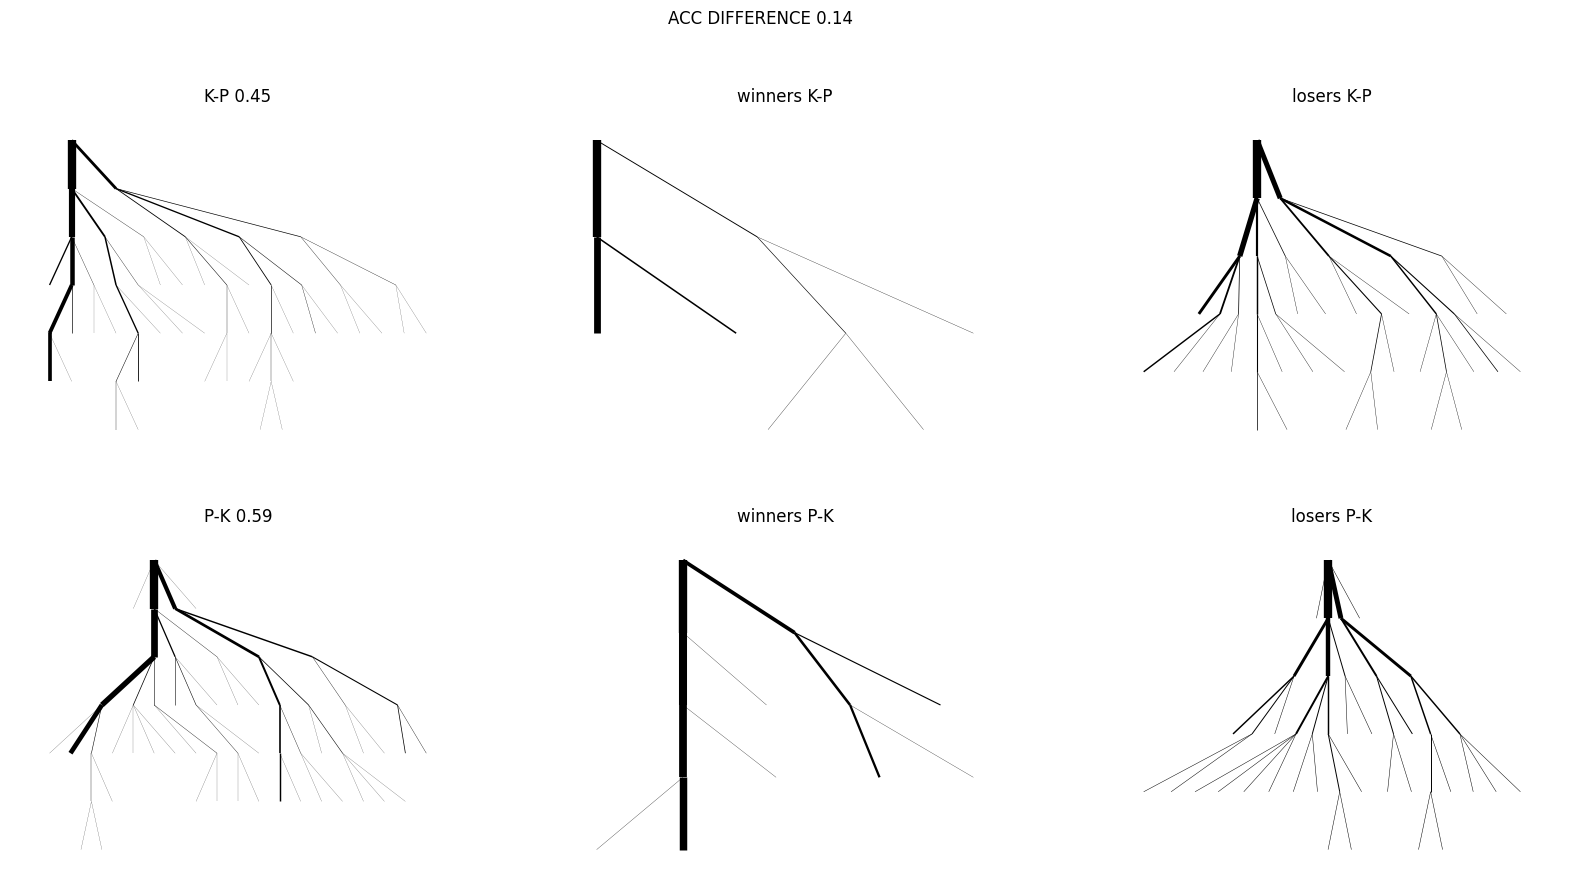

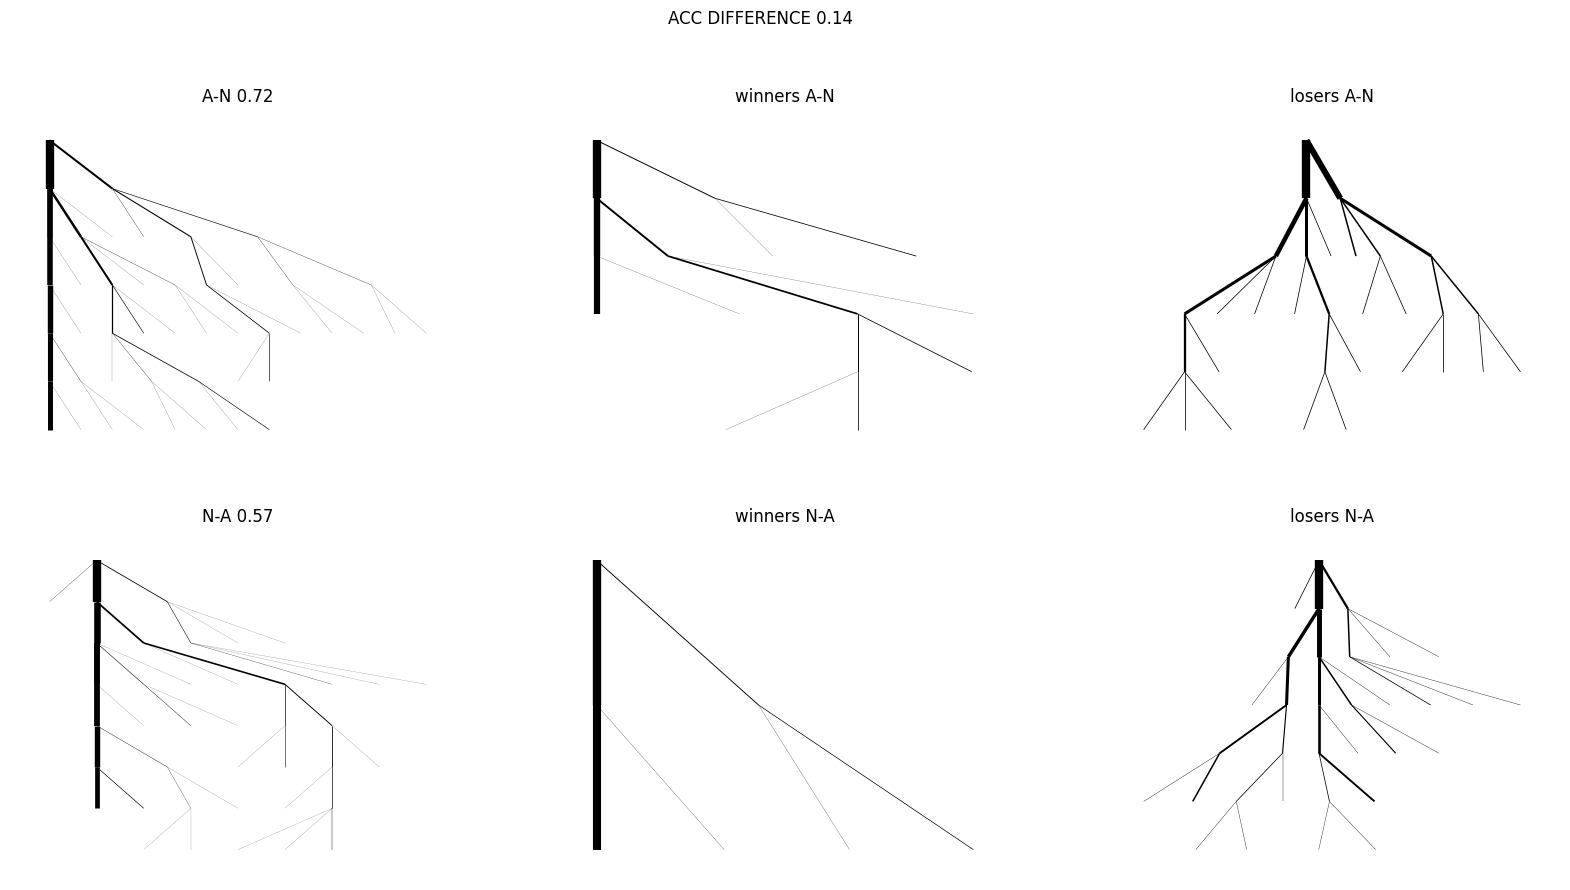

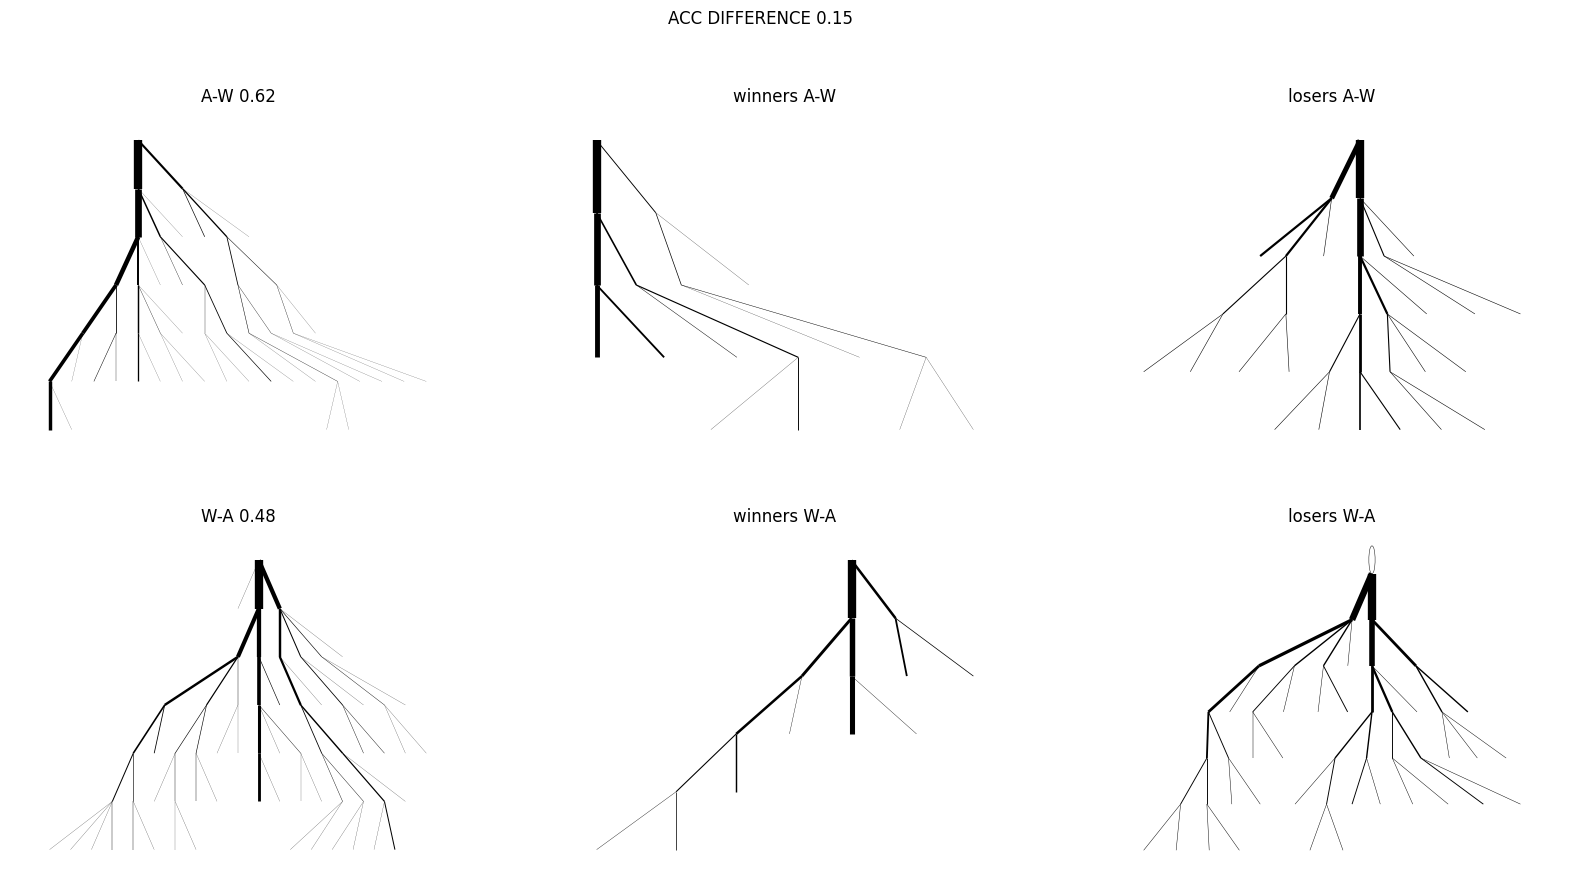

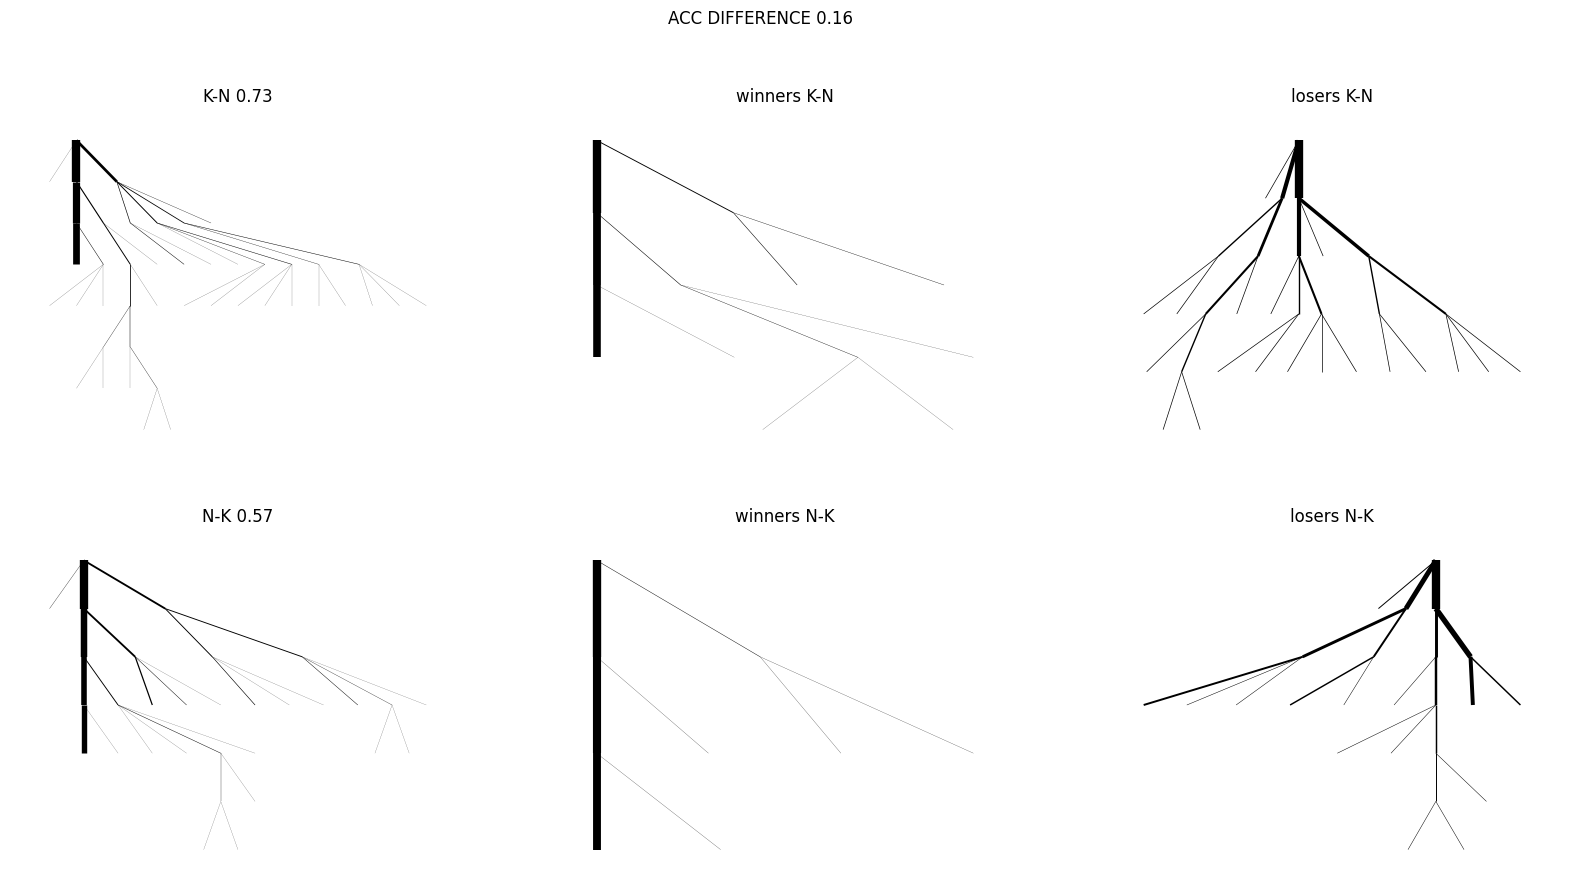

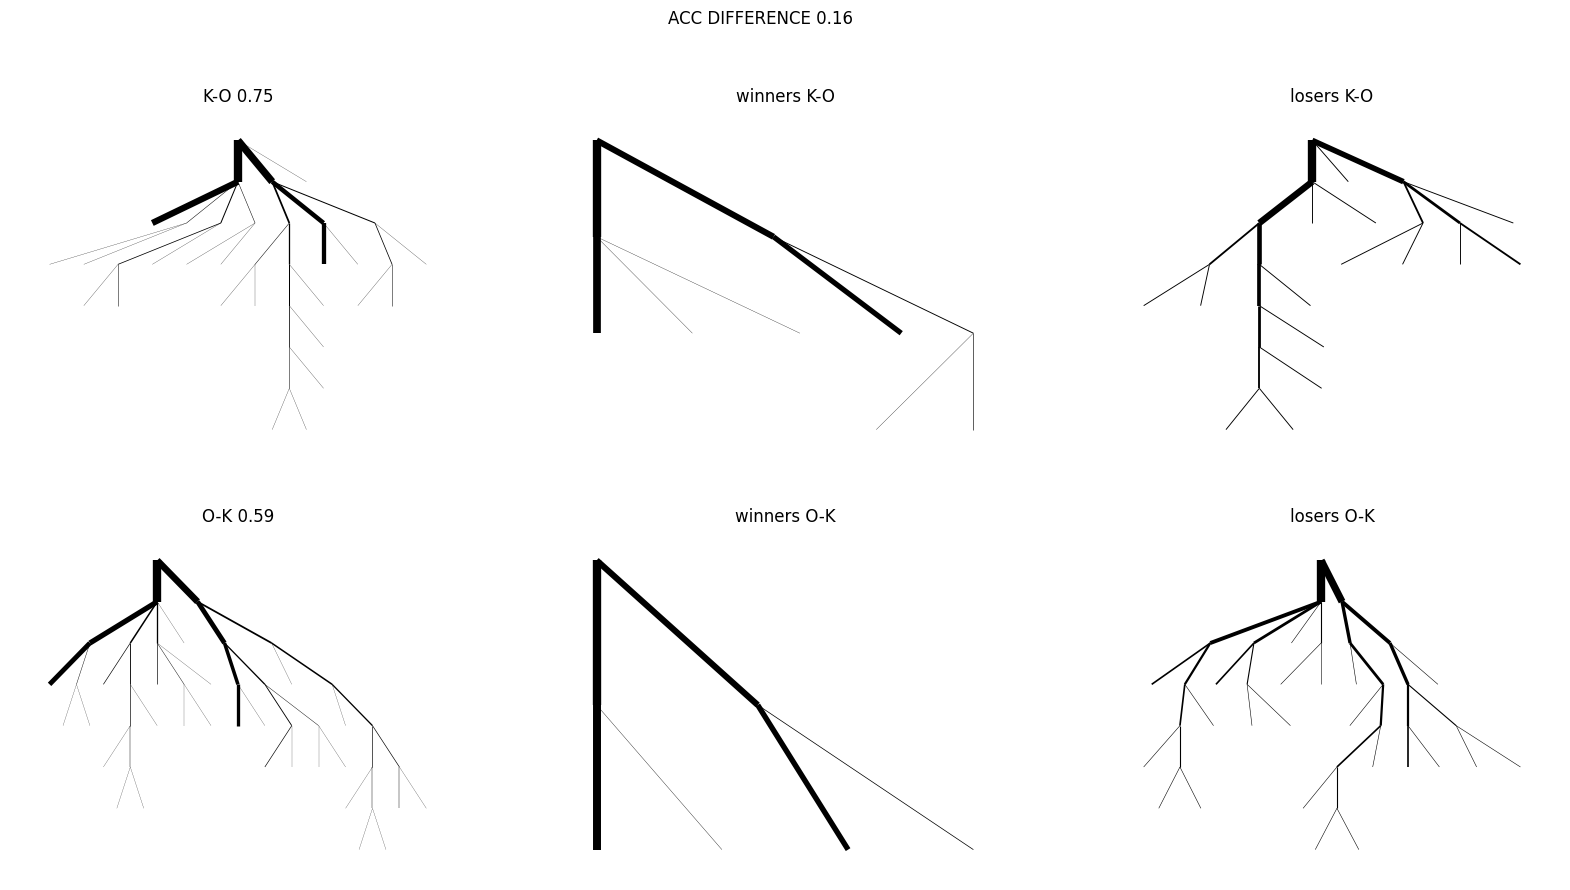

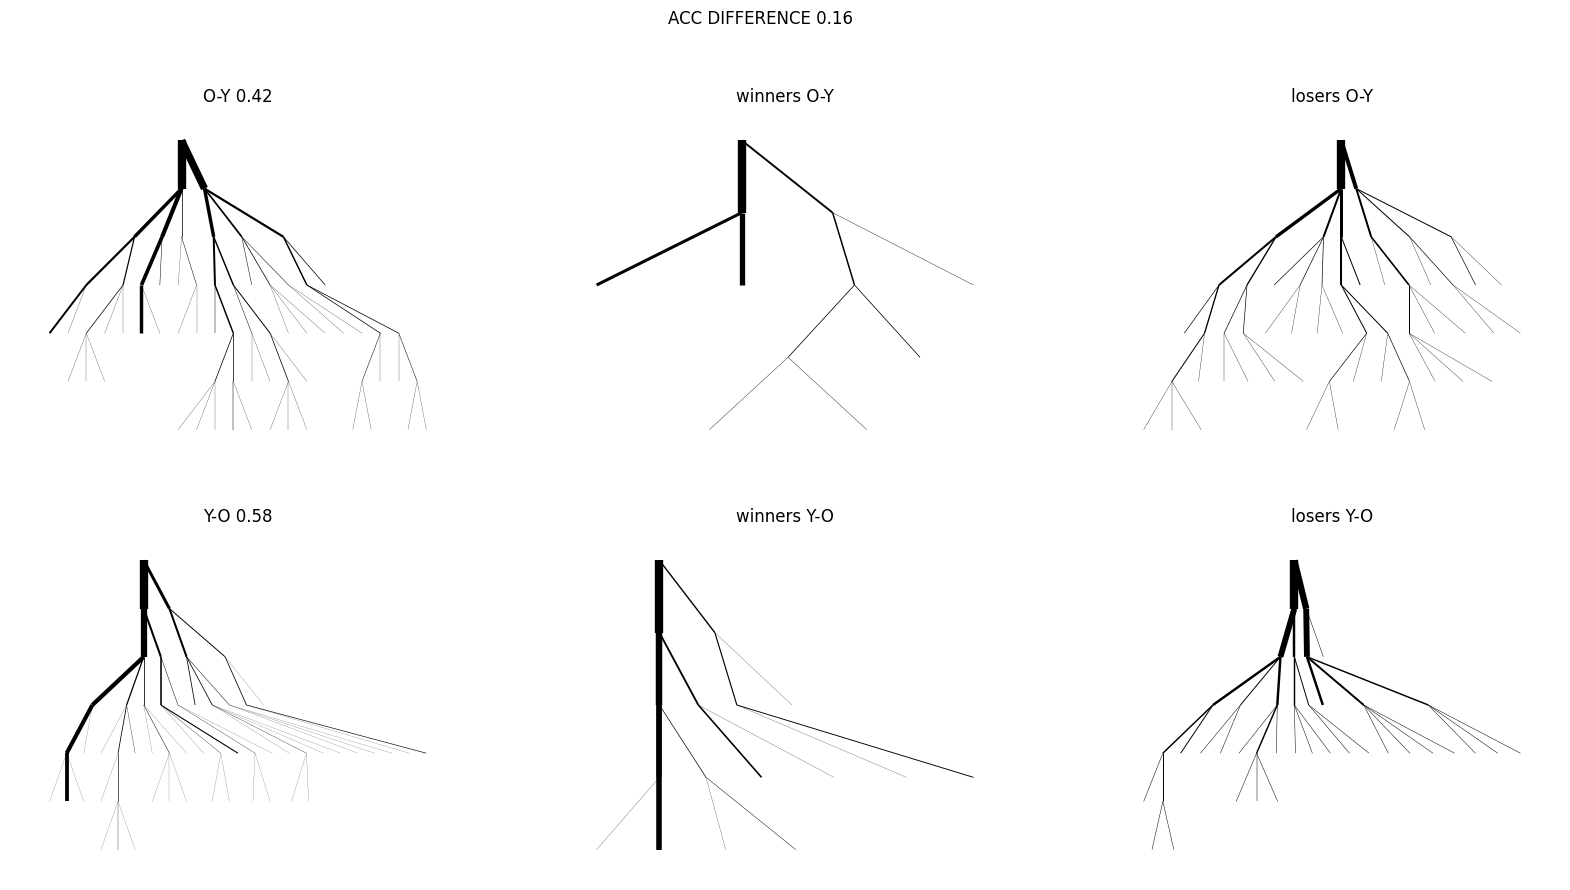

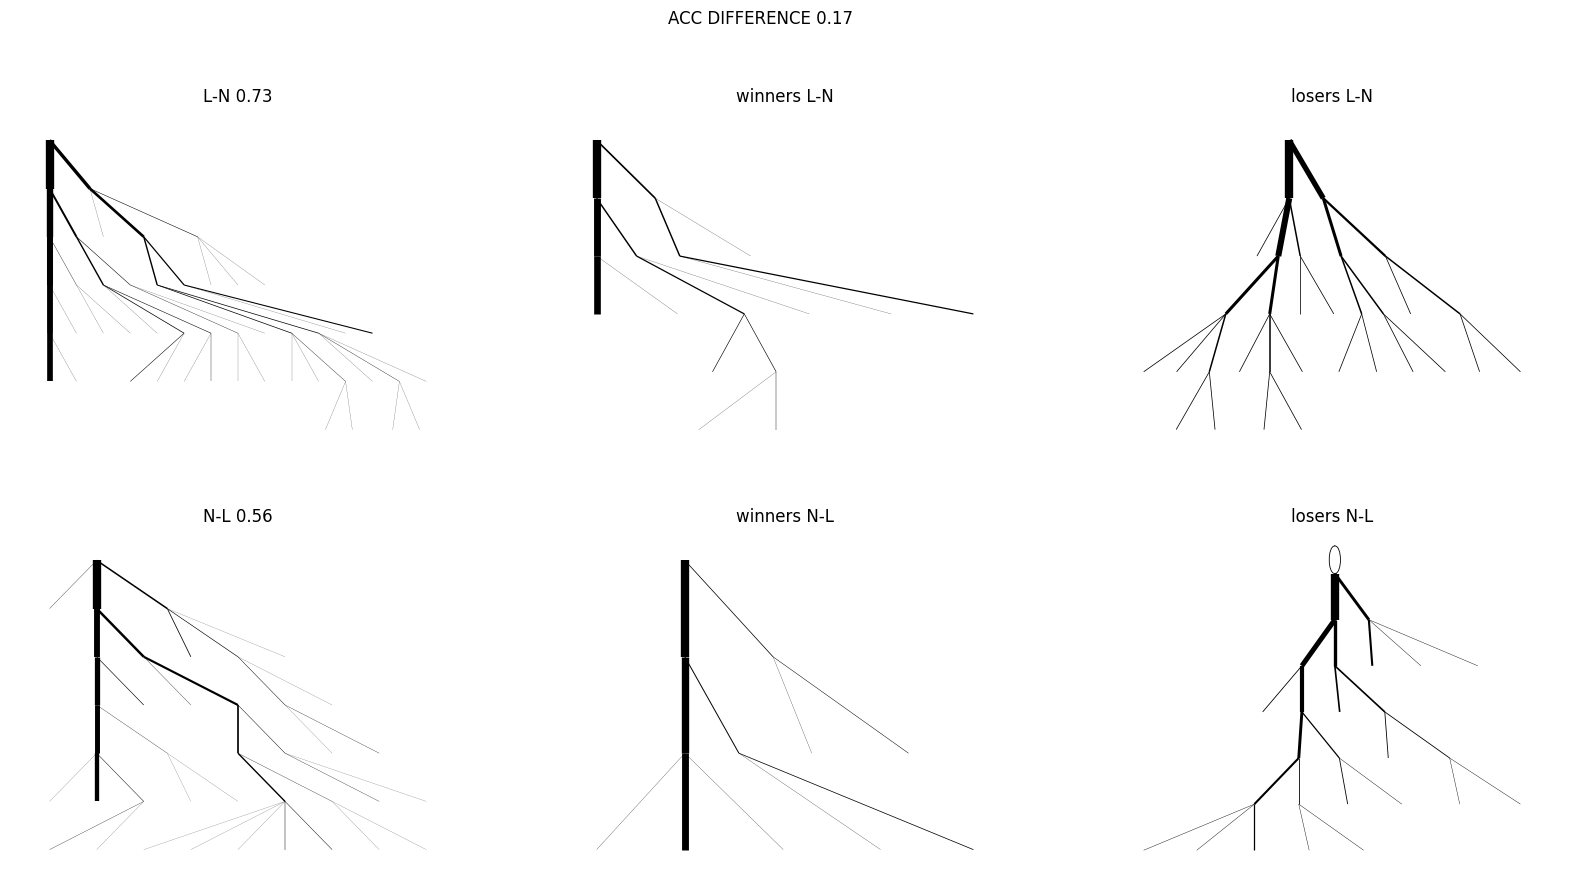

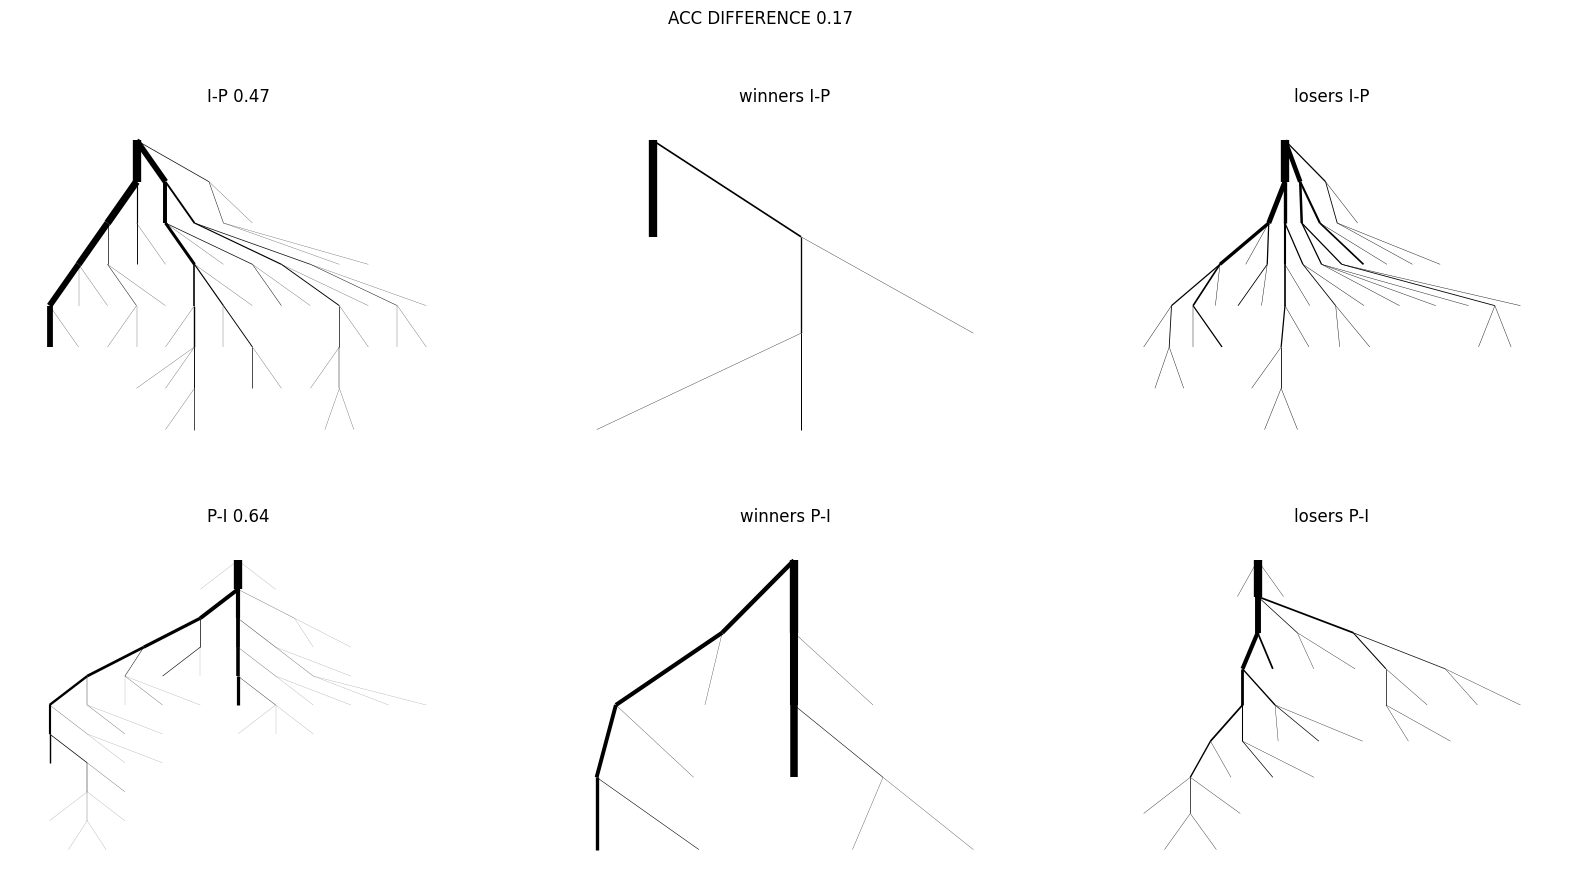

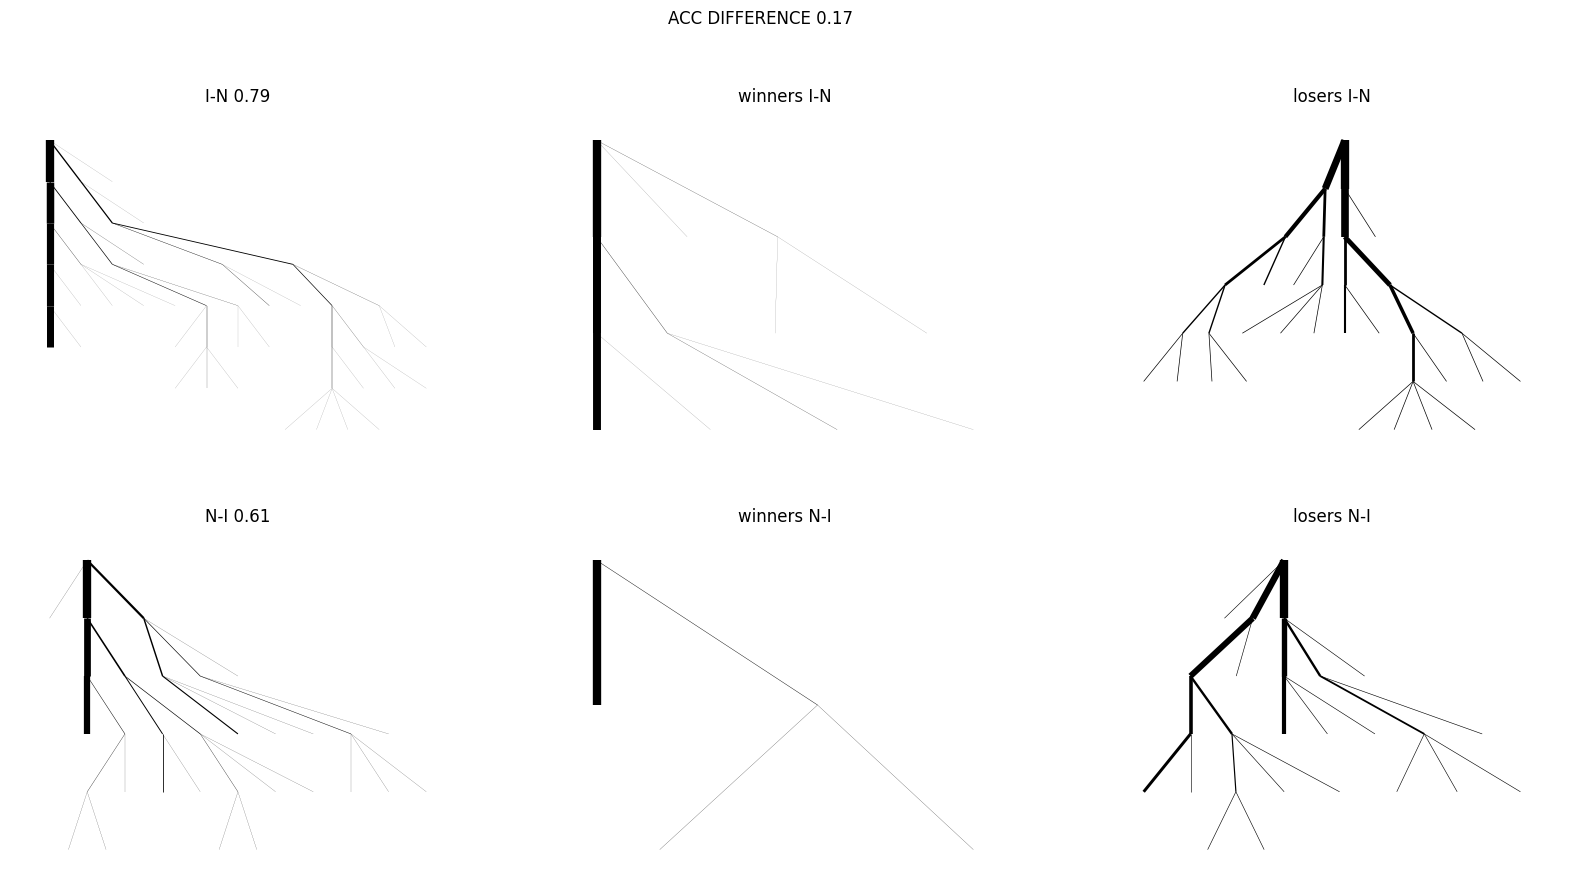

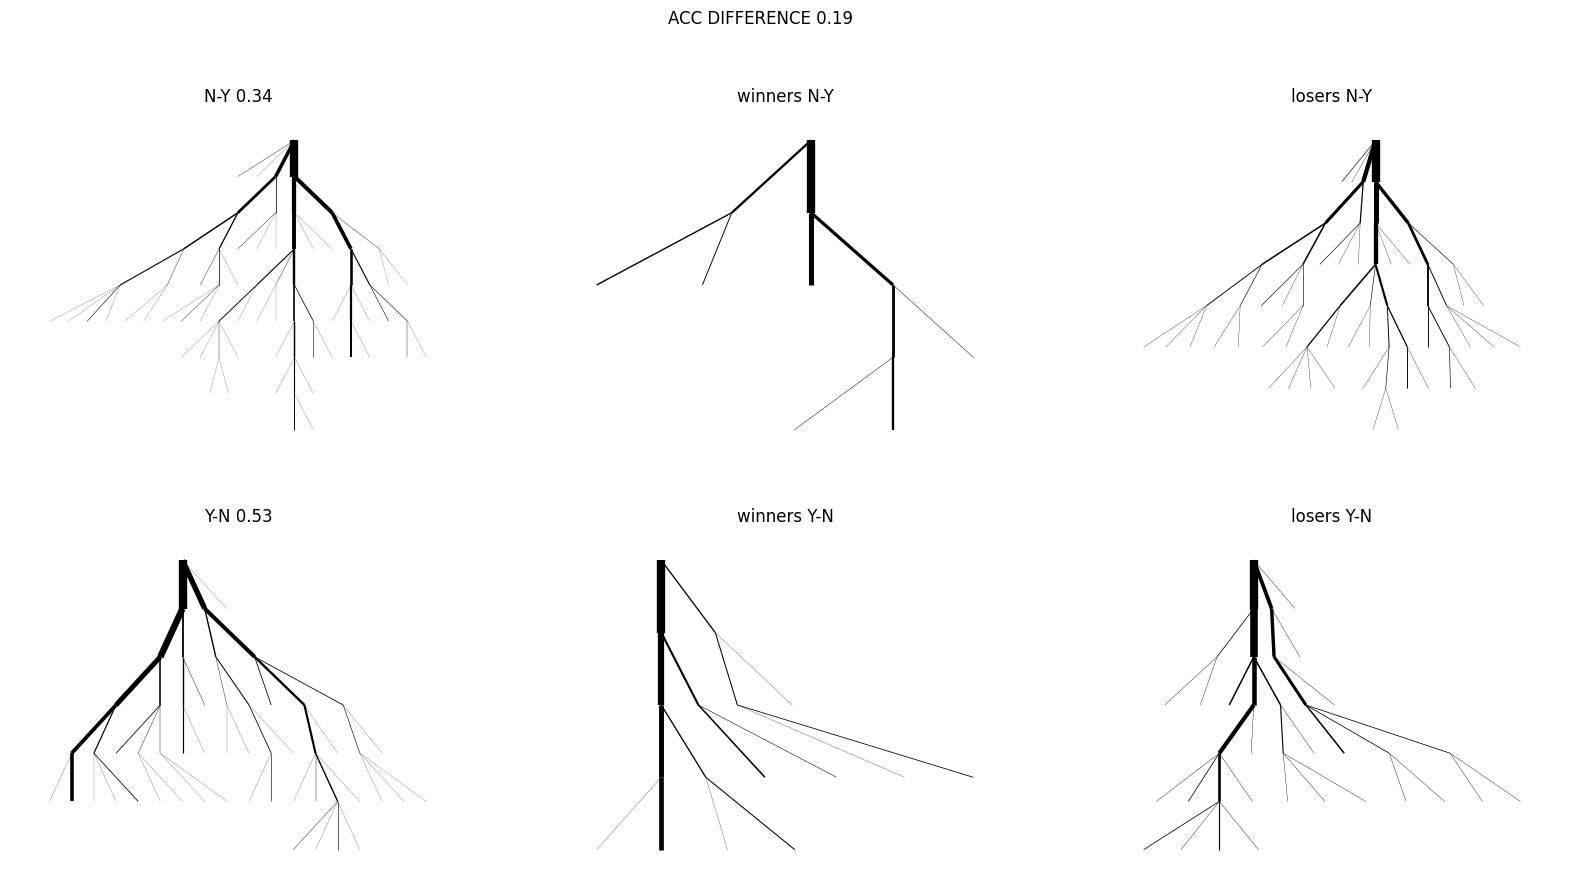

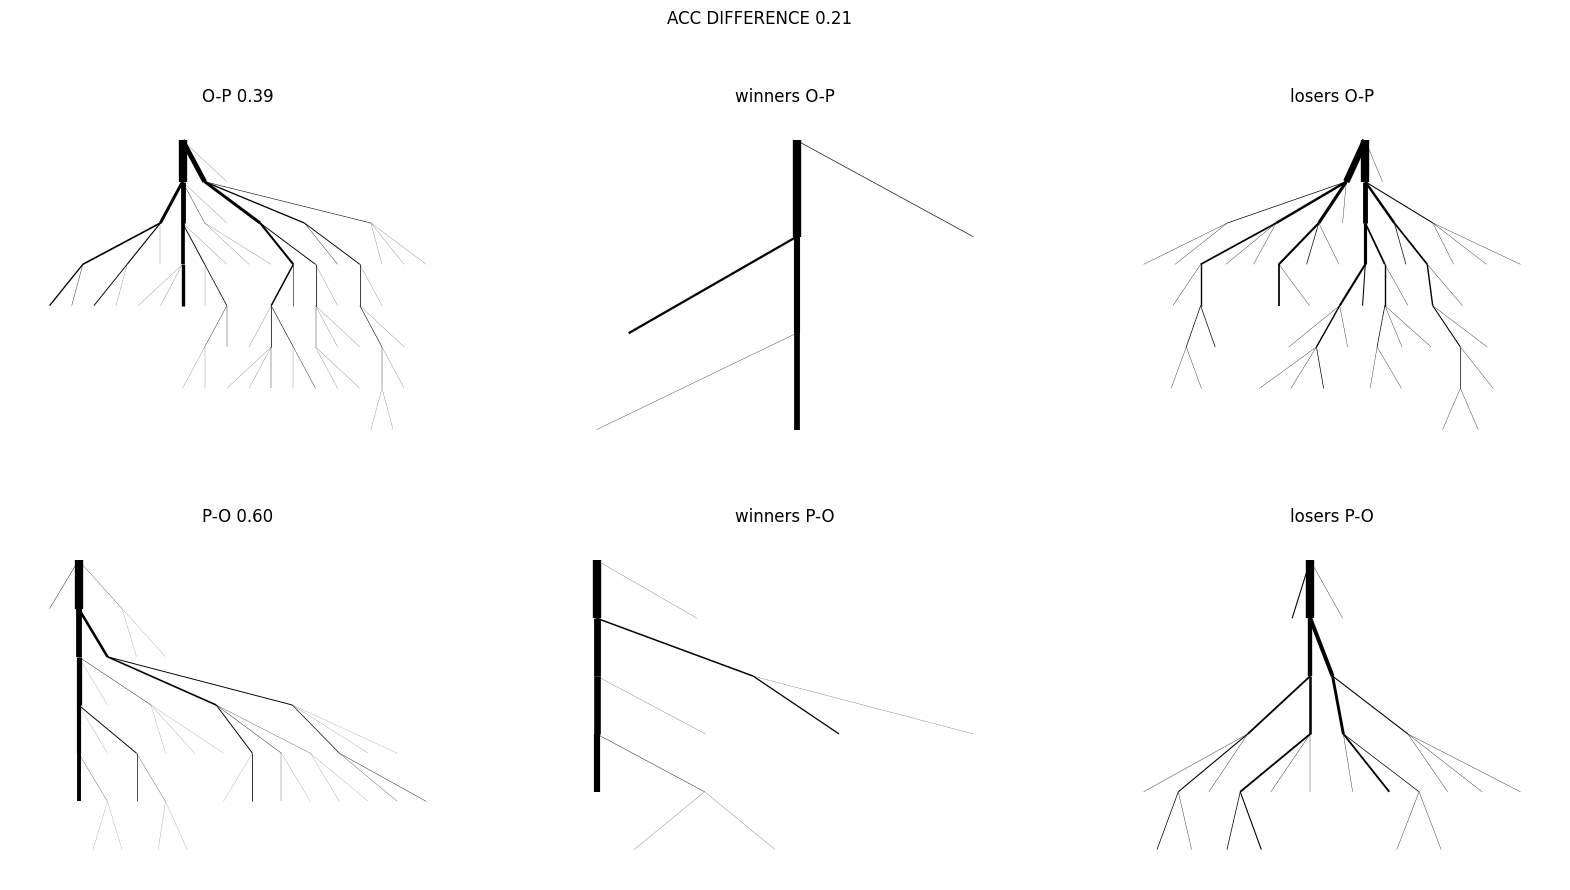

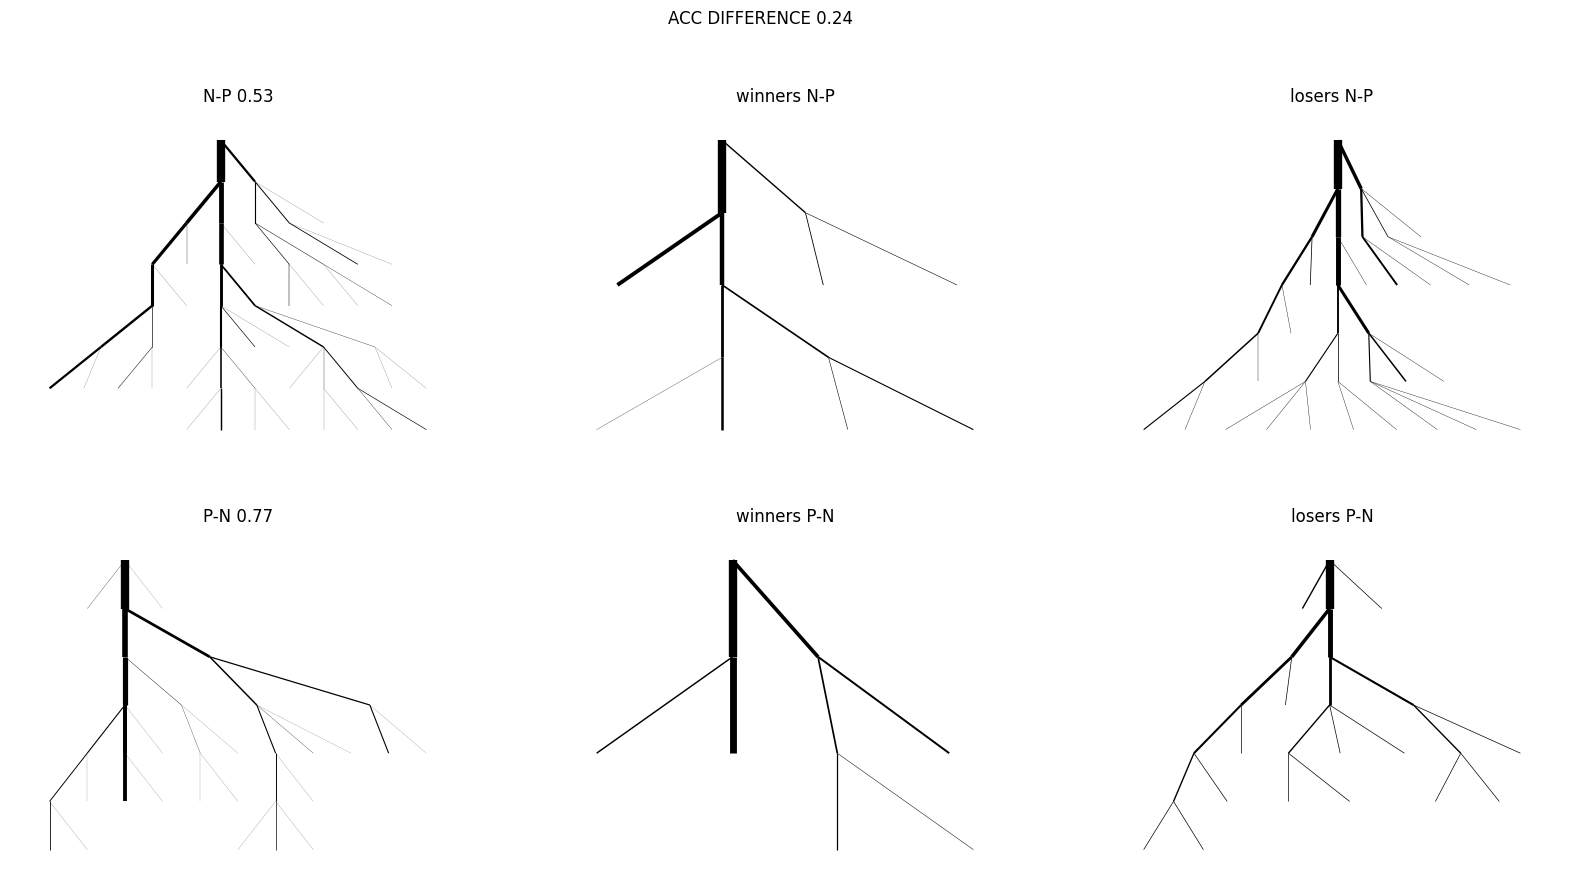

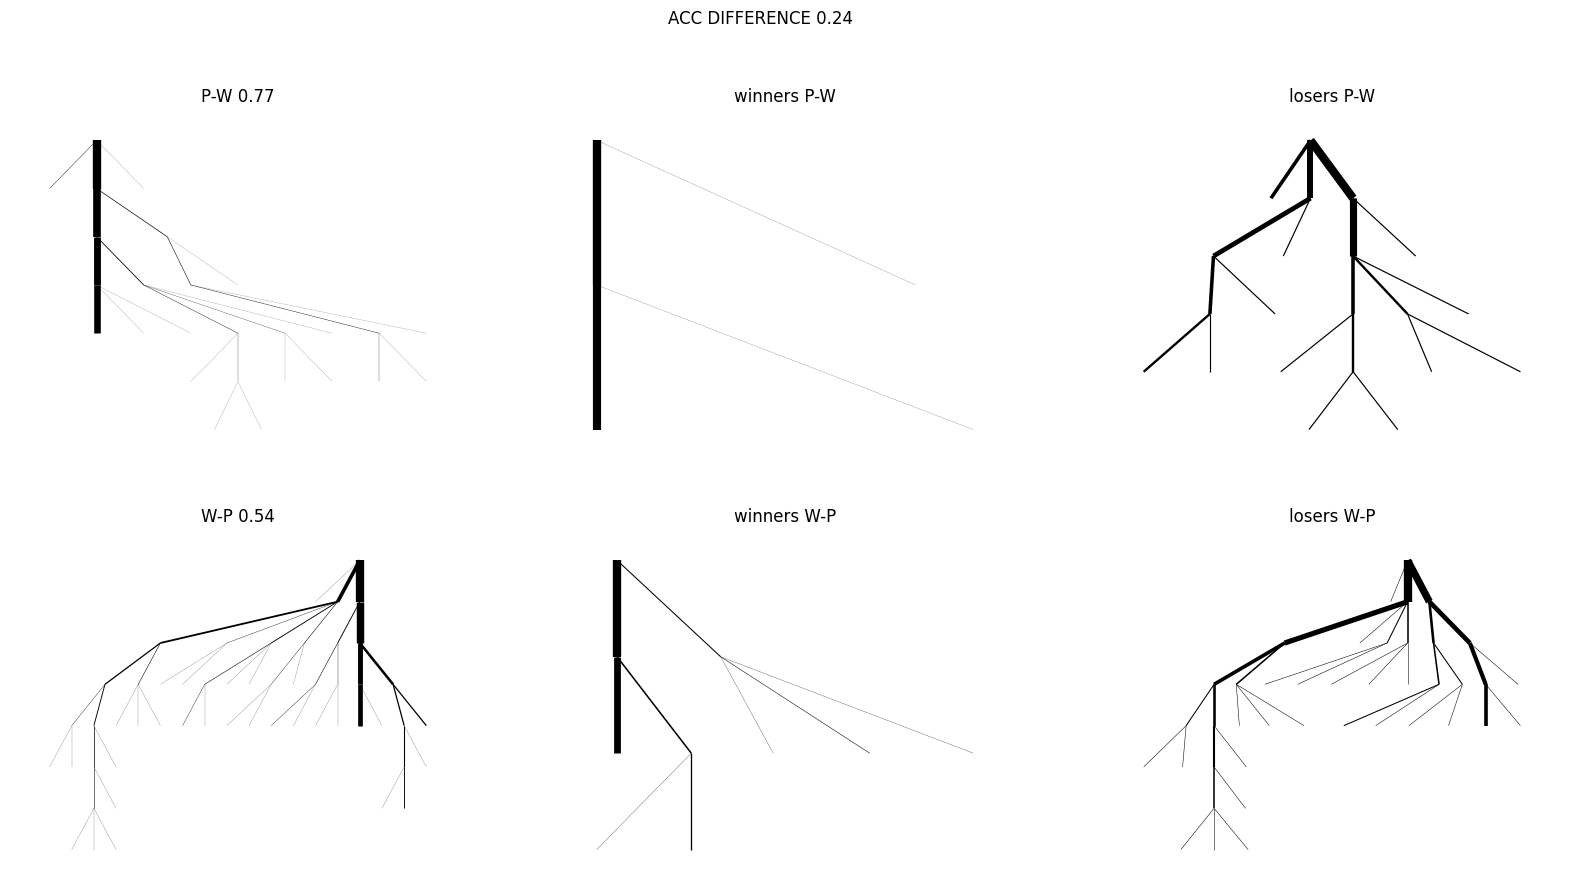

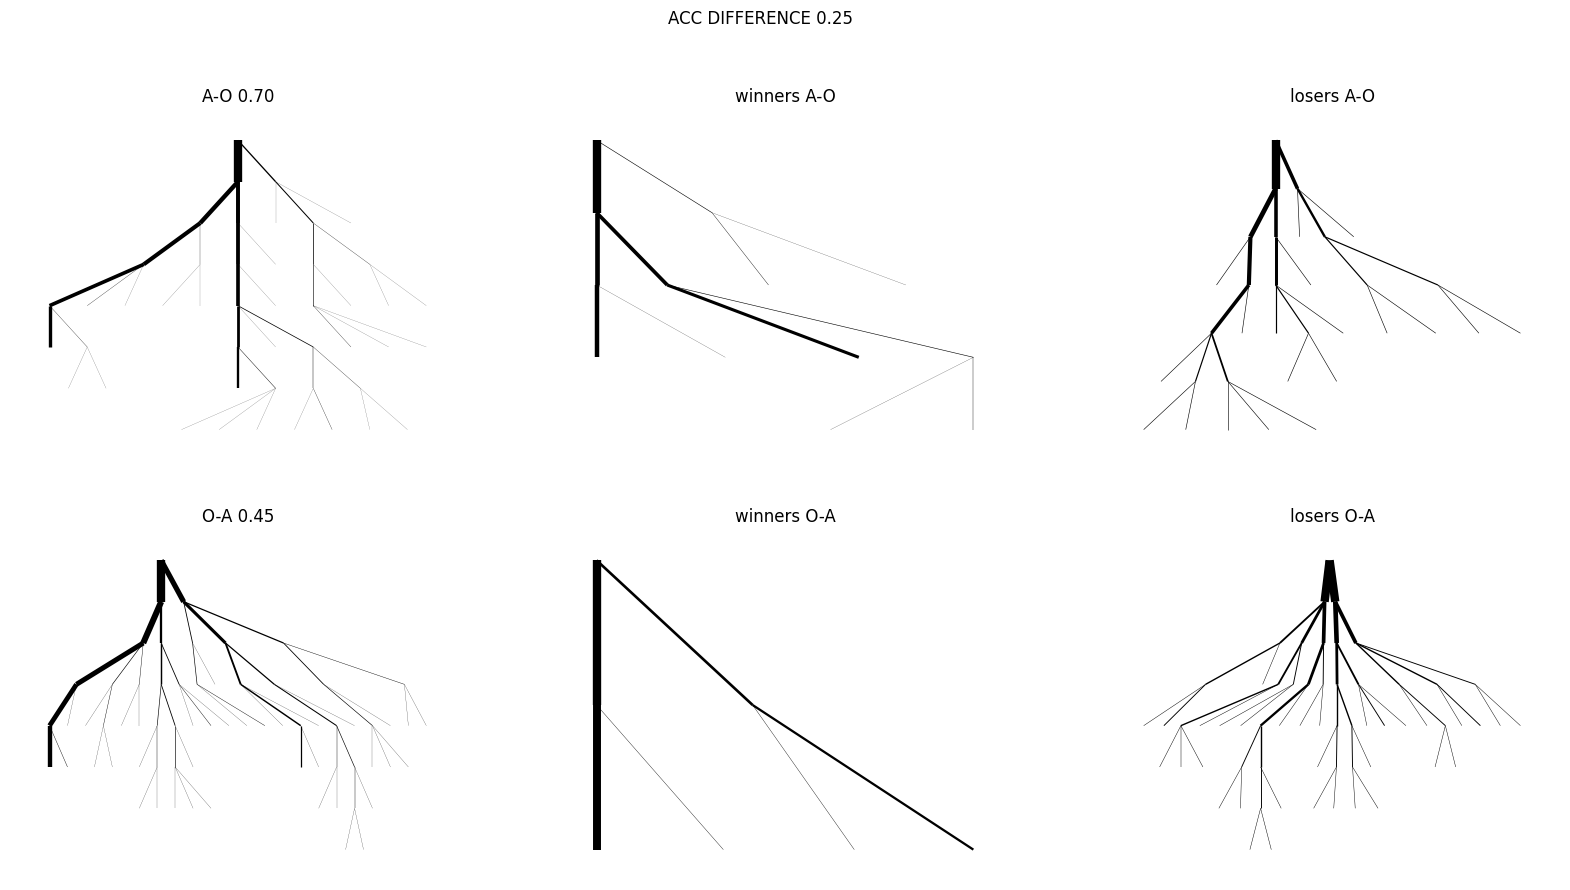

In [22]:
OBJECTS = "AIKLNOPWY"

acc_diffs = []
obj_pairs = []
for i in range(len(OBJECTS) - 1):
    for j in range(i+1, len(OBJECTS)):
        object_a, object_b = OBJECTS[i], OBJECTS[j] 

        acc_diffs.append(np.abs(tree_dict[(object_a, object_b)][1] - tree_dict[(object_b, object_a)][1]))
        obj_pairs.append((object_a, object_b))
        

sorted_order = [x for x in sorted(range(len(acc_diffs)), key=lambda x: acc_diffs[x])]
for i, tree_index in enumerate(sorted_order):
    object_a, object_b = obj_pairs[tree_index]
    
    fig, axes = plt.subplots(2, 3, figsize=(20,10))

    G, acc = tree_dict[(object_a, object_b)]
    plot_flow_tree(G, f"{object_a}-{object_b} {acc:.2f}", axes[0][0], just_edges=True)

    G, acc = tree_dict[(object_b, object_a)]
    plot_flow_tree(G, f"{object_b}-{object_a} {acc:.2f}", axes[1][0], just_edges=True)

    G = winner_tree_dict[(object_a, object_b)]
    plot_flow_tree(G, f"winners {object_a}-{object_b}", axes[0][1], just_edges=True)

    G = winner_tree_dict[(object_b, object_a)]
    plot_flow_tree(G, f"winners {object_b}-{object_a}", axes[1][1], just_edges=True)

    G = loser_tree_dict[(object_a, object_b)]
    plot_flow_tree(G, f"losers {object_a}-{object_b}", axes[0][2], just_edges=True)

    G = loser_tree_dict[(object_b, object_a)]
    plot_flow_tree(G, f"losers {object_b}-{object_a}", axes[1][2], just_edges=True)

    fig.suptitle(f"ACC DIFFERENCE {acc_diffs[tree_index]:.2f}")

    fig.savefig(f"figures/pairs/flow_tree_{object_a}-{object_b}.png")

    plt.show()

### 4. Questions


1. Is palindrome more common among winners than losers?? Is it predictive of success?
2. Did anyone who got it right go into an object?
3. Maybe the people who got it wrong did?
4. Look for particular foil? Will all losers end up at the same wrong place? What are the most common foils?? Is there systematic? Why are there consistent wrong places?
5. Do they get it wrong bc they end up at same place bc they take paths that get them to the wrong spot?
6. Are entropy of leaves and entropy of tree correlated? Especially for losers


#### Palindromes

Winners w/ palindrome: total=218 mean=0.08
Losers w/ palindrome: total=665 mean=0.33


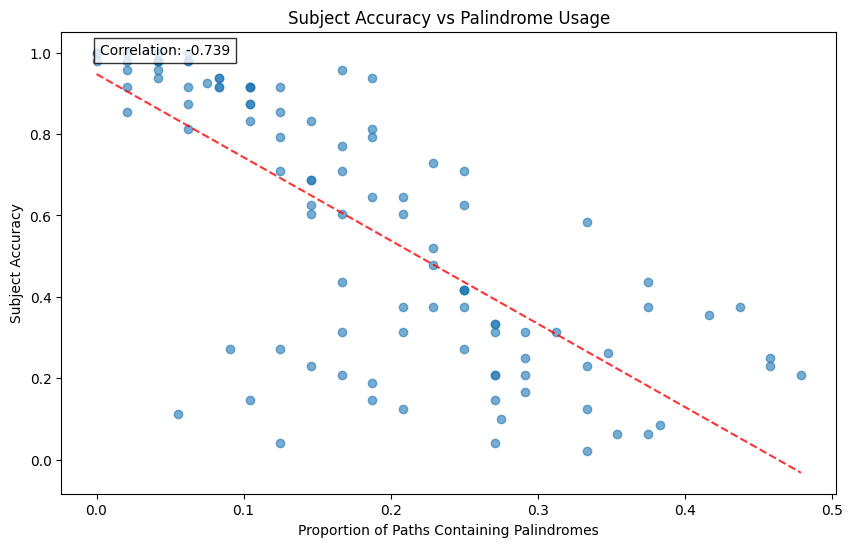

In [23]:
def contains_palindrome(traj):
    for i in range(len(traj)-2):
        if traj[i] == traj[i+2]:
            return True
    return False

winner_palindromes = []
loser_palindromes = []
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    accs = np.array(group["accuracy"])
    
    for traj, acc in zip(trajs, accs):
        if acc:
            winner_palindromes.append(contains_palindrome(traj))
        else:
            loser_palindromes.append(contains_palindrome(traj))
    
print(f"Winners w/ palindrome: total={np.sum(winner_palindromes)} mean={np.mean(winner_palindromes):.2f}")
print(f"Losers w/ palindrome: total={np.sum(loser_palindromes)} mean={np.mean(loser_palindromes):.2f}")

# Group by subject and calculate palindrome ratio and accuracy
subject_stats = []
for subject, group in test_df.groupby("Subject"):
    trajs = generate_trajs_from_df(group)
    palindrome_ratio = np.mean([contains_palindrome(traj) for traj in trajs])
    accuracy = np.mean(group["accuracy"])
    subject_stats.append({
        "subject": subject,
        "palindrome_ratio": palindrome_ratio,
        "accuracy": accuracy
    })

# Convert to DataFrame for plotting
stats_df = pd.DataFrame(subject_stats)

# Create scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(stats_df["palindrome_ratio"], stats_df["accuracy"], alpha=0.6)
plt.xlabel("Proportion of Paths Containing Palindromes")
plt.ylabel("Subject Accuracy")
plt.title("Subject Accuracy vs Palindrome Usage")

# Add trend line
z = np.polyfit(stats_df["palindrome_ratio"], stats_df["accuracy"], 1)
p = np.poly1d(z)
x_trend = np.linspace(stats_df["palindrome_ratio"].min(), stats_df["palindrome_ratio"].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", alpha=0.8)

# Calculate and display correlation
correlation = stats_df["palindrome_ratio"].corr(stats_df["accuracy"])
plt.text(0.05, 0.95, f"Correlation: {correlation:.3f}", 
         transform=plt.gca().transAxes, 
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

In [28]:
df = pd.read_csv("data/MLINDIV_train_full.csv")

# load test df
test_df = df[df["eprocs"].str.contains("Test")]

test_df["subj_mean_acc"] = test_df.groupby("Subject")["accuracy"].transform("mean")
test_df["path_mean_acc"] = test_df.groupby(["StartAt", "EndAt"])["accuracy"].transform("mean")

test_df['quartile'] = (
    pd.qcut(test_df['subj_mean_acc'], 4, labels=[1, 2, 3, 4])
)

test_df["path_mean_acc_by_Q"] = test_df.groupby(["StartAt", "EndAt", "quartile"])["accuracy"].transform("mean")
test_df["accuracy"] = test_df["accuracy"].astype(bool)

test_df["trajs"] = test_df["paths"].apply(generate_traj_from_path)
test_df["traj_strs"] = test_df["trajs"].apply("".join)


subject_df = pd.read_csv("data/MLINDIV_subject_info.csv")
subject_df["Subject"] = pd.to_numeric(subject_df["Spatial Neuro ID"], errors="coerce")
subject_df = subject_df[~subject_df["Subject"].isna()]

subject_df["is_man"] = (subject_df["Sex"] == "M")

merged_test_df = pd.merge(test_df, subject_df, on="Subject")
# merged_df[["Sex", "Proportion Correct (new version)", "subject_mean_acc"]]

#### Tree and leaf entropy

In [30]:
# Calculate entropy for winner/loser trees and final nodes

# Helper function to calculate entropy
def calculate_entropy(counts):
    probabilities = counts / np.sum(counts)
    # Remove zero probabilities to avoid log(0)
    probabilities = probabilities[probabilities > 0]
    return -np.sum(probabilities * np.log2(probabilities))

def calculate_tree_entropy(G):
    # Get all non-leaf nodes (nodes with outgoing edges)
    non_leaf_nodes = [node for node in G.nodes() if len(list(G.neighbors(node))) > 0]
    
    tree_entropy = 0
    for node in non_leaf_nodes:
        # Get outgoing edges and their weights
        edge_weights = [G.edges[node, successor]['weight'] for successor in G.neighbors(node)]
        total_weight = sum(edge_weights)
        
        if total_weight > 0:  # Avoid division by zero
            # Calculate probabilities for each branch
            probabilities = np.array(edge_weights) / total_weight
            
            # Calculate entropy for this node
            node_entropy = -np.sum(probabilities * np.log2(probabilities))
            tree_entropy += node_entropy
    
    return tree_entropy

# Calculate entropy for winner/loser trees
winner_tree_entropies = []
loser_tree_entropies = []

winner_leaf_entropies = []
loser_leaf_entropies = []

accs = []

pairs = []

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    pairs.append(start_node+end_node)
    trajs = generate_trajs_from_df(group)
    # G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    # new_G = nx.relabel.convert_node_labels_to_integers(G, first_label=0, ordering='default') # need to do for embeddings
    # flow_trees.append(new_G)
    accs.append(group["path_mean_acc"].iloc[0])
    # paths.append((start_node, end_node))
    # tree_dict[(start_node, end_node)] = [new_G, group["path_mean_acc"].iloc[0]]

    group["accuracy"] = group["accuracy"].astype(bool)

    # WINNERS ONLY
    winner_trajs = generate_trajs_from_df(group[group["accuracy"]])
    winner_ends = [winner_traj[-1] for winner_traj in winner_trajs]
    winner_end_counts = pd.Series(winner_ends).value_counts()
    winner_leaf_entropies.append(calculate_entropy(winner_end_counts))

    G_winner = generate_flow_tree_from_trajs(winner_trajs, END_NODE=end_node)
    winner_tree_entropies.append(calculate_tree_entropy(G_winner))

    # G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    # winner_tree_dict[(start_node, end_node)] = G

    # LOSERS ONLY
    loser_trajs = generate_trajs_from_df(group[~group["accuracy"]])
    loser_ends = [loser_traj[-1] for loser_traj in loser_trajs]
    loser_end_counts = pd.Series(loser_ends).value_counts()
    loser_leaf_entropies.append(calculate_entropy(loser_end_counts))

    G_loser = generate_flow_tree_from_trajs(loser_trajs, END_NODE=end_node)
    loser_tree_entropies.append(calculate_tree_entropy(G_loser))

    # G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)
    # loser_tree_dict[(start_node, end_node)] = G

# Print mean and variance of leaf entropies
print(f"Winner leaf entropy - Mean: {np.mean(winner_leaf_entropies):.3f}, Variance: {np.var(winner_leaf_entropies):.3f}")
print(f"Loser leaf entropy - Mean: {np.mean(loser_leaf_entropies):.3f}, Variance: {np.var(loser_leaf_entropies):.3f}")
print("Entropy of 3 can mean there are 2^3 equally likely outcomes.")

print(f"Winner tree entropy - Mean: {np.mean(winner_tree_entropies):.3f}, Variance: {np.var(winner_tree_entropies):.3f}")
print(f"Loser tree entropy - Mean: {np.mean(loser_tree_entropies):.3f}, Variance: {np.var(loser_tree_entropies):.3f}")


import plotly.express as px
import plotly.graph_objects as go

# Create a dataframe for plotly
df = pd.DataFrame({
    'Leaf Entropy': loser_leaf_entropies,
    'Tree Entropy': loser_tree_entropies,
    'Winner Tree Entropy': winner_tree_entropies,
    'Mean Accuracy': accs,
    'Pair': pairs
})

# Create scatter plot
fig = px.scatter(df, 
                 x='Leaf Entropy', 
                 y='Tree Entropy',
                 color='Mean Accuracy',
                 hover_data={'Leaf Entropy': ':.3f',
                           'Tree Entropy': ':.3f', 
                           'Winner Tree Entropy': ':.3f',
                           'Mean Accuracy': ':.3f',
                           'Pair': True},
                 opacity=1,
                 color_continuous_scale='viridis',
                 title='Loser Leaf Entropy vs Tree Entropy')

# Add diagonal reference line
fig.add_trace(
    go.Scatter(x=[min(loser_leaf_entropies), max(loser_leaf_entropies)],
               y=[min(loser_leaf_entropies), max(loser_leaf_entropies)],
               mode='lines',
               line=dict(dash='dash', color='black', width=1),
               opacity=0.3,
               showlegend=False)
)

# Update layout
fig.update_layout(
    width=1000,
    height=600,
    xaxis_title="Loser Leaf Entropy",
    yaxis_title="Loser Tree Entropy",
    xaxis=dict(range=[min(loser_leaf_entropies), max(loser_leaf_entropies)]),
    coloraxis_colorbar_title="Mean Path Accuracy"
)

fig.show()


Winner leaf entropy - Mean: 0.000, Variance: 0.000
Loser leaf entropy - Mean: 3.476, Variance: 0.089
Entropy of 3 can mean there are 2^3 equally likely outcomes.
Winner tree entropy - Mean: 5.430, Variance: 7.667
Loser tree entropy - Mean: 23.979, Variance: 42.722


#### Backbones

In [31]:
def get_heaviest_path(tree, root):    
    # Get all leaves (nodes with degree 1, excluding the root)
    # leaves = [node for node in tree.nodes() if tree.degree(node) == 1 and node != root]
    leaves = [node for node in tree.nodes() if tree.nodes[node].get("color", "white") in ["yellow", "green"]]
    
    def dfs(node, current_path, current_weight):
        nonlocal max_weight, heaviest_path
        
        # If we're at a leaf (degree 1 and not root)
        if node in leaves:
            if current_weight > max_weight:
                max_weight = current_weight
                heaviest_path = current_path.copy()
            return
            
        # Explore all children
        for neighbor in tree.neighbors(node):
            if neighbor not in current_path:  # Avoid cycles
                edge_weight = tree[node][neighbor]['weight']
                current_path.append(neighbor)
                dfs(neighbor, current_path, current_weight + edge_weight)
                current_path.pop()
    
    max_weight = float('-inf')
    heaviest_path = None
    dfs(root, [root], 0)
    
    return heaviest_path, max_weight, [tree[heaviest_path[i]][heaviest_path[i+1]]['weight'] for i in range(len(heaviest_path)-1)]

flow_tree_dict = {}
for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    trajs = generate_trajs_from_df(group)
    G = generate_flow_tree_from_trajs(trajs, END_NODE=end_node)

    # print("Finding backbone for", path)
    backbone_path, max_weight, weights = get_heaviest_path(G, start_node)
    flow_tree_dict[(start_node, end_node)] = {
        "flow_tree": G,
        "acc": group["path_mean_acc"].iloc[0],
        "backbone_path": backbone_path,
        "backbone_weights": weights
        }

#### Look for left v right paths

In [32]:
def simplify_path_frl(path):
    nodes_visited = path.split()[:-1]
    
    simplified = ""
    for i in range(len(nodes_visited)-1):
        rt = {1:2, 2:3, 3:4, 4:1}
        lt = {2:1, 1:4, 4:3, 3:2}

        curr_node, next_node = nodes_visited[i], nodes_visited[i+1]
        if curr_node[0] != next_node[0]:
            # forward press
            simplified += "F"
        elif rt[int(curr_node[1])] == int(next_node[1]):
            # right turn
            simplified += "R"
        elif lt[int(curr_node[1])] == int(next_node[1]):
            # left turn
            simplified += "L"
        else:
            # print(curr_node, next_node)
            simplified += "R"
            ## N3 N1 spin
            # print("FUCK ME")
        
    return simplified

# Get R and L counts for each start-end pair
backbone_R_counts = []
backbone_L_counts = []
backbone_RL_ratios = []
R_counts = []
L_counts = []
RL_ratios = []
labels = []
accs = []
overall_RL_labels = {}

racc = []
lacc = []
facc = []

for (start_node, end_node), group in test_df.groupby(["StartAt", "EndAt"]):
    accs.append(group["path_mean_acc"].iloc[0])
    paths.append((start_node, end_node))
    
    winner_group = group[group["accuracy"]]
    frl_paths = winner_group["e_paths"].apply(simplify_path_frl)
    R_count = frl_paths.str.count("R").sum()
    L_count = frl_paths.str.count("L").sum()
    F_count = frl_paths.str.count("F").sum()
    total = R_count + L_count + F_count
    
    R_counts.append(R_count/total)
    L_counts.append(L_count/total)
    RL_ratios.append(R_count/L_count)
    labels.append(f"{start_node}->{end_node}")

    backbone_path = flow_tree_dict[(start_node, end_node)]["backbone_path"][-1]
    winner_trajs = generate_trajs_from_df(winner_group)
    winner_used_backbone = [backbone_path == "".join(traj) for traj in winner_trajs]

    backbone_indices = [i for i, used_backbone in enumerate(winner_used_backbone) if used_backbone]
    backbone_e_paths = winner_group["e_paths"].iloc[backbone_indices]
    backbone_frl_paths = backbone_e_paths.apply(simplify_path_frl)

    backbone_R_count = backbone_frl_paths.str.count("R").sum()
    backbone_L_count = backbone_frl_paths.str.count("L").sum()
    backbone_F_count = backbone_frl_paths.str.count("F").sum()
    backbone_total = backbone_R_count + backbone_L_count + backbone_F_count
    
    backbone_R_counts.append(backbone_R_count/backbone_total)
    backbone_L_counts.append(backbone_L_count/backbone_total)
    backbone_RL_ratios.append(backbone_R_count/backbone_L_count)


    gamma = 0.25
    if backbone_R_count/backbone_L_count > 1+gamma:
        RLF_label = "R"
        racc.append(group["path_mean_acc"].iloc[0])
    elif backbone_R_count/backbone_L_count < 1-gamma:
        RLF_label = "L"
        lacc.append(group["path_mean_acc"].iloc[0])
    else:
        RLF_label = "F"
        facc.append(group["path_mean_acc"].iloc[0])

    overall_RL_labels[(start_node, end_node)] = RLF_label
    
# Create scatter plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=R_counts,
    y=L_counts,
    mode='markers+text',
    text=labels,
    textposition="top center",
    marker=dict(
        color=accs,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Accuracy")
    ),
    hovertemplate="R_counts: %{x}<br>L_counts: %{y}<br>Path: %{text}<br>Accuracy: %{marker.color:.2f}<extra></extra>"
))

fig.add_trace(go.Scatter(
    x=[0, 0.5],
    y=[0, 0.5],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[0, 0.5 /(1+gamma)],
    y=[0, 0.5],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))


fig.add_trace(go.Scatter(
    x=[0, 0.5],
    y=[0, 0.5 /(1+gamma)],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.update_layout(
    width=1200,
    height=800,
    xaxis_title="R Ratio",
    yaxis_title="L Ratio",
    title="L v R ratio in Successful Paths",
)

fig.show()


In [33]:
# Create scatter plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=backbone_RL_ratios,
    y=accs,
    mode='markers+text',
    text=labels,
    textposition="top center",
    marker=dict(
        color=accs,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Accuracy")
    ),
    hovertemplate="RL ratios: %{x}<br>Accuracy: %{y}<br>Path: %{text}<br>Accuracy: %{marker.color:.2f}<extra></extra>"
))


fig.update_layout(
    width=800,
    height=600,
    xaxis_type="log",
    xaxis_title="RL Ratio",
    yaxis_title="Accuracy",
    title="RL ratio v Accuracy in Successful Paths",
)

fig.show()

from scipy import stats

backbone_RL_ratios = np.array(backbone_RL_ratios)
accs = np.array(accs)

valid_indices = ~(np.isnan(backbone_RL_ratios) | np.isinf(backbone_RL_ratios) | np.isnan(accs) | np.isinf(accs))


# Calculate correlation coefficient between backbone RL ratios and accuracy
correlation = np.corrcoef(backbone_RL_ratios[valid_indices], accs[valid_indices])[0,1]
print(f"Correlation coefficient between backbone R/L ratio and accuracy: {correlation:.3f}")


stat, p_value = stats.pearsonr(backbone_RL_ratios[valid_indices], accs[valid_indices])
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("The correlation is statistically significant (p < 0.05)")
else:
    print("The correlation is not statistically significant (p >= 0.05)")


Correlation coefficient between backbone R/L ratio and accuracy: 0.156
P-value: 0.195
The correlation is not statistically significant (p >= 0.05)


In [34]:
# Create scatter plot
fig = go.Figure()
fig.add_trace(go.Scatter(
    x=RL_ratios,
    y=backbone_RL_ratios,
    mode='markers+text',
    text=labels,
    textposition="top center",
    marker=dict(
        color=accs,
        colorscale='Viridis',
        showscale=True,
        colorbar=dict(title="Accuracy")
    ),
    hovertemplate="R/L Ratio: %{x}<br>R/L ratio bacbone: %{y}<br>Path: %{text}<br>Accuracy: %{marker.color:.2f}<extra></extra>"
))

# Add reference lines
fig.add_trace(go.Scatter(
    x=[0.1, 10],
    y=[0.5, 0.5],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[0.5, 0.5],
    y=[0.1, 10],
    mode='lines', 
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.add_trace(go.Scatter(
    x=[0.1, 10],
    y=[0.1, 10],
    mode='lines',
    line=dict(dash='dot', color='gray'),
    showlegend=False
))

fig.update_layout(
    width=1200,
    height=800,
    xaxis_title="R/L Ratio",
    yaxis_title="R/L Ratio Backbone",
    title="R/L Ratio in backbone v overall in Successful Paths",
    xaxis_type="log",
    yaxis_type="log",
    xaxis=dict(range=[-1, 1]), # 10^-1 to 10^1
    yaxis=dict(range=[-1, 1])
)

fig.show()

In [35]:
# Determine groups
print(overall_RL_labels)

print(len(racc), len(lacc), len(facc))



# Create violin plots for R/L/F accuracies
fig = go.Figure()

# Add violin plots for each direction
fig.add_trace(go.Violin(
    y=racc,
    name='Right',
    box_visible=True,
    meanline_visible=True
))

fig.add_trace(go.Violin(
    y=lacc, 
    name='Left',
    box_visible=True,
    meanline_visible=True
))

fig.add_trace(go.Violin(
    y=facc,
    name='Forward',
    box_visible=True,
    meanline_visible=True
))

fig.update_layout(
    title='Distribution of Accuracies by Direction',
    yaxis_title='Accuracy',
    width=1000,
    height=600,
    showlegend=True
)

fig.show()

# Create a heatmap showing R/L/F distribution by start/end nodes
start_nodes = sorted(list(set(test_df['StartAt'])))
end_nodes = sorted(list(set(test_df['EndAt'])))

# Create matrix to store R/L/F values
direction_matrix = np.empty((len(start_nodes), len(end_nodes)), dtype='object')

# Fill matrix with predominant direction for each start-end pair
for i, start in enumerate(start_nodes):
    for j, end in enumerate(end_nodes):

        direction_matrix[i,j] = overall_RL_labels.get((start, end), "")

# Create heatmap
fig = go.Figure(data=go.Heatmap(
    z=[[1 if cell == 'R' else 2 if cell == 'L' else 3 if cell == 'F' else 0 for cell in row] for row in direction_matrix],
    x=end_nodes,
    y=start_nodes,
    text=direction_matrix,
    texttemplate="%{text}",
    textfont={"size":10},
    colorscale=[[0, 'white'], 
                [0.25, 'lightblue'],  # R
                [0.5, 'lightgreen'],  # L 
                [0.75, 'pink']],      # F
    showscale=False
))

fig.update_layout(
    title='Predominant Direction by Start and End Nodes',
    xaxis_title='End Node',
    yaxis_title='Start Node',
    width=800,
    height=800
)

fig.show()



{('A', 'I'): 'F', ('A', 'K'): 'F', ('A', 'L'): 'F', ('A', 'N'): 'F', ('A', 'O'): 'R', ('A', 'P'): 'R', ('A', 'W'): 'L', ('A', 'Y'): 'F', ('I', 'A'): 'F', ('I', 'K'): 'R', ('I', 'L'): 'L', ('I', 'N'): 'R', ('I', 'O'): 'R', ('I', 'P'): 'L', ('I', 'W'): 'F', ('I', 'Y'): 'L', ('K', 'A'): 'F', ('K', 'I'): 'L', ('K', 'L'): 'L', ('K', 'N'): 'R', ('K', 'O'): 'R', ('K', 'P'): 'R', ('K', 'W'): 'L', ('K', 'Y'): 'F', ('L', 'A'): 'F', ('L', 'I'): 'R', ('L', 'K'): 'R', ('L', 'N'): 'R', ('L', 'O'): 'R', ('L', 'P'): 'R', ('L', 'W'): 'R', ('L', 'Y'): 'R', ('N', 'A'): 'F', ('N', 'I'): 'L', ('N', 'K'): 'L', ('N', 'L'): 'L', ('N', 'O'): 'L', ('N', 'P'): 'L', ('N', 'W'): 'L', ('N', 'Y'): 'L', ('O', 'A'): 'F', ('O', 'I'): 'L', ('O', 'K'): 'R', ('O', 'L'): 'L', ('O', 'N'): 'R', ('O', 'P'): 'R', ('O', 'W'): 'F', ('O', 'Y'): 'R', ('P', 'A'): 'L', ('P', 'I'): 'F', ('P', 'K'): 'F', ('P', 'L'): 'L', ('P', 'N'): 'R', ('P', 'O'): 'L', ('P', 'W'): 'F', ('P', 'Y'): 'L', ('W', 'A'): 'R', ('W', 'I'): 'L', ('W', 'K'): '